# **Install Requeriments**

Instalar os requeriemntos do Alpaca API

In [1]:
pip install alpaca-trade-api

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.7/757.7 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 6.9 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.3-cp311-cp311-linux_x86_64.whl size=15688 sha256=14934516ed9a06324a18759ef764283afd4034b0671c2c7dd4d801f4fcdd23de
  Stored in directory: /root/.cache/pip/wheels/f6/35/da/ed9b26b510235e00e3a3c3bab7bad97b59214729662255ab3d
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.0
    Uninstalling msgpack-1.1.0:
      Successfully uninstalled msgpack-1.1.0
  Attempting uninstall: websockets
    Found existing installation: websockets 14.2
    Uninstalling 

Instalas a biblioteca necessária para calculares o garu necessário de semelhança entre strings

In [2]:
pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.7/162.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.1 MB/s eta 0:00:00


Instalas a biblioteca necessária para calculares o garu necessário de semelhança entre strings

In [3]:
pip install fuzzywuzzy

# **Escolhendo o Modelo Para Ser Utilizado:**

Connecta com a tua google drive

In [4]:
from google.colab import drive

# Montar o Google Drive
drive.mount("/content/drive")

Mounted at /content/drive


Todas as variaveis que se podem personalizar de forma a escolher o modelo e o dataset a ser usado neste algoritmo para testar estratégias de como usar da melhor forma o modelo no mercado.

As primeiras possibilidades de cada variável são aquelas as quais inicialmnete pensas-te que faziam mais sentido:

* symbol = 'AAPL', (retira do ficheito execel, tens o código que extrai)
* max_period = True, (podes ter erros por excesso de pedidos do API)
* start_date = '', '2022-10-31', (1 ano funciona bem para test runs)
* end_date = '', '2023-10-31', (1 ano funciona bem para test runs)
* timeframe = '1Min', '5Min', (mais de 5Min parece perder sentido a teoria)
* fisrt_marker = 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'vwap', 'average_oc', 'average_hl', (a ideia inicial é ver o volume relativo, mas pode ser interessante estudar o trade_count)
* second_marker = 'vwap', 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'average_oc', 'average_hl', (a ideia inicial era ver a média entre o high e o low - 'average_hl', mas fica na duvida ver a média entre o open e o close - 'average_oc', pode também ser muito interessante investigar o vwap)
* third_marker = '', 'volume', 'close', 'high', 'low', 'trade_count', 'open', 'vwap', 'average_oc', 'average_hl', (não pensas te em usar uma terceira coluna para criar as matrizes, mas se os resultados impiricos assim o provarem usa)
* n_rows = 12, 10, 15, 30, 5, (pensa no timeframe quando fazes isso, o 12 pareceu ser o melhor em testes impiricos)
* sort = True, (tens de pensar na sequencia temporal se faz sentido manter ou não)
* relative_first_marker = True, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos, o volume pensas te inicialmnete deixar em impirico para o tensor para normalizares os tensores)
* relative_second_marker = False, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos)
* relative_third_marker = False, (tens de pensar em que marker correspondente estás a usar, pensa se matemáticamente faz sentido ou não colocares o marcador com valores relativos para todo o tensor, faltam te dados impiricos)
* decimals = '', 3, 4 (tens de ver o que os dados impiricos te dizem se com arrendondamentos facilitas ou n a vida do AI)
* LSTM_boolean = True, (em caso de falso não usas um LSTM e partes do precipio que a relação causal deixa de ser importante para a cosntrução do tensor, quando normalizas os dados a esperança seria de não teres de usar um LSTM)
* epochs = 5, (este numero tende a ser irrelevante porque tens um checkpoint de callback referente ao melhor resultado de validation accuracy)
* early_stopping = True, (podes ligar ou desligar de forma automática o early_stopping, ou seja, o call back aqui)
* call_back = 'val_accuracy', 'val_loss', 'accuracy', 'loss' (escolhes o paramtero que monitora o call back)
* patience = 2, 50, 100, 500, 1000 (escolhes a paciencia do call back)
* batch_size = 64, 16, 32, 128, 256, 512 (varias com o tramanho do dataset, mas pensa que tens conseguido datasets bem grandes portanto usa os maiores valores)

In [5]:
symbol = "AAPL"
max_period = True
start_date = "2022-10-31"
end_date = "2023-12-31"
timeframe = "1Min"
fisrt_marker = "volume"
second_marker = "vwap"
third_marker = ""
n_rows = 12
sort = True
relative_first_marker = True
relative_second_marker = False
relative_third_marker = False
decimals = ""
LSTM_boolean = True
epochs = 5
early_stopping = True
call_back = "val_accuracy"
patience = 2
batch_size = 64

Iniciar as variaveis reponsáveis por possivelmente localizar o modelo que está a ser escolhido, uma parte da encriptação do nome do ficheiro com o modelo são os resultados do modelo e aqui iniciacia-se os parametros dos resultado do modelo.

In [6]:
test_loss = 0.0000
test_accuracy = 0.0000

Função que utiliza as variaveis selecionadas para criar o nome de busca pelo ficheiro que se existir e encontra o modelo guardado que terá um nome de ficheiro igual ou parecido.

In [7]:
def create_file_name(
    symbol,
    max_period,
    start_date,
    end_date,
    timeframe,
    fisrt_marker,
    second_marker,
    third_marker,
    n_rows,
    sort,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
    LSTM_boolean,
    epochs,
    early_stopping,
    call_back,
    patience,
    batch_size,
    test_loss,
    test_accuracy,
):
    # Nome aproximado do arquivo
    nome_aproximado = (
        "s="
        + symbol
        + "+"
        + "mp="
        + str(max_period)
        + "+"
        + "sd="
        + start_date
        + "+"
        + "ed="
        + end_date
        + "+"
        + "tf="
        + timeframe
        + "+"
        + "fm="
        + fisrt_marker
        + "+"
        + "sm="
        + second_marker
        + "+"
        + "tm="
        + third_marker
        + "+"
        + "r="
        + str(n_rows)
        + "+"
        + "sort="
        + str(sort)
        + "+"
        + "rfm="
        + str(relative_first_marker)
        + "+"
        + "rsm="
        + str(relative_second_marker)
        + "+"
        + "rtm="
        + str(relative_third_marker)
        + "+"
        + "d="
        + decimals
        + "+"
        + "Lb="
        + str(LSTM_boolean)
        + "+"
        + "e="
        + str(epochs)
        + "+"
        + "es="
        + str(early_stopping)
        + "+"
        + "cb="
        + call_back
        + "+"
        + "p="
        + str(patience)
        + "+"
        + "bs="
        + str(batch_size)
        + "+"
        + "tl="
        + str(test_loss)
        + "+"
        + "ta="
        + str(test_accuracy)
    )

    return nome_aproximado

Esta função permite extrair as variaveis do nome do ficheiro escolhido como modelo a ser testado e dataset a ser usado.

In [8]:
def get_variables_from_file_name(file_name):
    # Remover a extensão '.keras' se estiver presente
    if file_name.endswith(".keras"):
        file_name = file_name[:-6]  # Remove os últimos 6 caracteres
    elif file_name.endswith(".h5"):
        file_name = file_name[:-3]  # Remove os últimos 3 caracteres

    # Dividir a string pelo caractere '_'
    parts = file_name.split("+")

    # Dicionário para armazenar as variáveis extraídas
    variables = {}

    # Dicionário para mapear os prefixos no nome do arquivo às variáveis da função
    prefix_map = {
        "s=": "symbol",
        "mp=": "max_period",
        "sd=": "start_date",
        "ed=": "end_date",
        "tf=": "timeframe",
        "fm=": "first_marker",
        "sm=": "second_marker",
        "tm=": "third_marker",
        "r=": "n_rows",
        "sort=": "sort",
        "rfm=": "relative_first_marker",
        "rsm=": "relative_second_marker",
        "rtm=": "relative_third_marker",
        "d=": "decimals",
        "Lb=": "LSTM_boolean",
        "e=": "epochs",
        "es=": "early_stopping",
        "cb=": "call_back",
        "p=": "patience",
        "bs=": "batch_size",
        "tl=": "test_loss",
        "ta=": "test_accuracy",
    }

    # Percorrer as partes e extrair o prefixo e o valor correspondente
    for part in parts:
        for prefix, var_name in prefix_map.items():
            if part.startswith(prefix):
                # Extrair o valor removendo o prefixo
                value = part[len(prefix) :]

                # Converter os valores para seus tipos originais
                if var_name in [
                    "max_period",
                    "sort",
                    "relative_first_marker",
                    "relative_second_marker",
                    "relative_third_marker",
                    "LSTM_boolean",
                    "early_stopping",
                ]:
                    value = value.lower() == "true"
                elif var_name in ["n_rows", "epochs", "patience", "batch_size"]:
                    value = int(value)
                elif var_name in ["test_loss", "test_accuracy"]:
                    value = float(value)

                # Armazenar o valor no dicionário
                variables[var_name] = value
                break

    return variables

usa as variaveis introduzidas anteriormente para procurar na base de modelos criados e treinados qual é que mais se aproxima do modelo solicitado pelas variaveis. Para isto é utilizado uma biblioteca que tem funçõe que permite comparar strings a comparação com a pontuação mais elevada entre o nome virtual criado pelas vairaveis introduzidas no suntzu e o nome do ficheiro onde estam encriptadas as variaveis que foram usadas no alpaca para criar e treinar o modelo. O ficehiro que produzir a pontuação de comparação mais elevada é usado para ser testado no suntzu. Desta forma é carregado um modelo e um dataset da base de dados.

In [9]:
import os
from fuzzywuzzy import process

# Caminho para o diretório onde os arquivos estão localizados
diretorio = (
    "/content/drive/MyDrive/AI Financial Analisys/Summer Project/Neural Network/Models/"
)

# Nome aproximado do arquivo
nome_aproximado = create_file_name(
    symbol,
    max_period,
    start_date,
    end_date,
    timeframe,
    fisrt_marker,
    second_marker,
    third_marker,
    n_rows,
    sort,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
    LSTM_boolean,
    epochs,
    early_stopping,
    call_back,
    patience,
    batch_size,
    test_loss,
    test_accuracy,
)

# Lista todos os arquivos no diretório
arquivos = os.listdir(diretorio)

# Encontra o arquivo mais próximo
arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, arquivos)

# Encontra o arquivo mais próximo
if process.extractOne(nome_aproximado, arquivos):
    arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, arquivos)
else:
    arquivo_mais_proximo = None
    pontuacao = None

if arquivo_mais_proximo:
    caminho_do_modelo = os.path.join(diretorio, arquivo_mais_proximo)
    print("Nome do arquivo mais próximo:")
    print(arquivo_mais_proximo)
    print()
    print("Caminho completo do modelo:")
    print(caminho_do_modelo)
    print()
    print("Pontuação de similaridade:")
    print(pontuacao)

else:
    print("Nenhum arquivo próximo encontrado.")

Nome do arquivo mais próximo:
s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+rfm=True+rsm=False+rtm=False+d=+Lb=True+e=1000+es=True+cb=val_accuracy+p=100+bs=128+tl=0.45428553223609924+ta=0.8215504884719849.keras

Caminho completo do modelo:
/content/drive/MyDrive/AI Financial Analisys/Summer Project/Neural Network/Models/s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min+fm=vwap+sm=trade_count+tm=+r=36+sort=False+rfm=True+rsm=False+rtm=False+d=+Lb=True+e=1000+es=True+cb=val_accuracy+p=100+bs=128+tl=0.45428553223609924+ta=0.8215504884719849.keras

Pontuação de similaridade:
86


do ficheiro carregado serão extraidas as variaveis encriptadas no nome do ficheiro, para serem usadas para correr o modelo e testar as estratégias de otimização de gestão de portefólio ao longo do SunTzu.

In [10]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# Usando a função get_variables_from_file_name para extrair as variáveis
variables = get_variables_from_file_name(arquivo_mais_proximo)


# Imprimir as variáveis extraídas para depuração
print("Variáveis extraídas:", variables)
print()

# Agora redefinindo todas as variáveis usando o dicionário `variables`
symbol = variables["symbol"]
max_period = variables["max_period"]
start_date = variables["start_date"]
end_date = variables["end_date"]
timeframe = variables["timeframe"]
fisrt_marker = variables[
    "first_marker"
]  # Atenção à ortografia: `fisrt_marker` é um erro de digitação. O correto seria `first_marker`.
second_marker = variables["second_marker"]
third_marker = variables["third_marker"]
n_rows = variables["n_rows"]
sort = variables["sort"]
relative_first_marker = variables["relative_first_marker"]
relative_second_marker = variables["relative_second_marker"]
relative_third_marker = variables["relative_third_marker"]
decimals = variables["decimals"]
LSTM_boolean = variables["LSTM_boolean"]
epochs = variables["epochs"]
early_stopping = variables["early_stopping"]
call_back = variables["call_back"]
patience = variables["patience"]
batch_size = variables["batch_size"]
test_loss = variables["test_loss"]
test_accuracy = variables["test_accuracy"]

model = load_model(caminho_do_modelo)
print("Modelo e variáveis carregados!")

Variáveis extraídas: {'symbol': 'AAPL', 'max_period': True, 'start_date': '2016-10-31', 'end_date': '2023-12-31', 'timeframe': '5Min', 'first_marker': 'vwap', 'second_marker': 'trade_count', 'third_marker': '', 'n_rows': 36, 'sort': False, 'relative_first_marker': True, 'relative_second_marker': False, 'relative_third_marker': False, 'decimals': '', 'LSTM_boolean': True, 'epochs': 1000, 'early_stopping': True, 'call_back': 'val_accuracy', 'patience': 100, 'batch_size': 128, 'test_loss': 0.45428553223609924, 'test_accuracy': 0.8215504884719849}

Modelo e variáveis carregados!


Este parte do código permite obter as características da arqitetura do AI que está a ser usada.

In [11]:
# Opcional: visualizar o resumo do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 36, 64)              │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 36, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 150,725 (588.77 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 100,484 (392.52 KB)

# **Obtendo os Dados para Modelos LSTM:**

Saber o dia que é hoje, o dia que o código está a correr, o modelo está a ser criado

In [12]:
import pandas as pd
from datetime import datetime, timedelta, timezone

# Obter a data e hora atuais
current_date_time = datetime.now()

# Formatar a data como string
current_date = current_date_time.strftime("%Y-%m-%d")
print(f"Hoje é: {current_date}")


def get_end_date(symbol):
    # Obter a data e hora atuais
    current_date_time = datetime.now()
    # Make start timezone aware
    current_date_time = current_date_time.replace(tzinfo=timezone.utc)
    return current_date_time

Hoje é: 2025-02-24


Usas a tua senha da tua conta no ALpca API para usares a API, tens de te conectar á tua conta.

In [13]:
import alpaca_trade_api as tradeapi
import pandas as pd
import time
from datetime import datetime, timedelta


def alpaca_autentification():
    # Replace with your Alpaca API credentials
    # API_KEY = "[Alpaca API credentials]"
    # SECRET_KEY = "[Alpaca API credentials]"
    BASE_URL = "https://api.alpaca.markets"  # Use 'https://api.alpaca.markets' for live trading

    # Initialize the Alpaca API
    api = tradeapi.REST(API_KEY, SECRET_KEY, BASE_URL, api_version="v2")

    return api

Depois chamas a API para retirar os dados que necessitas. Para a API não te bloquear usas um intervalo de 1 segundo sempre que chamas a API para conseguires atingir elevada granuralidade dos dados, sem seres bloqueado pela API.

In [14]:
# Function to fetch data in chunks to avoid rate limits
def fetch_data(symbol, start, end, timeframe, api):
    all_data = []
    current_start = start

    while current_start < end:
        current_end = current_start + timedelta(days=7)
        if current_end > end:
            current_end = end

        # Fetch the historical data
        bars = api.get_bars(
            symbol,
            timeframe,
            start=current_start.strftime("%Y-%m-%d"),
            end=current_end.strftime("%Y-%m-%d"),
        ).df

        all_data.append(bars)
        current_start = current_end
        time.sleep(1)  # Adjust sleep interval based on rate limits

    return pd.concat(all_data)

Usando a alpaca API para sacar os dados agora que já deste login á tua conta da alpaca com a tua senha pessoal anteriormente.

In [15]:
def get_all_data(
    symbol="AAPL", max_period=True, start_date="", end_date="", timeframe="1Min"
):
    api = alpaca_autentification()

    if max_period and start_date == "" and end_date == "":
        start_date = get_start_date(symbol)
        end_date = get_end_date(symbol)
    elif start_date != "" and end_date != "":
        start_date = datetime.strptime(start_date, "%Y-%m-%d")
        end_date = datetime.strptime(end_date, "%Y-%m-%d")
    else:
        start_date = datetime(2022, 12, 31)
        end_date = datetime(2023, 12, 31)

    # Fetch the historical data
    apple_data = fetch_data(symbol, start_date, end_date, timeframe, api)
    return apple_data

Esta função irá preparar dos dados para o modelo. Do Alpca seram retirados multiplos parametros do mercado interessa-te selecionar apenas os que queres alimentar ao modelo para isso esat função é usada para os selecionar. podes escolher entre 'close', 'high', 'low', 'trade_count', 'open', 'volume', 'vwap', que são os parametros de mercado dados por default pelo Alpaca. Mas para além disso crias te outras 2 métricas com base nas métricas já dadas caso as queiras testar eslas são: 'average_oc' e 'average_hl', que correspondem, respetivamente, ao ponto médio entre o open e o close e o ponto médio entre o high e o low.



*   close é o preço de fecho da ação naquele intervalo temporal
*   high é o preço mais alto da ação naquele intervalo temporal
*   low é o preço mais baixo da ação naquele intervalo temporal
*   trade_count é o número de matches entre compradosres e vendedores naquele intervalo temporal
*   open é o preço de abertura da ação naquele intervalo temporal
*   vwap é o preço da ação por volume naquele intervalo temporal ( uma forma diferente de olhar para o valor intrinseco de uma ação)



In [16]:
# Function to prepare the data
def prepare_data(data, fisrt_marker, second_marker, third_marker=""):
    # Selecionar colunas relevantes e fazer uma cópia para evitar advertências
    data_selected = data[
        ["close", "high", "low", "trade_count", "open", "volume", "vwap"]
    ].copy()

    # Calcular a média entre 'Open' e 'Close' usando .loc para evitar o SettingWithCopyWarning
    data_selected.loc[:, "average_oc"] = data_selected[["open", "close"]].mean(axis=1)

    # Calcular a média entre 'High' e 'Low' usando .loc para evitar o SettingWithCopyWarning
    data_selected.loc[:, "average_hl"] = data_selected[["high", "low"]].mean(axis=1)

    # Selecionar as colunas finais
    if third_marker != "":
        data_final = data_selected[[fisrt_marker, second_marker, third_marker]]
    else:
        data_final = data_selected[[fisrt_marker, second_marker]]

    return data_final

Agora temos de continuara a preparação dos dados para serem alimentado ao modelo para isso crio matrizes para segmentar os dados, cada matriz vai ter uma label: 0 ou 1. Assim o dataset vai ser constituido por ,atrizes de tamanho a defenir pelo o usuário do algoritmo e pelas suas respetivas labels de 0 ou 1. As matrizes no máximo poderão ter até 3 colunas, cada coluna representa uma metrica difrente do mercado. As linhas estam inicialmente organizadas de forma sequencial e representação a cada uma a granuralidade mínima do dataset, assim se a granuralidade é de 1 minuto e uma matriz tem 5 linhas, cada matriz representa 5 minutos continuos de métricas do mercado no tempo. As métricas de cada matriz por coluna podem ser formatadas como relativas, o que significa que as métricas da matriz seram apresentadas de forma relativa á matriz em questão, o que pode ser interessante para modelos sem ser um LSTM, pois permite que os dados históricos sejam baralhados temporalmente e manetenham coerência. Como é o caso por exemplo do preço e do volume, com a inflação é normal que o preço aumente mas não queremos que isso cause uma precepção errada de magnitude superior ao nosso modelo assim o 'relative' faz com que as métricas das matrizes apareçam como valores ponderados aos restantes valores da matriz, assim cada valor da métrica relativa é dividida pelo somatório dos valores dessa métrica presentes na matriz.

In [17]:
import numpy as np


# Função para criar as matrizes e os labels
def create_matrices(
    data_final,
    n=12,
    fisrt_marker="volume",
    second_marker="vwap",
    third_marker="",
    relative_fisrt_marker=True,
    relative_second_marker=False,
    relative_third_marker=False,
):
    num_rows = data_final.shape[0]
    num_matrices = num_rows // n  # Número de matrizes completas que podemos formar

    matrices = []
    matrices_y = []

    for i in range(num_matrices):
        start_idx = i * n
        end_idx = start_idx + n
        matrix = data_final.iloc[start_idx:end_idx].copy()

        if relative_fisrt_marker:
            # Calcular a soma da coluna de volume
            volume_sum = matrix[fisrt_marker].sum()

            # Tornar a coluna do volume relativa
            matrix[fisrt_marker] = matrix[fisrt_marker] / volume_sum

            # Converter para valores numpy e adicionar à lista de matrizes
            matrices.append(matrix.values)

        if relative_second_marker:
            # Calcular a soma da coluna de volume
            volume_sum = matrix[second_marker].sum()

            # Tornar a coluna do volume relativa
            matrix[second_marker] = matrix[second_marker] / volume_sum

            # Converter para valores numpy e adicionar à lista de matrizes
            matrices.append(matrix.values)

        if relative_third_marker:
            # Calcular a soma da coluna de volume
            volume_sum = matrix[third_marker].sum()

            # Tornar a coluna do volume relativa
            matrix[third_marker] = matrix[third_marker] / volume_sum

            # Converter para valores numpy e adicionar à lista de matrizes
            matrices.append(matrix.values)

        # Criar labels
        if i > 0:  # Ignorar a primeira matriz para alinhamento correto
            first_value = matrices[i][0, 1]
            last_value = matrices[i][n - 1, 1]
            delta = last_value - first_value
            delta_bi = 1 if delta >= 0 else 0
            matrices_y.append(delta_bi)

    return matrices, matrices_y

Caso se entenda que a ordem temporal, devido á elevada granuraridade dos dados de uma matriz, é irrelevante, esta função permite ordenar por ordem decrescente da métrica da segunda coluna os valores de uma matriz e assim por exemplo caso na segunda coluna se tenha o valor de volume estaria se a observar em cada matriz o preço por ordem crescente do volume. Esta função pode ser ativada ou desativada e pode ser interessante para uma elevada granuralidade em que as matrizes apenas representam 5 minutos e não se está a usar uma LSTM.

In [18]:
def sort_matrices(matrices):
    # Ordenar as linhas de cada matriz por ordem decrescente da coluna Average (segunda coluna)
    matrices_x = []
    for matrix in matrices:
        sorted_indices = np.argsort(matrix[:, 1])[::-1]
        sorted_matrix = matrix[sorted_indices]
        matrices_x.append(sorted_matrix)
    return matrices_x

Funçaõ para passar as matrizes para tensores para poderem ser tartadas pelo TensorFlow

In [19]:
def tensor_creator(matrices_x, matrices_y):
    # Converter listas para arrays numpy
    matrices_x = np.array(matrices_x)
    matrices_y = np.array(matrices_y)
    return matrices_x, matrices_y

Função que integra todas as outras funções que falamos para obter o dataset e manipulá-lo conforme o utilizador do algoritmo deseja

In [20]:
def get_dataset(
    company_data,
    n_rows,
    sort=True,
    fisrt_marker="volume",
    second_marker="vwap",
    third_marker="",
    relative_fisrt_marker=True,
    relative_second_marker=False,
    relative_third_marker=False,
    decimals="",
):
    matrices_x = []
    matrices_y = []

    matrices_x, matrices_y = create_matrices(
        company_data,
        n_rows,
        fisrt_marker,
        second_marker,
        third_marker,
        relative_fisrt_marker,
        relative_second_marker,
        relative_third_marker,
    )

    if sort:
        matrices_x = sort_matrices(matrices_x)

    # Remover a última matriz de matrices_x para alinhamento com matrices_y
    if matrices_x:
        matrices_x.pop()

    matrices_x, matrices_y = tensor_creator(matrices_x, matrices_y)

    if decimals != "":
        matrices_x = np.round(matrices_x, decimals=decimals)
    return matrices_x, matrices_y

Esta função divide o dataset em treino, validação e teste. Esta divisão tem de ser feita de forma diferente caso se esteja a usar um LSTM ou não. Se for usado um LSTM para manter a ordem temporal dos dados o datset é dividido em fatias sequêncis primeiros 60% dos dados históricos para treino, proximos 20% para validação e ultimos 20% para teste. Se não for usado uma LSTM os dados históricos são formatados em matrizes, as matrizes são baralhadas e entregues baralhadas tempralmente ao modelo.

In [21]:
from sklearn.model_selection import train_test_split


def split_dataset(matrices_x, matrices_y, LSTM=True):
    if LSTM:
        # Total de amostras
        n_samples = matrices_x.shape[0]

        # Índices para divisão
        train_size = int(0.6 * n_samples)  # 60% para treino
        val_size = int(0.2 * n_samples)  # 20% para validação
        test_size = n_samples - train_size - val_size  # 20% para teste

        # Dividir os dados sequencialmente
        X_train = matrices_x[:train_size]
        y_train = matrices_y[:train_size]

        X_val = matrices_x[train_size : train_size + val_size]
        y_val = matrices_y[train_size : train_size + val_size]

        X_test = matrices_x[train_size + val_size :]
        y_test = matrices_y[train_size + val_size :]
    else:
        # Dividir os dados em conjuntos de treinamento + validação e teste
        X_train_val, X_test, y_train_val, y_test = train_test_split(
            matrices_x, matrices_y, test_size=0.2, random_state=42
        )

        # Dividir o conjunto de treinamento + validação em treinamento e validação
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=0.25, random_state=42
        )  # 0.25 * 0.8 = 0.2

    return X_train, X_val, X_test, y_train, y_val, y_test

função para procurar se o modelo e os dados são originais, caso não sejamm originais é porque foi encontrado dados e pelo menos um modelo identicos ao que está a ser pedido ao algoritmo já guradado na base de dados e caso isso aconteça, os dados não seram novamente retirados da API mas sim seram usados aqueles que já se encontram na base de dados (arquivos da tua google drive). Isto é feito por compração de nomes de ficheiros, já que no nome dos ficheiros encotra-se encriptado tudo o que é necessário para voltar a correr o algoritmo em termos de hyperparamtros e variaveis.

In [22]:
import os
from fuzzywuzzy import process


def old_dataset_function(symbol, max_period, start_date, end_date, timeframe):
    # Defina o caminho do diretório no Google Drive
    diretorio = (
        "/content/drive/MyDrive/AI Financial Analisys/Summer Project/Dataset/Raw Data"
    )

    # Nome aproximado do arquivo
    nome_aproximado = (
        "s="
        + symbol
        + "+"
        + "mp="
        + str(max_period)
        + "+"
        + "sd="
        + start_date
        + "+"
        + "ed="
        + end_date
        + "+"
        + "tf="
        + timeframe
        + ".csv"
    )

    # Lista todos os arquivos no diretório
    arquivos = os.listdir(diretorio)

    # Encontra o arquivo mais próximo
    if process.extractOne(nome_aproximado, arquivos):
        arquivo_mais_proximo, pontuacao = process.extractOne(nome_aproximado, arquivos)
    else:
        arquivo_mais_proximo = None
        pontuacao = None

    if arquivo_mais_proximo and pontuacao == 100:
        caminho_do_modelo = os.path.join(diretorio, arquivo_mais_proximo)
        print("Nome do arquivo mais próximo:")
        print(arquivo_mais_proximo)
        print()
        print("Caminho completo do modelo:")
        print(caminho_do_modelo)
        print()
        print("Pontuação de similaridade:")
        print(pontuacao)
        old_dataset = True
    else:
        print("Nenhum arquivo próximo encontrado.")
        caminho_do_modelo = ""
        old_dataset = False

    return old_dataset, caminho_do_modelo

Caso os dados sejam coletados por uma versão do algoritmo que correu em settings originais os dados seram gravados usando esta função e os settings que influenciram o levaram a obeter os respetivos dados/dataset modelo são encriptados no nome do ficheiro CSV no qual os dados ficam guardados.

In [23]:
import os


def save_dataset(company_data, symbol, max_period, start_date, end_date, timeframe):
    # Defina o caminho do diretório no Google Drive
    caminho_para_salvar_dados = (
        "/content/drive/MyDrive/AI Financial Analisys/Summer Project/Dataset/Raw Data"
    )

    # Verifique se o diretório existe, caso contrário, crie-o
    if not os.path.exists(caminho_para_salvar_dados):
        os.makedirs(caminho_para_salvar_dados)
        print(f"Diretório {caminho_para_salvar_dados} criado com sucesso.")
    else:
        print(f"O diretório {caminho_para_salvar_dados} já existe.")

    print()

    file_name = (
        "s="
        + symbol
        + "+"
        + "mp="
        + str(max_period)
        + "+"
        + "sd="
        + start_date
        + "+"
        + "ed="
        + end_date
        + "+"
        + "tf="
        + timeframe
        + ".csv"
    )

    # Defina o caminho completo para salvar o arquivo
    caminho_completo_dados = os.path.join(caminho_para_salvar_dados, file_name)

    # Salve o dataframe no caminho especificado
    company_data.to_csv(caminho_completo_dados)

    print("Ficheiro dos Dados:")
    print(file_name)
    print()
    print("Dados salvos em:")
    print(caminho_para_salvar_dados)

Carrega o dataset que foi encontrado correspondente ao modelo na base de dados usando o mesmo mecânismo de correspondecia de strings que ajuda a selecionar o modelo, conforma os settings impostos no SunTzu.

In [24]:
import pandas as pd

old_dataset, caminho_do_modelo = old_dataset_function(
    symbol, max_period, start_date, end_date, timeframe
)

if old_dataset:
    all_company_data = pd.read_csv(caminho_do_modelo, index_col=0)
else:
    all_company_data = get_all_data(symbol, max_period, start_date, end_date, timeframe)
    save_dataset(all_company_data, symbol, max_period, start_date, end_date, timeframe)

print(all_company_data)
print(all_company_data.shape)
print()

Nome do arquivo mais próximo:
s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min.csv

Caminho completo do modelo:
/content/drive/MyDrive/AI Financial Analisys/Summer Project/Dataset/Raw Data/s=AAPL+mp=True+sd=2016-10-31+ed=2023-12-31+tf=5Min.csv

Pontuação de similaridade:
100
                              close    high       low  trade_count      open  \
timestamp                                                                      
2016-10-31 08:00:00+00:00  113.9000  113.90  113.7500            6  113.8900   
2016-10-31 08:05:00+00:00  113.4000  113.76  113.4000            3  113.7600   
2016-10-31 09:00:00+00:00  113.7600  113.76  113.7600            2  113.7600   
2016-10-31 09:20:00+00:00  113.9500  113.95  113.8800            2  113.8800   
2016-10-31 10:05:00+00:00  113.7500  113.75  113.7500            1  113.7500   
...                             ...     ...       ...          ...       ...   
2023-12-30 00:35:00+00:00  192.1200  192.14  192.1100           44  192.1400   
20

Seleciona apenas as métricas que seram usadas dos dados todos da bolsa.

In [25]:
needed_company_data = prepare_data(
    all_company_data, fisrt_marker, second_marker, third_marker
)

print(needed_company_data)
print(needed_company_data.shape)
print()

                                 vwap  trade_count
timestamp                                         
2016-10-31 08:00:00+00:00  113.845860            6
2016-10-31 08:05:00+00:00  113.650304            3
2016-10-31 09:00:00+00:00  113.780833            2
2016-10-31 09:20:00+00:00  113.905455            2
2016-10-31 10:05:00+00:00  113.750000            1
...                               ...          ...
2023-12-30 00:35:00+00:00  192.130354           44
2023-12-30 00:40:00+00:00  192.135717           41
2023-12-30 00:45:00+00:00  192.204240           37
2023-12-30 00:50:00+00:00  192.221821           54
2023-12-30 00:55:00+00:00  192.183319           89

[369080 rows x 2 columns]
(369080, 2)



Divide os dados no tamnaho certo das matrizes para serem alimentados ao modelo.

In [26]:
matrices_x, matrices_y = get_dataset(
    needed_company_data,
    n_rows,
    sort,
    fisrt_marker,
    second_marker,
    third_marker,
    relative_first_marker,
    relative_second_marker,
    relative_third_marker,
    decimals,
)

print(matrices_x)
print(matrices_x.shape)
print(matrices_y)
print(matrices_y.shape)
print()

[[[2.78105903e-02 6.00000000e+00]
  [2.77628193e-02 3.00000000e+00]
  [2.77947053e-02 2.00000000e+00]
  ...
  [2.77705655e-02 3.84200000e+03]
  [2.77550589e-02 4.29400000e+03]
  [2.76940036e-02 3.62400000e+03]]

 [[2.77261290e-02 3.14300000e+03]
  [2.77187154e-02 3.16100000e+03]
  [2.77051727e-02 3.18100000e+03]
  ...
  [2.78044720e-02 1.08000000e+03]
  [2.78147684e-02 1.17100000e+03]
  [2.78350389e-02 1.08000000e+03]]

 [[2.77650674e-02 1.26500000e+03]
  [2.77669629e-02 9.07000000e+02]
  [2.77890572e-02 1.27100000e+03]
  ...
  [2.77430045e-02 2.43700000e+03]
  [2.77361180e-02 1.87500000e+03]
  [2.77251092e-02 2.20300000e+03]]

 ...

 [[2.77879953e-02 1.90000000e+01]
  [2.77799317e-02 2.50000000e+01]
  [2.77937222e-02 4.60000000e+01]
  ...
  [2.77534759e-02 3.78000000e+03]
  [2.77305929e-02 5.72700000e+03]
  [2.77247590e-02 1.51820000e+04]]

 [[2.79104742e-02 2.08220000e+04]
  [2.79140008e-02 1.95340000e+04]
  [2.79043118e-02 1.77060000e+04]
  ...
  [2.77147458e-02 3.71100000e+03]
  [2

Esta função divide o dataset em treino, teste e validação

In [27]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
    matrices_x, matrices_y, LSTM_boolean
)

# Exibir as formas dos arrays resultantes
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)
print()

Shape of X_train: (6150, 36, 2)
Shape of y_train: (6150,)
Shape of X_val: (2050, 36, 2)
Shape of y_val: (2050,)
Shape of X_test: (2051, 36, 2)
Shape of y_test: (2051,)



# **Prevendo o Test Dataset no Mercado Financeiro:**

Agora é necessário estudar o dataset de teste de forma promenorizada. É preciso traduzir o datset de teste num período de mercado e extrair no mínimo um gráfico de preço em função do tempo da ação para preceberemos o comportamento da bolsa. Também é necessário comparar o comportamento normal da bolsa com uma estratégia simplista usando o modelo.

Esta etapa é importante e dificil de executar, pois também não te esqueças que é necessário extrair o open e o close para operar estratégias da bolsa, independentemente dos parametrso usados no modelo. Para operar na bolsa deves considerar que o modelo realiza o trading sempre no valor de open da intervalo temporal seguinte.

Esta função divide o test dataset em matrizes

In [28]:
import pandas as pd
from scipy.stats import norm


# Dividir o DataFrame em subconjuntos de `n_rows` linhas
def split_dataframe(df, n_rows):
    # Número total de linhas no DataFrame
    num_rows = len(df)
    # Dividir o DataFrame em partes
    return np.array_split(df, np.arange(n_rows, num_rows, n_rows))

Extrai o open e o close do dataset para conseguir compor o gráfico de preço em função do tempo. O último intervalo temporal não necessita de ter o close e não deve.

In [29]:
# Função para processar os subconjuntos
def process_subsets(subsets, n_rows):
    processed_subsets = []
    for subset in subsets:
        if len(subset) >= n_rows:
            # Manter apenas a primeira linha (primeiro 'open')
            first_open = subset.iloc[[0]].copy()
            # Manter apenas a última linha (último 'close')
            last_close = subset.iloc[[-1]].copy()
            # Concatenar os resultados
            subset_processed = pd.concat([first_open, last_close])
            processed_subsets.append(subset_processed)

    return processed_subsets

Teremos agora de ingorar o ultimo conjunto, onde não será se operará temporalmente lógicamente. O primeiro open de todos intervalos temporais, na exceção do primeiro, será usado para simular os trades possivelemente executados pelo modelo. No ultimo subconjunto será apenas selecionado o close.

In [30]:
def select_open_close(processed_subsets):
    selected_data = []

    # Selecionar o primeiro 'open' de todos os subconjuntos (exceto o último)
    for i, subset in enumerate(processed_subsets[:-1]):  # Ignorar o último subconjunto
        first_open = subset.iloc[0]["open"]  # Seleciona o primeiro 'open'
        selected_data.append(first_open)

    # Para o último subconjunto, selecionar apenas o último 'close'
    last_subset = processed_subsets[-1]
    last_close = last_subset.iloc[-1]["close"]  # Seleciona o último 'close'
    selected_data.append(last_close)

    return selected_data

Retirar o open e o close do dataset.

In [31]:
needed_company_data = prepare_data(all_company_data, "open", "close")

print(needed_company_data)
print(needed_company_data.shape)
print()

                               open     close
timestamp                                    
2016-10-31 08:00:00+00:00  113.8900  113.9000
2016-10-31 08:05:00+00:00  113.7600  113.4000
2016-10-31 09:00:00+00:00  113.7600  113.7600
2016-10-31 09:20:00+00:00  113.8800  113.9500
2016-10-31 10:05:00+00:00  113.7500  113.7500
...                             ...       ...
2023-12-30 00:35:00+00:00  192.1400  192.1200
2023-12-30 00:40:00+00:00  192.1118  192.1500
2023-12-30 00:45:00+00:00  192.1500  192.2000
2023-12-30 00:50:00+00:00  192.1600  192.2200
2023-12-30 00:55:00+00:00  192.2400  192.1501

[369080 rows x 2 columns]
(369080, 2)



Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função divide o open e o close em matrizes para serem tratadas e lhes atribuir uma label temporal.

In [32]:
# Usar a função para dividir `needed_company_data`
subsets = split_dataframe(needed_company_data, n_rows)

# Exibir informações sobre os subconjuntos
# for i, subset in enumerate(subsets):
# print(f"Subset {i+1}:")
# print(subset)
# print(f"Shape: {subset.shape}")
# print()

/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função escolhe apenas os open e close essenciais como relatado anteriormente.

In [33]:
# Processar cada subconjunto para manter apenas o primeiro 'open' e o último 'close'
processed_subsets = process_subsets(subsets, n_rows)

# Exibir informações sobre os subconjuntos processados
# for i, subset in enumerate(processed_subsets):
# print(f"Processed Subset {i+1}:")
# print(subset)
# print(f"Shape: {subset.shape}")
# print()

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente este código mantém os labels temporais do dataframe para poder mais tarde dar traceback do open e do close a uma data e horário.

In [34]:
dates_list = []  # Lista para armazenar as datas

# Número total de subconjuntos
num_subsets = len(processed_subsets)

# Iterar sobre todos os subconjuntos, exceto o último
for i in range(num_subsets - 1):
    subset = processed_subsets[i]
    # Garantir que o índice é do tipo datetime
    subset.index = pd.to_datetime(subset.index)
    # Extrair a data do primeiro 'open' e remover o horário
    first_date = subset.index[0].date()  # Apenas a data
    dates_list.append(first_date)

# Para o último subconjunto, garantir que o índice é datetime e extrair a data
last_subset = processed_subsets[-1]
last_subset.index = pd.to_datetime(last_subset.index)
last_date = last_subset.index[-1].date()  # Apenas a data
dates_list.append(last_date)

# Exibir as datas extraídas
# print("Datas extraídas:")
# for i, date in enumerate(dates_list):
# print(f"Subset {i+1}: {date}")

<ipython-input-34-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset.index = pd.to_datetime(subset.index)
<ipython-input-34-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset.index = pd.to_datetime(subset.index)
<ipython-input-34-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  subset.index = pd.to_datetime(subset.index)
<ipython-input-34-497189b32b77>:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please 

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função retira a ultima matriz temporal.

In [35]:
# Extrair os últimos "X_test + 1" subconjuntos da lista dates_list
last_subsets_dates = dates_list[-(X_test.shape[0] + 1) :]

# Exibir os subconjuntos extraídos
# print("Últimos subconjuntos extraídos:")
# for i, date in enumerate(last_subsets_dates):
# print(f"Subset {i+1}: {date}")

Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta função escolhe o open de todos os conjuntos que indicam os valores onde o modelo irá operar e retira o close do ultimo conjunto viavel pois esse será o ultimo preço a ser considerado para o ativo a ser julgado no datset de teste.

In [36]:
# Selecionar os primeiros "open" e o último "close"
final_selection = select_open_close(processed_subsets)

# Exibir o resultado
# print("Primeiro 'open' de cada subconjunto (exceto o último) e último 'close' do último subconjunto:")
# for i, value in enumerate(final_selection):
# print(f"Subset {i+1}: {value}")

final_selection = np.array(final_selection)
print(final_selection.shape)

(10252,)


Podes retirar os comentários se quiseres ver o processamento dos dados em tempo real. Mas essecialmente esta parte do codigo acaba o processamento dos  dados e converte os arrais necessários para vetores numpy para mais facilmente serem manipulados.

In [37]:
# Selecionar os últimos `X_test.shape[0] + 1` subconjuntos de final_selection
num_to_select = X_test.shape[0] + 1  # Quantidade de subconjuntos a selecionar
selected_subsets = final_selection[
    -num_to_select:
]  # Selecionar os últimos 'num_to_select' subconjuntos

# Exibir o resultado
# print(f"Últimos {num_to_select} subconjuntos de final_selection:")
# for i, value in enumerate(selected_subsets, 1):
# print(f"Subset {i}: {value}")

# Converter para um array NumPy
selected_subsets = np.array(selected_subsets)
print(selected_subsets.shape)

(2052,)


Atenção toda esta parte dos dados que tem comentários está extremamente redundante e poderia ser muito mais otimizada no entanto esta é a versão original do tratamento deste dados que foi desenvolvida enquanto eu criava o algoritmo o passo a passo e a redundância ddesta parte do código servia para eu ir verificando e ter a certeza que o código estava a tratar o código corretamente.

O modelo realiza previsões ao longo de todo o dataset de teste.

As previsões são binárias. A matriz tem label 1 se na matriz seguinte o preço do ativo subiu e a matriz tem label 0 se na matriz seguinte o preço do arivo se manteve constante ou desceu. Em classificações binárias o modelo apenas devolve um número entre 0 e 1, que representa a probabilidade da dabele do dataset de teste ser 1, por default normalemnte qualuqer previsão menor a 0.5 é considerada 0 e qualquer acima de 0.5 é considerada 1. No entanto para estudar a otimização de estrtégias de deployment do modelo no mercado este valore será otimizado e não escolhido arbitráriamente como o 0.5.

Também é obtida o número de previsões feitas.

In [38]:
# Fazer previsões com o modelo
previsoes = model.predict(X_test)

# Exibir as previsões e as classes binárias
print()
print("Previsões como probabilidades:", previsoes)
print()
print(previsoes.shape)

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

Previsões como probabilidades: [[0.10404381]
 [0.14351472]
 [0.13900673]
 ...
 [0.05633932]
 [0.1457534 ]
 [0.15672211]]

(2051, 1)


Plot do número de previsões em função da probabilidade prevista.

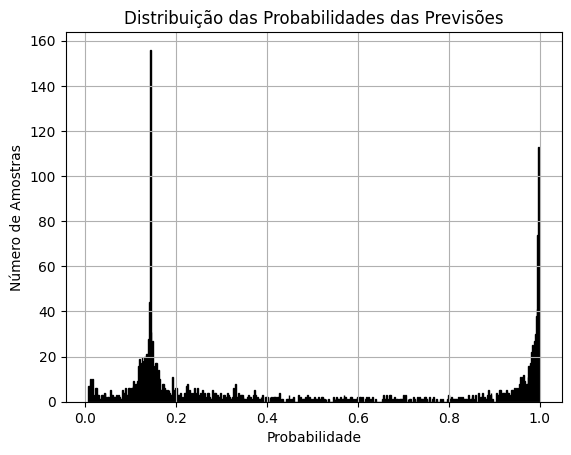

In [39]:
import matplotlib.pyplot as plt

# Criar histograma das probabilidades
plt.hist(previsoes, bins=500, color="blue", edgecolor="black")

# Configurações do gráfico
plt.xlabel("Probabilidade")
plt.ylabel("Número de Amostras")
plt.title("Distribuição das Probabilidades das Previsões")
plt.grid(True)

# Exibir o gráfico
plt.show()

Usando o valor default de 0.5 traformar o vetor de previsões probabilisticas do modelo num vetor de labels. tudo acima de 0.5 vira 1 e tudo o resto vira 0.

In [40]:
# Converter probabilidades em classes binárias (0 ou 1)
classes_preditas = (previsoes > 0.5).astype(int)

# Exibir as classes binárias
print("Classes previstas (binárias):", classes_preditas)
print()
print(classes_preditas.shape)

Classes previstas (binárias): [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]

(2051, 1)


plot do número e percentagem de previsões positivas e negativas (0 e 1).

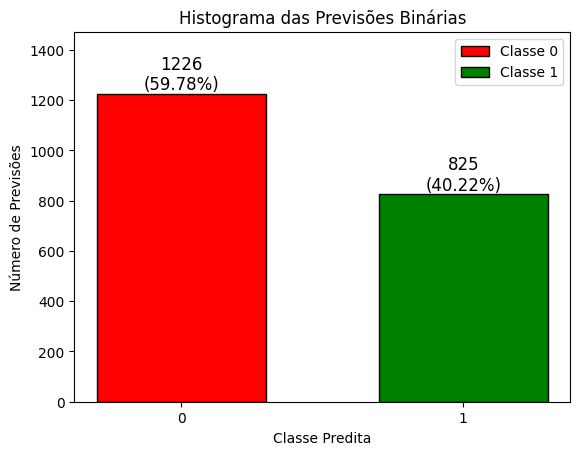

In [41]:
# Contar o número de 0s e 1s
num_zeros = np.sum(classes_preditas == 0)
num_uns = np.sum(classes_preditas == 1)

# Calcular as percentagens
percent_zero = (num_zeros / len(classes_preditas)) * 100
percent_one = (num_uns / len(classes_preditas)) * 100

# Criar histograma com cores específicas para cada classe
plt.bar([0], [num_zeros], color="red", edgecolor="black", width=0.6, label="Classe 0")
plt.bar([1], [num_uns], color="green", edgecolor="black", width=0.6, label="Classe 1")

# Adicionar contagem específica e percentagem a cada barra com uma margem acima para evitar sobreposição
plt.text(
    0,
    num_zeros + 0.1,
    f"{num_zeros}\n({percent_zero:.2f}%)",
    ha="center",
    va="bottom",
    fontsize=12,
)
plt.text(
    1,
    num_uns + 0.1,
    f"{num_uns}\n({percent_one:.2f}%)",
    ha="center",
    va="bottom",
    fontsize=12,
)

# Configurações do gráfico
plt.xticks([0, 1], ["0", "1"])
plt.xlabel("Classe Predita")
plt.ylabel("Número de Previsões")
plt.title("Histograma das Previsões Binárias")
plt.ylim(
    0, max(num_zeros, num_uns) * 1.2
)  # Ajusta o limite superior do eixo Y para dar espaço para o texto
plt.legend()

# Exibir o gráfico
plt.show()

Criar um tensor com as previões percentuais do modelo e a cada respetiva previsão o preço do atrivo em que o modelo estaria a atuar (open do espaço temporal seguinte). A ultima previsão obviamente não terá nehum preço associado pois nessa altura o trading da estrtégia já terá fechado, pois chegou ao fim dos do dataset.

In [42]:
# Inicializar uma lista para armazenar o tensor
tensor = []

# Criar o tensor para os primeiros 2051 elementos
for i in range(X_test.shape[0]):
    tensor.append([selected_subsets[i], previsoes[i, 0]])

# Adicionar o último elemento de selected_subsets com 'none' para previsoes
tensor.append([selected_subsets[X_test.shape[0]], "none"])

# Converter a lista para um array NumPy (dtype=object para lidar com tipos mistos)
tensor_np = np.array(tensor, dtype=object)

# Exibir o tensor final
print("Tensor final:")
print(tensor_np)
print(f"Shape do tensor: {tensor_np.shape}")

Tensor final:
[[168.88 0.10404381]
 [169.04 0.14351472]
 [169.015 0.13900673]
 ...
 [193.285 0.1457534]
 [192.1 0.15672211]
 [192.15 'none']]
Shape do tensor: (2052, 2)


# **Estratégias de Gestão do Portefólio de Investimentos Sem Short-Selling**

Aqui seram estudadas todas as possíveis estratégias de gestão de portefólio com o modelo sem usar short-selling. Para estudar as seguintes estratégias será criado um portefólio virtual com 100 000$ que será gerido usando o modelo para prever o mercado e a respetiva estratégia de gestão de portefólio que estará a ser estudada. Isto permite simular o mais aproximado ppossível a gestão real de um portefólio com o modelo desenvolvido no alpaca e a estratégia escolhida e desenvolvida pelo SunTzu.

É imporante destacar que a networth de um portefólio é dado pela seguinte função:

Networth(localização temporal; modelo; estratégia; ativo; valor inicial = 100 000$$) = Valor_do_ativo(localização temporal; ativo) + Valor_Liquido_Guardado(localização temporal; modelo; estratégia; valor inicial = 100 000$)

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Iniciar os arrays de resultados para guardar os resultados das estretégias estudadas.

In [ ]:
Results_Last_array = []
Results_Mean_array = []

### **Buy and Hold Classic**

Evolução natural de uma carteira sem estratégia (evolução do mercado).

Este código simula o que é que aconteceria se fosse gasto todo o dinheiro do portefólio em ações e no final do periodo temporal do dataset de teste vendidas todas as ações compradas no inicio. Estrtégia natural = holding basico.

In [ ]:
# Inicializar variáveis para a evolução natural do mercado
initial_fund_natural = 100000  # Fundo inicial de $100,000
natural_fund = initial_fund_natural

# Comprar ações no segundo índice do tensor (primeira operação de compra)
initial_price_natural = float(tensor_np[1][0])  # Preço da ação no segundo índice
num_shares_natural = (
    natural_fund / initial_price_natural
)  # Quantidade de ações compradas (fracionárias)
natural_fund -= (
    num_shares_natural * initial_price_natural
)  # Atualiza o fundo após compra

print(
    f"Comprado {num_shares_natural:.6f} ações a {initial_price_natural} cada, fundo restante: ${natural_fund:.2f}"
)

# No final do tensor, vender todas as ações restantes
final_price_natural = float(tensor_np[-1][0])  # Preço final para venda
natural_fund += (
    num_shares_natural * final_price_natural
)  # Vende todas as ações restantes

print(
    f"Vendido {num_shares_natural:.6f} ações a {final_price_natural} cada no final, fundo total: ${natural_fund:.2f}"
)

# Calcular o percentual de crescimento
initial_investment = initial_fund_natural
final_value = natural_fund
percentage_increase = ((final_value - initial_investment) / initial_investment) * 100

print(
    f"\nPercentual de crescimento do fundo com a estratégia natural: {percentage_increase:.3f}%"
)

Este código permite dar plot ao que está a acontecer no mercado, que para o caso desta estratégia é o mesmo que está a acontecer á networth do nosso portafólio durante o período temporal do dataset de teste. Usando os closes como indicadores de preço do ativo em função do tempo. Calro que com uma maior ganularidade e se também se tivesse em conta o open a resolução do gráfico seria maior, mas a resolução do gráfico de nada afeta o estudo da estratégia e a sua veracidade, portanto não foi tido em conta, pois esses dados também nesta etapa já não se encontram disponíveis pois forma tratados. Para além disso se este problema da resolução do gráfico apenas é verdade se se encarar o gráfico como uma representação do mercad, no entanto se se encarar o gráfico como a networth ao longo do tempo do portefólio sobre esta estretégia o gráfico esté perfeito e a resolução maximizada.

In [ ]:
# Criar uma lista para armazenar a evolução do valor do fundo para a evolução natural do mercado
natural_fund_values = []

# Inicializar variáveis para a evolução natural do mercado
initial_fund = 100000  # Fundo inicial de $100,000
initial_price_natural = float(
    tensor_np[1][0]
)  # Preço da ação no segundo índice do tensor
num_shares_natural = (
    initial_fund / initial_price_natural
)  # Ações fracionárias compradas
current_fund_natural = initial_fund - num_shares_natural * initial_price_natural

# A primeira posição do fundo natural é logo após a compra inicial
natural_fund_values.append(
    current_fund_natural + num_shares_natural * initial_price_natural
)

# Simular a evolução natural do mercado
for i in range(1, len(tensor_np)):
    price = float(tensor_np[i][0])

    if i < len(tensor_np) - 1:
        # Atualizar a evolução natural do mercado ao longo do tempo
        natural_fund_values.append(current_fund_natural + num_shares_natural * price)

# Registrar o valor final para a evolução natural
final_price_natural = float(tensor_np[-1][0])
natural_fund_values.append(
    current_fund_natural + num_shares_natural * final_price_natural
)

# Gerar o gráfico da evolução do fundo
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title("Evolução Natural do Mercado - Ações " + symbol)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

### **Absolute Buy and Sell**

Comprar em absoluto, ou seja, gastar todo o dinheiro da carteira ao primeiro sinal positivo "1". Buy and Hold, ou seja, manter todo o dinheiro nas ações uma vez executada a compra. Vender em absoluto, ou seja, vender todo o dinheiro das ações ao primeiro sinal negativo "0". Repetir infinitamente o processo.



**Estudo da Melhor Sensibilidade Decisiva:**

Sensibilidade Decisiva trata-se do valor decimal que estibula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva utilizada sinalarizará a melhor sensibilidade decisiva para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor sensibilidade decisiva.

In [ ]:
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
percentages_diference_array = []

for a in range(len(sensibilidade_decisiva_array)):
    # Inicializar variáveis
    initial_fund = 100000  # Fundo inicial de $100,000
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas (permitindo frações)

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual

        if prediction_str != "none":  # Ignorar a última entrada sem previsão
            prediction = float(prediction_str)

            if prediction > sensibilidade_decisiva_array[a] and fund > 0:
                # Comprar ações fracionárias
                num_shares_to_buy = (
                    fund / current_price
                )  # Quantidade de ações fracionárias que podemos comprar
                fund -= (
                    num_shares_to_buy * current_price
                )  # Atualiza o fundo após compra
                num_shares += num_shares_to_buy  # Atualiza o número de ações

            elif prediction <= sensibilidade_decisiva_array[a] and num_shares > 0:
                # Vender ações fracionárias
                fund += (
                    num_shares * current_price
                )  # Vende todas as ações fracionárias e atualiza o fundo
                num_shares = 0.0  # Zerar o número de ações

    # No final do tensor, vender qualquer ação restante
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vender todas as ações fracionárias restantes
        num_shares = 0.0  # Zerar o número de ações

    # Calcular o percentual de crescimento
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100

    # Armazenar a diferença percentual em relação à estratégia natural
    percentages_diference_array.append(
        percentage_increase_strategy - percentage_increase
    )

# Encontrar o índice do maior valor em percentages_diference_array
max_index = np.argmax(percentages_diference_array)
max_sensibilidade = sensibilidade_decisiva_array[max_index]
max_percentage_difference = percentages_diference_array[max_index]

print(
    f"Coordenadas do ponto mais elevado: Sensibilidade Decisiva = {max_sensibilidade:.2f}, Melhoria Percentual = {max_percentage_difference:.2f}%"
)
Results_Last_array.append([max_sensibilidade, max_percentage_difference])

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(sensibilidade_decisiva_array, percentages_diference_array, color="black")
plt.scatter(
    max_sensibilidade, max_percentage_difference, color="red", zorder=5
)  # Destacar o ponto mais elevado
plt.title(
    "Melhoria Percentual no Final do Dataset de Test ao se ter usado AI Vs Sensibilidade Decisiva"
)
plt.xlabel("Sensibilidade Decisiva (%)")
plt.ylabel("Melhoria Percentual ao se ter usado AI no Final do Dataset de Test (%)")
plt.grid(True)
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a sensibilidade decisiva que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor sensibilidade decisiva parqa este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

In [ ]:
# Definir o array de sensibilidade decisiva
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
media_diff_percentual_array = []  # Armazenar as médias das diferenças percentuais

for a in range(len(sensibilidade_decisiva_array)):
    # Inicializar variáveis
    initial_fund = 100000  # Fundo inicial de $100,000
    fund_strategy = initial_fund
    num_shares_strategy = 0.0  # Número de ações para a estratégia AI
    networth_strategy = []  # Para armazenar o valor líquido para a estratégia AI

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação
        prediction_str = tensor_np[i][1]  # Previsão do modelo

        if prediction_str != "none":
            prediction = float(prediction_str)

            # Estratégia AI
            if prediction > sensibilidade_decisiva_array[a] and fund_strategy > 0:
                num_shares_to_buy = fund_strategy / current_price
                fund_strategy -= num_shares_to_buy * current_price
                num_shares_strategy += num_shares_to_buy
            elif (
                prediction <= sensibilidade_decisiva_array[a]
                and num_shares_strategy > 0
            ):
                fund_strategy += num_shares_strategy * current_price
                num_shares_strategy = 0.0

        # Armazenar o valor líquido da estratégia
        networth_strategy.append(fund_strategy + num_shares_strategy * current_price)

    # Vender qualquer ação restante no final da estratégia
    if num_shares_strategy > 0:
        final_price = float(tensor_np[-1][0])
        fund_strategy += num_shares_strategy * final_price
        num_shares_strategy = 0.0

    # Armazenar o valor líquido da estratégia
    networth_strategy.append(fund_strategy + num_shares_strategy * current_price)

    # Calcular a diferença percentual entre as estratégias
    diff_percentual = (
        (np.array(networth_strategy) - np.array(natural_fund_values))
        / np.array(natural_fund_values)
    ) * 100
    media_diff_percentual = np.mean(diff_percentual)  # Média da diferença percentual

    media_diff_percentual_array.append(media_diff_percentual)

# Encontrar o índice do valor máximo
max_index = np.argmax(media_diff_percentual_array)
max_sensibilidade = sensibilidade_decisiva_array[max_index]
max_percentage_difference = media_diff_percentual_array[max_index]

# Imprimir as coordenadas do ponto máximo
print(
    f"Coordenadas do ponto mais elevado: Sensibilidade Decisiva = {max_sensibilidade:.2f}, Média Diferença Percentual = {max_percentage_difference:.2f}%"
)
Results_Mean_array.append([max_sensibilidade, max_percentage_difference])

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(sensibilidade_decisiva_array, media_diff_percentual_array, color="red")
plt.scatter(
    max_sensibilidade, max_percentage_difference, color="black", zorder=5
)  # Destacar o ponto mais elevado
plt.title("Média da Diferença Percentual vs Sensibilidade Decisiva")
plt.xlabel("Sensibilidade Decisiva (%)")
plt.ylabel("Média da Diferença Percentual (%)")
plt.grid(True)
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para um valor em especifico de sensibilidade decisiva.

Geralmente a ideia é analisar detalhadamente o que é que acontec com o valor considerado ideal encotrado anteriormente.

Escolhe-se o valor da sensibilidade decisiva que se quer estudar.

In [ ]:
sensibilidade_decisiva = max_sensibilidade
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")

Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas (agora pode ser fracionário)

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = tensor_np[i + 1][0]  # Preço da ação para compra/venda
    prediction = tensor_np[i][1]  # Previsão atual

    if prediction != "none":  # Ignorar a última entrada sem previsão
        if prediction > sensibilidade_decisiva and fund > 0:
            # Comprar ações fracionárias
            num_shares_to_buy = (
                fund / current_price
            )  # Quantidade fracionária de ações que podemos comprar
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy  # Atualiza o número de ações
            print(
                f"Comprado {num_shares_to_buy:.6f} ações a {current_price} cada, fundo restante: ${fund:.2f}"
            )

        elif prediction <= sensibilidade_decisiva and num_shares > 0:
            # Vender ações fracionárias
            fund += (
                num_shares * current_price
            )  # Vende todas as ações e atualiza o fundo
            print(
                f"Vendido {num_shares:.6f} ações a {current_price} cada, fundo total: ${fund:.2f}"
            )
            num_shares = 0.0  # Zerar o número de ações

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = tensor_np[-1][0]  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    print(
        f"Vendido {num_shares:.6f} ações a {final_price} cada no final, fundo total: ${fund:.2f}"
    )
    num_shares = 0.0  # Zerar o número de ações

# Exibir o balanço final do fundo
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")

# Calcular o percentual de crescimento
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100

print(
    f"\nPercentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%"
)

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas (permitindo frações)

# Listas para armazenar a evolução do fundo ao longo do tempo
networth_strategy = []

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        # Comprar ações fracionárias
        num_shares_to_buy = (
            fund / current_price
        )  # Quantidade fracionária de ações que podemos comprar
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        # Vender ações fracionárias
        fund += (
            num_shares * current_price
        )  # Vende todas as ações fracionárias e atualiza o fundo
        num_shares = 0.0  # Zerar o número de ações

    # Registrar o valor do fundo ao longo do tempo
    networth_strategy.append(fund + num_shares * current_price)

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações fracionárias restantes
    num_shares = 0.0  # Zerar o número de ações

# Registrar o valor final do fundo
networth_strategy.append(fund)

# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [ ]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. O valor da sensibilidade decisiva deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

In [ ]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

In [ ]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Listas para armazenar os resultados
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas (agora pode ser fracionário)

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Verificar se prediction_str pode ser convertido para float
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0  # Definir a previsão como 0 se for 'none'

        if prediction > sensibilidade_decisiva and fund > 0:
            # Comprar ações fracionárias
            num_shares_to_buy = (
                fund / current_price
            )  # Quantidade fracionária de ações que podemos comprar
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy  # Atualiza o número de ações

        elif prediction <= sensibilidade_decisiva and num_shares > 0:
            # Vender ações fracionárias
            fund += (
                num_shares * current_price
            )  # Vende todas as ações e atualiza o fundo
            num_shares = 0.0  # Zerar o número de ações

    # No final do tensor, vender qualquer ação restante
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vender todas as ações restantes

    # Calcular o percentual de crescimento
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Verificar os valores de percentual_ganhos
# print(f"Percentuais de Ganho: {percentual_ganhos}")

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    percentual_ganhos,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo

# Ajustar limites do eixo Y com base nos dados
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)

plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se tratar de um "0" ou de um "1", isto pode ser inferido através de "predictions", ou seja, através do array de previsões decimais do modelo que tem valores que variam entre 0 e 1) do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada.

Nesta estratégia então terás 2 valores para otimizar a sensibilidade decisiva e o "coeficiente", já que o "grau de certeza" é dado pelo próprio array de previsões do modelo. Isto faz com que os gráficos de otmização agora fiquem 3D.

A lógica por trás desta estratégia é que quanto maior for a certeza do modelo sobre o trade mais dinheiro se deve investir ou desinvestir, assim o dinheiro em risco deve de ser proporcional á certeza do modelo.

  if prediction > sensibilidade_decisiva and fund > 0:
      grau_certeza = abs(prediction)  # Grau de certeza do modelo
      # Comprar ações com base no percentual calculado
      amount_to_invest = coeficiente * grau_certeza * fund
      num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
      fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
      num_shares += num_shares_to_buy  # Atualiza o número de ações

  elif prediction <= sensibilidade_decisiva and num_shares > 0:
      grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
      # Vender ações com base no percentual calculado
      amount_to_sell = coeficiente * grau_certeza * num_shares  # Quantidade de ações a vender
      num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
      fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
      num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

  como se pode ver por este treixos de código as compras e as vendas de ações são sempre com base numa percentagem do montante total de dinheiro ou das ações que o portefólio tem. Assim o que algoritmo diz é quanto em percentual é que devemos investir do dinheio que está no fundo e qual a percentagem de ações que devemos vender comparativamente com as que temos.

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficiente. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficiente utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficiente.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Arrays para sensibilidade_decisiva e coeficiente
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_array = np.arange(0, 2.01, 0.01)

# Matriz para armazenar os ganhos percentuais
percentual_ganhos = np.zeros(
    (len(sensibilidade_decisiva_array), len(coeficiente_array))
)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Loop sobre todos os valores de sensibilidade_decisiva e coeficiente
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente in enumerate(coeficiente_array):
        # Variáveis de controle do fundo
        fund = initial_fund
        num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for k in range(len(tensor_np) - 1):
            current_price = float(
                tensor_np[k + 1][0]
            )  # Preço da ação para compra/venda
            prediction_str = tensor_np[k][1]  # Previsão atual (grau de certeza)

            # Verificar se prediction_str pode ser convertido para float
            if prediction_str != "none":
                prediction = float(prediction_str)
            else:
                prediction = 0  # Definir a previsão como 0 se for 'none'

            if prediction > sensibilidade_decisiva and fund > 0:
                grau_certeza = abs(prediction)  # Grau de certeza do modelo
                # Comprar ações com base no percentual calculado
                percentage_to_invest = coeficiente * grau_certeza
                if percentage_to_invest >= 1:
                    percentage_to_invest = 1
                amount_to_invest = percentage_to_invest * fund
                num_shares_to_buy = (
                    amount_to_invest / current_price
                )  # Quantidade de ações que podemos comprar (fracionária)
                fund -= (
                    num_shares_to_buy * current_price
                )  # Atualiza o fundo após compra
                num_shares += num_shares_to_buy  # Atualiza o número de ações

            elif prediction <= sensibilidade_decisiva and num_shares > 0:
                grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
                # Vender ações com base no percentual calculado
                percentage_to_sell = coeficiente * grau_certeza
                if percentage_to_sell >= 1:
                    percentage_to_sell = 1
                amount_to_sell = (
                    percentage_to_sell * num_shares
                )  # Quantidade de ações a vender
                num_shares_to_sell = (
                    amount_to_sell  # Quantidade fracionária de ações a vender
                )
                fund += (
                    num_shares_to_sell * current_price
                )  # Vende as ações e atualiza o fundo
                num_shares -= (
                    num_shares_to_sell  # Atualiza o número de ações após a venda
                )

        # No final do tensor, vender qualquer ação restante
        if num_shares > 0:
            final_price = float(tensor_np[-1][0])  # Preço final para venda
            fund += num_shares * final_price  # Vender todas as ações restantes
            num_shares = 0  # Zerar o número de ações

        # Calcular o percentual de crescimento do fundo
        percentual_ganho = ((fund - initial_fund) / initial_fund) * 100
        percentual_ganhos[i, j] = (
            percentual_ganho - percentage_increase
        )  # Armazenar o ganho percentual

# Criar o gráfico 3D
X, Y = np.meshgrid(sensibilidade_decisiva_array, coeficiente_array)
Z = percentual_ganhos.T  # Transpor para ter o formato correto

# Encontra o índice do valor máximo de z
row, col = np.unravel_index(np.argmax(Z), Z.shape)

# Obtém as coordenadas correspondentes ao valor máximo de z
x_max_z = X[row, col]
y_max_z = Y[row, col]
z_max_z = Z[row, col]

print(
    f"Coordenadas do ponto com o valor máximo de Z: Sensibilidade Decisiva={x_max_z:.2f}, Coeficiente={y_max_z:.2f}, Ganho Percentual (%)={z_max_z:.4f}"
)
Results_Last_array.append([x_max_z, y_max_z, z_max_z])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar o gráfico de superfície
img = ax.plot_surface(X, Y, Z, cmap="inferno", edgecolor="none")

# Adiciona a barra de cores (escala de cor)
cbar = fig.colorbar(img)
cbar.set_label("Ganho Percentual (%)")

# Destaca o ponto máximo
ax.scatter(x_max_z, y_max_z, z_max_z, color="red", s=10, label="Máximo Absoluto")

ax.set_title(
    "Ganho Percentual do Fundo de Investimento a Cima do Mercado em Função da Sensibilidade Decisiva e Coeficiente"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente")
ax.set_zlabel("Ganho Percentual (%)")

plt.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficiente que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficiente para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

In [ ]:
# Arrays para sensibilidade_decisiva e coeficiente
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_array = np.arange(0, 2.01, 0.01)

# Matriz para armazenar a média da diferença percentual
media_diff_percentual_array = np.zeros(
    (len(sensibilidade_decisiva_array), len(coeficiente_array))
)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Loop sobre todos os valores de sensibilidade_decisiva e coeficiente
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente in enumerate(coeficiente_array):
        # Variáveis de controle do fundo
        fund_strategy = initial_fund
        num_shares_strategy = 0.0  # Número de ações detidas na estratégia AI
        networth_strategy = []  # Para armazenar o valor líquido da estratégia AI

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for k in range(len(tensor_np) - 1):
            current_price = float(tensor_np[k + 1][0])  # Preço da ação
            prediction_str = tensor_np[k][1]  # Previsão do modelo

            if prediction_str != "none":
                prediction = float(prediction_str)

                # Estratégia AI
                if prediction > sensibilidade_decisiva and fund_strategy > 0:
                    grau_certeza = abs(prediction)
                    percentage_to_invest = coeficiente * grau_certeza
                    if percentage_to_invest >= 1:
                        percentage_to_invest = 1
                    amount_to_invest = percentage_to_invest * fund_strategy
                    num_shares_to_buy = amount_to_invest / current_price
                    fund_strategy -= num_shares_to_buy * current_price
                    num_shares_strategy += num_shares_to_buy
                elif prediction <= sensibilidade_decisiva and num_shares_strategy > 0:
                    grau_certeza = abs(1 - prediction)
                    percentage_to_sell = coeficiente * grau_certeza
                    if percentage_to_sell >= 1:
                        percentage_to_sell = 1
                    amount_to_sell = percentage_to_sell * num_shares_strategy
                    fund_strategy += amount_to_sell * current_price
                    num_shares_strategy -= amount_to_sell

            # Armazenar o valor líquido da estratégia
            networth_strategy.append(
                fund_strategy + num_shares_strategy * current_price
            )

        # Vender qualquer ação restante no final
        if num_shares_strategy > 0:
            final_price = float(tensor_np[-1][0])
            fund_strategy += num_shares_strategy * final_price
            num_shares_strategy = 0.0

        networth_strategy.append(fund_strategy + num_shares_strategy * current_price)

        # Calcular a diferença percentual entre a estratégia e o fundo natural
        diff_percentual = (
            (np.array(networth_strategy) - np.array(natural_fund_values))
            / np.array(natural_fund_values)
        ) * 100
        media_diff_percentual = np.mean(
            diff_percentual
        )  # Média da diferença percentual

        media_diff_percentual_array[i, j] = (
            media_diff_percentual  # Armazenar a média da diferença
        )

# Criar o gráfico 3D
X, Y = np.meshgrid(sensibilidade_decisiva_array, coeficiente_array)
Z = media_diff_percentual_array.T  # Transpor para o formato correto

# Encontrar o índice do valor máximo de Z
row, col = np.unravel_index(np.argmax(Z), Z.shape)

# Coordenadas do ponto máximo de Z
x_max_z = X[row, col]
y_max_z = Y[row, col]
z_max_z = Z[row, col]

print(
    f"Coordenadas do ponto com o valor máximo de Z: Sensibilidade Decisiva={x_max_z:.2f}, Coeficiente={y_max_z:.2f}, Média Diferença Percentual (%)={z_max_z:.4f}"
)
Results_Mean_array.append([x_max_z, y_max_z, z_max_z])

# Criar figura e plotar gráfico de superfície
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar o gráfico de superfície
img = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

# Adicionar a barra de cores
cbar = fig.colorbar(img)
cbar.set_label("Média Diferença Percentual (%)")

# Destacar o ponto máximo
ax.scatter(x_max_z, y_max_z, z_max_z, color="red", s=10, label="Máximo Absoluto")

# Definir título e rótulos dos eixos
ax.set_title("Média Diferença Percentual vs Sensibilidade Decisiva e Coeficiente")
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente")
ax.set_zlabel("Média Diferença Percentual (%)")

plt.legend()
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficiente.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [ ]:
sensibilidade_decisiva = x_max_z
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")
coeficiente = y_max_z
print(f"Coeficiente: {coeficiente}")

Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        grau_certeza = abs(prediction)  # Grau de certeza do modelo
        # Comprar ações com base no percentual calculado
        percentage_to_spend = coeficiente * grau_certeza
        if percentage_to_spend >= 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund  # Valor a gastar
        num_shares_to_buy = (
            amount_to_spend / current_price
        )  # Quantidade de ações que podemos comprar (fracionária)
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        print(
            f"Comprado {num_shares_to_buy:.4f} ações a {current_price:.2f} cada, fundo restante: ${fund:.2f}"
        )

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
        # Vender ações com base no percentual calculado
        percentage_to_sell = coeficiente * grau_certeza
        if percentage_to_sell >= 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares  # Quantidade de ações a vender
        fund += amount_to_sell * current_price  # Vende as ações e atualiza o fundo
        num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
        print(
            f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}"
        )

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    print(
        f"Vendido {num_shares:.4f} ações a {final_price:.2f} cada no final, fundo total: ${fund:.2f}"
    )
    num_shares = 0  # Zerar o número de ações

# Exibir o balanço final do fundo
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")

# Calcular o percentual de crescimento
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"\nPercentual de crescimento do fundo com a nova estratégia: {percentage_increase_strategy:.3f}%"
)

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficiente para este modelo.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
networth_strategy = []  # Armazenar a net worth ao longo do tempo

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        grau_certeza = abs(prediction)  # Grau de certeza do modelo
        # Comprar ações com base no percentual calculado
        percentage_to_spend = (
            coeficiente * grau_certeza
        )  # Percentual de dinheiro a gastar
        if percentage_to_spend >= 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund  # Valor a gastar
        num_shares_to_buy = (
            amount_to_spend / current_price
        )  # Quantidade de ações que podemos comprar (fracionária)
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        # print(f"Comprado {num_shares_to_buy:.4f} ações a {current_price:.2f} cada, fundo restante: ${fund:.2f}")

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
        # Vender ações com base no percentual calculado
        percentage_to_sell = coeficiente * grau_certeza  # Percentual de ações a vender
        if percentage_to_sell >= 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares  # Quantidade de ações a vender
        num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
        fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
        num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda
        # print(f"Vendido {num_shares_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}")

    # Calcular net worth após cada iteração
    networth = (
        fund + num_shares * current_price
    )  # Dinheiro no fundo + valor das ações detidas
    networth_strategy.append(networth)  # Armazenar a net worth

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    num_shares = 0  # Zerar o número de ações

# Adicionar a net worth final após vender as ações no último período
networth_strategy.append(fund)

# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-len(networth_strategy) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

In [ ]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy)) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [ ]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

In [ ]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

In [ ]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Listas para armazenar os resultados
networth_results = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
    networth_strategy = []  # Armazenar a net worth ao longo do tempo

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Verificar se prediction_str pode ser convertido para float
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0  # Definir a previsão como 0 se for 'none'

        if prediction > sensibilidade_decisiva and fund > 0:
            grau_certeza = abs(prediction)  # Grau de certeza do modelo
            # Comprar ações com base no percentual calculado
            percentage_to_spend = (
                coeficiente * grau_certeza
            )  # Percentual de dinheiro a gastar
            if percentage_to_spend >= 1:
                percentage_to_spend = 1
            amount_to_spend = percentage_to_spend * fund  # Valor a gastar
            num_shares_to_buy = (
                amount_to_spend / current_price
            )  # Quantidade de ações que podemos comprar (fracionária)
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy  # Atualiza o número de ações

        elif prediction <= sensibilidade_decisiva and num_shares > 0:
            grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
            # Vender ações com base no percentual calculado
            percentage_to_sell = (
                coeficiente * grau_certeza
            )  # Percentual de ações a vender
            if percentage_to_sell >= 1:
                percentage_to_sell = 1
            amount_to_sell = (
                percentage_to_sell * num_shares
            )  # Quantidade de ações a vender
            num_shares_to_sell = (
                amount_to_sell  # Quantidade fracionária de ações a vender
            )
            fund += (
                num_shares_to_sell * current_price
            )  # Vende as ações e atualiza o fundo
            num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

        # Calcular net worth após cada iteração
        networth = (
            fund + num_shares * current_price
        )  # Dinheiro no fundo + valor das ações detidas
        networth_strategy.append(networth)  # Armazenar a net worth

    # No final do tensor, vender qualquer ação restante
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vender todas as ações restantes
        num_shares = 0  # Zerar o número de ações

    # Adicionar a net worth final após vender as ações no último período
    networth_strategy.append(fund)

    # Calcular o percentual de crescimento
    percentage_increase_strategy = (
        (networth_strategy[-1] - initial_fund) / initial_fund
    ) * 100
    networth_results.append(percentage_increase_strategy)

# Verificar os valores de networth_results
# print(f"Percentuais de Ganho: {networth_results}")

# Encontrar o índice do valor máximo de networth_results
max_index = np.argmax(networth_results)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = networth_results[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    networth_results,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo

# Ajustar limites do eixo Y com base nos dados
plt.ylim(min(networth_results) - 10, max(networth_results) + 10)

plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Independent Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. A questão que aqui diferencia da passada estratégia é que agora vão existir 2 coeficientes em jogo um coeficente para ações de venda, coeficiente_v, outro para ações de compra, coeficiente_c.

Esta estratégia é extremamente semelhante á anterior apenas é acrecenta um novo coeficiente e para tal terá de ser distinguido o coeficiente de buy do coeficiente de sell.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
    fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

Por este código passam 3 loops diferentes todos uns dentro uns dos outros assim consigo garantir que para cada coeficiente de compra é testado para todos os valores de coeficiente de venda e para todos os valores de sensibilidade decisiva.

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficientes. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficientes utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficientes.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Arrays para sensibilidade_decisiva, coeficiente_c e coeficiente_v
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.1)
coeficiente_c_array = np.arange(0, 2.01, 0.1)
coeficiente_v_array = np.arange(0, 2.01, 0.1)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Lista para armazenar coordenadas e os respectivos ganhos
x_vals = []
y_vals = []
z_vals = []
color_vals = []

# Loop sobre todos os valores de sensibilidade_decisiva, coeficiente_c e coeficiente_v
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente_c in enumerate(coeficiente_c_array):
        for k, coeficiente_v in enumerate(coeficiente_v_array):
            # Variáveis de controle do fundo
            fund = initial_fund
            num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

            # Iterar pelo tensor (exceto o último que não tem previsão)
            for m in range(len(tensor_np) - 1):
                current_price = float(
                    tensor_np[m + 1][0]
                )  # Preço da ação para compra/venda
                prediction_str = tensor_np[m][1]  # Previsão atual (grau de certeza)

                # Verificar se prediction_str pode ser convertido para float
                if prediction_str != "none":
                    prediction = float(prediction_str)
                else:
                    prediction = 0  # Definir a previsão como 0 se for 'none'

                if prediction > sensibilidade_decisiva and fund > 0:
                    grau_certeza = abs(prediction)  # Grau de certeza do modelo
                    # Comprar ações com base no percentual calculado
                    percentage_to_spend = (
                        coeficiente_c * grau_certeza
                    )  # Percentual de dinheiro a gastar
                    if percentage_to_spend >= 1:
                        percentage_to_spend = 1
                    amount_to_invest = percentage_to_spend * fund
                    num_shares_to_buy = (
                        amount_to_invest / current_price
                    )  # Quantidade de ações que podemos comprar (fracionária)
                    fund -= (
                        num_shares_to_buy * current_price
                    )  # Atualiza o fundo após compra
                    num_shares += num_shares_to_buy  # Atualiza o número de ações

                elif prediction <= sensibilidade_decisiva and num_shares > 0:
                    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
                    # Vender ações com base no percentual calculado
                    percentage_to_sell = (
                        coeficiente_v * grau_certeza
                    )  # Percentual de ações a vender
                    if percentage_to_sell >= 1:
                        percentage_to_sell = 1
                    amount_to_sell = (
                        percentage_to_sell * num_shares
                    )  # Quantidade de ações a vender
                    num_shares_to_sell = (
                        amount_to_sell  # Quantidade fracionária de ações a vender
                    )
                    fund += (
                        num_shares_to_sell * current_price
                    )  # Vende as ações e atualiza o fundo
                    num_shares -= (
                        num_shares_to_sell  # Atualiza o número de ações após a venda
                    )

            # No final do tensor, vender qualquer ação restante
            if num_shares > 0:
                final_price = float(tensor_np[-1][0])  # Preço final para venda
                fund += num_shares * final_price  # Vender todas as ações restantes
                num_shares = 0  # Zerar o número de ações

            # Calcular o percentual de crescimento do fundo
            percentual_ganho = ((fund - initial_fund) / initial_fund) * 100

            # Armazenar as coordenadas e o ganho percentual
            x_vals.append(sensibilidade_decisiva)
            y_vals.append(coeficiente_c)
            z_vals.append(coeficiente_v)
            color_vals.append(percentual_ganho - percentage_increase)

# Convertendo para numpy arrays
x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
z_vals = np.array(z_vals)
color_vals = np.array(color_vals)

# Criar o gráfico 3D com a cor representando o percentual de ganhos
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot 3D com a cor representando o percentual de ganhos
img = ax.scatter(x_vals, y_vals, z_vals, c=color_vals, cmap="hot", s=25)

# Adicionar barra de cor
cbar = fig.colorbar(img)
cbar.set_label("Ganho Percentual (%)")

ax.set_title(
    "Ganho Percentual a Cima Do Mercado em Função de Sensibilidade Decisiva, Coeficiente C e Coeficiente V"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente C (Compra)")
ax.set_zlabel("Coeficiente V (Venda)")

# Localizar o índice do valor máximo em color_vals (ganhos percentuais)
max_index = np.argmax(color_vals)

# Obter as coordenadas correspondentes ao valor máximo
x_max = x_vals[max_index]  # Sensibilidade decisiva
y_max = y_vals[max_index]  # Coeficiente C (compra)
z_max = z_vals[max_index]  # Coeficiente V (venda)
max_gain = color_vals[max_index]  # Ganho percentual máximo

# Exibir as coordenadas do ponto com o valor máximo
print(f"Coordenadas do ponto com o valor máximo de ganho percentual:")
print(
    f"Sensibilidade Decisiva={x_max:.2f}, Coeficiente C={y_max:.2f}, Coeficiente V={z_max:.2f}, Ganho Percentual (%)={max_gain:.4f}"
)
Results_Last_array.append([x_max, y_max, z_max, max_gain])

plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficientes que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficientes para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

In [ ]:
# Arrays para sensibilidade_decisiva, coeficiente_c e coeficiente_v
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.1)
coeficiente_c_array = np.arange(0, 2.01, 0.1)
coeficiente_v_array = np.arange(0, 2.01, 0.1)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Lista para armazenar coordenadas e as médias de diferença percentual
x_vals = []
y_vals = []
z_vals = []
color_vals = []  # Armazenar as médias das diferenças percentuais

# Loop sobre todos os valores de sensibilidade_decisiva, coeficiente_c e coeficiente_v
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente_c in enumerate(coeficiente_c_array):
        for k, coeficiente_v in enumerate(coeficiente_v_array):
            # Variáveis de controle do fundo
            fund_strategy = initial_fund
            num_shares_strategy = 0.0  # Número de ações detidas na estratégia
            networth_strategy = []  # Para armazenar o valor líquido da estratégia

            # Iterar pelo tensor (exceto o último que não tem previsão)
            for m in range(len(tensor_np) - 1):
                current_price = float(tensor_np[m + 1][0])  # Preço da ação
                prediction_str = tensor_np[m][1]  # Previsão do modelo

                if prediction_str != "none":
                    prediction = float(prediction_str)
                else:
                    prediction = 0  # Definir a previsão como 0 se for 'none'

                if prediction > sensibilidade_decisiva and fund_strategy > 0:
                    grau_certeza = abs(prediction)  # Grau de certeza do modelo
                    # Comprar ações com base no percentual calculado
                    percentage_to_invest = coeficiente_c * grau_certeza
                    if percentage_to_invest >= 1:
                        percentage_to_invest = 1
                    amount_to_invest = percentage_to_invest * fund_strategy
                    num_shares_to_buy = amount_to_invest / current_price
                    fund_strategy -= num_shares_to_buy * current_price
                    num_shares_strategy += num_shares_to_buy

                elif prediction <= sensibilidade_decisiva and num_shares_strategy > 0:
                    grau_certeza = abs(1 - prediction)  # Grau de certeza
                    # Vender ações com base no percentual calculado
                    percentage_to_sell = coeficiente_v * grau_certeza
                    if percentage_to_sell >= 1:
                        percentage_to_sell = 1
                    amount_to_sell = percentage_to_sell * num_shares_strategy
                    fund_strategy += amount_to_sell * current_price
                    num_shares_strategy -= amount_to_sell

                # Armazenar o valor líquido da estratégia
                networth_strategy.append(
                    fund_strategy + num_shares_strategy * current_price
                )

            # No final do tensor, vender qualquer ação restante
            if num_shares_strategy > 0:
                final_price = float(tensor_np[-1][0])
                fund_strategy += num_shares_strategy * final_price
                num_shares_strategy = 0

            networth_strategy.append(
                fund_strategy + num_shares_strategy * current_price
            )

            # Calcular a diferença percentual entre a estratégia e o fundo natural
            diff_percentual = (
                (np.array(networth_strategy) - np.array(natural_fund_values))
                / np.array(natural_fund_values)
            ) * 100
            media_diff_percentual = np.mean(
                diff_percentual
            )  # Média da diferença percentual

            # Armazenar as coordenadas e a média da diferença percentual
            x_vals.append(sensibilidade_decisiva)
            y_vals.append(coeficiente_c)
            z_vals.append(coeficiente_v)
            color_vals.append(
                media_diff_percentual
            )  # Armazenar a média da diferença percentual

# Convertendo para numpy arrays
x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
z_vals = np.array(z_vals)
color_vals = np.array(color_vals)

# Criar o gráfico 3D com a cor representando a média da diferença percentual
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot 3D com a cor representando a média da diferença percentual
img = ax.scatter(x_vals, y_vals, z_vals, c=color_vals, cmap="viridis", s=25)

# Adicionar barra de cor
cbar = fig.colorbar(img)
cbar.set_label("Média Diferença Percentual (%)")

ax.set_title(
    "Média Diferença Percentual vs Sensibilidade Decisiva, Coeficiente C e Coeficiente V"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente C (Compra)")
ax.set_zlabel("Coeficiente V (Venda)")

# Localizar o índice do valor máximo em color_vals (média da diferença percentual)
max_index = np.argmax(color_vals)

# Obter as coordenadas correspondentes ao valor máximo
x_max = x_vals[max_index]  # Sensibilidade decisiva
y_max = y_vals[max_index]  # Coeficiente C (compra)
z_max = z_vals[max_index]  # Coeficiente V (venda)
max_diff_percentual = color_vals[max_index]  # Média da diferença percentual máxima

# Exibir as coordenadas do ponto com a maior média da diferença percentual
print(f"Coordenadas do ponto com o valor máximo de média diferença percentual:")
print(
    f"Sensibilidade Decisiva={x_max:.2f}, Coeficiente C={y_max:.2f}, Coeficiente V={z_max:.2f}, Média Diferença Percentual (%)={max_diff_percentual:.4f}"
)
Results_Mean_array.append([x_max, y_max, z_max, max_diff_percentual])

plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficientes.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [ ]:
sensibilidade_decisiva = x_max
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")
coeficiente_v = z_max
print(f"Coeficiente V: {coeficiente_v}")
coeficiente_c = y_max
print(f"Coeficiente C: {coeficiente_c}")

Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        grau_certeza = abs(prediction)  # Grau de certeza do modelo
        # Comprar ações com base no percentual calculado
        percentage_to_spend = (
            coeficiente_c * grau_certeza
        )  # Percentual de dinheiro a gastar
        if percentage_to_spend >= 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund  # Valor a gastar
        num_shares_to_buy = (
            amount_to_spend / current_price
        )  # Quantidade de ações que podemos comprar (fracionária)
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        print(
            f"Comprado {num_shares_to_buy:.4f} ações a {current_price:.2f} cada, fundo restante: ${fund:.2f}"
        )

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
        # Vender ações com base no percentual calculado~
        percentage_to_sell = (
            coeficiente_v * grau_certeza
        )  # Percentual de ações a vender
        if percentage_to_sell >= 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares  # Quantidade de ações a vender
        fund += amount_to_sell * current_price  # Vende as ações e atualiza o fundo
        num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
        print(
            f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}"
        )

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    print(
        f"Vendido {num_shares:.4f} ações a {final_price:.2f} cada no final, fundo total: ${fund:.2f}"
    )
    num_shares = 0  # Zerar o número de ações

# Exibir o balanço final do fundo
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")

# Calcular o percentual de crescimento
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"\nPercentual de crescimento do fundo com a nova estratégia: {percentage_increase_strategy:.3f}%"
)

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficientes para este modelo.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
networth_strategy = []  # Armazenar a net worth ao longo do tempo

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        grau_certeza = abs(prediction)  # Grau de certeza do modelo
        # Comprar ações com base no percentual calculado
        percentage_to_spend = (
            coeficiente_c * grau_certeza
        )  # Percentual de dinheiro a gastar
        if percentage_to_spend >= 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund  # Valor a gastar
        num_shares_to_buy = (
            amount_to_spend / current_price
        )  # Quantidade de ações que podemos comprar (fracionária)
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        # print(f"Comprado {num_shares_to_buy:.4f} ações a {current_price:.2f} cada, fundo restante: ${fund:.2f}")

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
        # Vender ações com base no percentual calculado
        percentage_to_sell = (
            coeficiente_v * grau_certeza
        )  # Percentual de ações a vender
        if percentage_to_sell >= 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares  # Quantidade de ações a vender
        num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
        fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
        num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda
        # print(f"Vendido {num_shares_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}")

    # Calcular net worth após cada iteração
    networth = (
        fund + num_shares * current_price
    )  # Dinheiro no fundo + valor das ações detidas
    networth_strategy.append(networth)  # Armazenar a net worth

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    num_shares = 0  # Zerar o número de ações

# Adicionar a net worth final após vender as ações no último período
networth_strategy.append(fund)

# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-len(networth_strategy) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

In [ ]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy)) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [ ]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

In [ ]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

In [ ]:
import matplotlib.pyplot as plt

# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Listas para armazenar os resultados
networth_results = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
    networth_strategy = []  # Armazenar a net worth ao longo do tempo

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Verificar se prediction_str pode ser convertido para float
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0  # Definir a previsão como 0 se for 'none'

        if prediction > sensibilidade_decisiva and fund > 0:
            grau_certeza = abs(prediction)  # Grau de certeza do modelo
            # Comprar ações com base no percentual calculado
            percentage_to_spend = coeficiente_c * grau_certeza
            if percentage_to_spend >= 1:
                percentage_to_spend = 1
            amount_to_spend = percentage_to_spend * fund  # Valor a gastar
            num_shares_to_buy = (
                amount_to_spend / current_price
            )  # Quantidade de ações que podemos comprar (fracionária)
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy  # Atualiza o número de ações

        elif prediction <= sensibilidade_decisiva and num_shares > 0:
            grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
            # Vender ações com base no percentual calculado
            percentage_to_sell = coeficiente_v * grau_certeza
            if percentage_to_sell >= 1:
                percentage_to_sell = 1
            amount_to_sell = (
                percentage_to_sell * num_shares
            )  # Quantidade de ações a vender
            num_shares_to_sell = (
                amount_to_sell  # Quantidade fracionária de ações a vender
            )
            fund += (
                num_shares_to_sell * current_price
            )  # Vende as ações e atualiza o fundo
            num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

        # Calcular net worth após cada iteração
        networth = (
            fund + num_shares * current_price
        )  # Dinheiro no fundo + valor das ações detidas
        networth_strategy.append(networth)  # Armazenar a net worth

    # No final do tensor, vender qualquer ação restante
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vender todas as ações restantes
        num_shares = 0  # Zerar o número de ações

    # Adicionar a net worth final após vender as ações no último período
    networth_strategy.append(fund)

    # Calcular o percentual de crescimento
    percentage_increase_strategy = (
        (networth_strategy[-1] - initial_fund) / initial_fund
    ) * 100
    networth_results.append(percentage_increase_strategy)

# Verificar os valores de networth_results
# print(f"Percentuais de Ganho: {networth_results}")

# Encontrar o índice do valor máximo de networth_results
max_index = np.argmax(networth_results)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = networth_results[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    networth_results,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo

# Ajustar limites do eixo Y com base nos dados
plt.ylim(min(networth_results) - 10, max(networth_results) + 10)

plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Parcial Buy in Function of Predictions Probabilaty and Absolute Sell**

Agora eu quero testar uma nova estratégia. As compras vão ser de forma percentual e as vendas absolutas. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas todas as ações do fundo, se existirem alguma.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    # Vender ações fracionárias
    fund += num_shares * current_price  # Vende todas as ações e atualiza o fundo
    #print(f"Vendido {num_shares:.6f} ações a {current_price} cada, fundo total: ${fund:.2f}")
    num_shares = 0.0  # Zerar o número de ações

**Estudo do Melhor Coeficiente e Melhor Sensibilidade DEcisiva para Formatar o Percentual Investido:**

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficiente. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficiente utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficiente.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Arrays para sensibilidade_decisiva e coeficiente
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_c_array = np.arange(0, 2.01, 0.01)

# Matriz para armazenar os ganhos percentuais
percentual_ganhos = np.zeros(
    (len(sensibilidade_decisiva_array), len(coeficiente_array))
)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Loop sobre todos os valores de sensibilidade_decisiva e coeficiente
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente_c in enumerate(coeficiente_c_array):
        # Variáveis de controle do fundo
        fund = initial_fund
        num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for k in range(len(tensor_np) - 1):
            current_price = float(
                tensor_np[k + 1][0]
            )  # Preço da ação para compra/venda
            prediction_str = tensor_np[k][1]  # Previsão atual (grau de certeza)

            # Verificar se prediction_str pode ser convertido para float
            if prediction_str != "none":
                prediction = float(prediction_str)
            else:
                prediction = 0  # Definir a previsão como 0 se for 'none'

            if prediction > sensibilidade_decisiva and fund > 0:
                grau_certeza = abs(prediction)  # Grau de certeza do modelo
                # Comprar ações com base no percentual calculado
                percentage_to_spend = (
                    coeficiente_c * grau_certeza
                )  # Percentual de dinheiro a gastar
                if percentage_to_spend >= 1:
                    percentage_to_spend = 1
                amount_to_invest = percentage_to_spend * fund
                num_shares_to_buy = (
                    amount_to_invest / current_price
                )  # Quantidade de ações que podemos comprar (fracionária)
                fund -= (
                    num_shares_to_buy * current_price
                )  # Atualiza o fundo após compra
                num_shares += num_shares_to_buy  # Atualiza o número de ações

            elif prediction <= sensibilidade_decisiva and num_shares > 0:
                # Vender ações fracionárias
                fund += (
                    num_shares * current_price
                )  # Vende todas as ações e atualiza o fundo
                # print(f"Vendido {num_shares:.6f} ações a {current_price} cada, fundo total: ${fund:.2f}")
                num_shares = 0.0  # Zerar o número de ações

        # No final do tensor, vender qualquer ação restante
        if num_shares > 0:
            final_price = float(tensor_np[-1][0])  # Preço final para venda
            fund += num_shares * final_price  # Vender todas as ações restantes
            num_shares = 0  # Zerar o número de ações

        # Calcular o percentual de crescimento do fundo
        percentual_ganho = ((fund - initial_fund) / initial_fund) * 100
        percentual_ganhos[i, j] = (
            percentual_ganho - percentage_increase
        )  # Armazenar o ganho percentual

# Criar o gráfico 3D
X, Y = np.meshgrid(sensibilidade_decisiva_array, coeficiente_c_array)
Z = percentual_ganhos.T  # Transpor para ter o formato correto

# Encontra o índice do valor máximo de z
row, col = np.unravel_index(np.argmax(Z), Z.shape)

# Obtém as coordenadas correspondentes ao valor máximo de z
x_max_z = X[row, col]
y_max_z = Y[row, col]
z_max_z = Z[row, col]

print(
    f"Coordenadas do ponto com o valor máximo de Z: Sensibilidade Decisiva={x_max_z:.2f}, Coeficiente C={y_max_z:.2f}, Ganho Percentual (%)={z_max_z:.4f}"
)
Results_Last_array.append([x_max_z, y_max_z, z_max_z])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar o gráfico de superfície
img = ax.plot_surface(X, Y, Z, cmap="inferno", edgecolor="none")

# Adiciona a barra de cores (escala de cor)
cbar = fig.colorbar(img)
cbar.set_label("Ganho Percentual (%)")

# Destaca o ponto máximo
ax.scatter(x_max_z, y_max_z, z_max_z, color="red", s=10, label="Máximo Absoluto")

ax.set_title(
    "Ganho Percentual do Fundo de Investimento a Cima do Mercado em Função de Sensibilidade Decisiva e Coeficiente"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente C")
ax.set_zlabel("Ganho Percentual (%)")

plt.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficiente que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficiente para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

In [ ]:
# Arrays para sensibilidade_decisiva e coeficiente
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_c_array = np.arange(0, 2.01, 0.01)

# Matriz para armazenar a média da diferença percentual
media_diff_percentual_matrix = np.zeros(
    (len(sensibilidade_decisiva_array), len(coeficiente_c_array))
)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Loop sobre todos os valores de sensibilidade_decisiva e coeficiente_c
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente_c in enumerate(coeficiente_c_array):
        # Variáveis de controle do fundo
        fund_strategy = initial_fund
        num_shares_strategy = 0.0  # Número de ações atualmente detidas
        networth_strategy = []  # Valor líquido do fundo pela estratégia

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for k in range(len(tensor_np) - 1):
            current_price = float(
                tensor_np[k + 1][0]
            )  # Preço da ação para compra/venda
            prediction_str = tensor_np[k][1]  # Previsão atual (grau de certeza)

            # Verificar se prediction_str pode ser convertido para float
            if prediction_str != "none":
                prediction = float(prediction_str)
            else:
                prediction = 0  # Definir a previsão como 0 se for 'none'

            # Comprar ações com base no coeficiente_c e sensibilidade_decisiva
            if prediction > sensibilidade_decisiva and fund_strategy > 0:
                grau_certeza = abs(prediction)
                percentage_to_invest = coeficiente_c * grau_certeza
                if percentage_to_invest >= 1:
                    percentage_to_invest = 1
                amount_to_invest = percentage_to_invest * fund_strategy
                num_shares_to_buy = amount_to_invest / current_price
                fund_strategy -= num_shares_to_buy * current_price
                num_shares_strategy += num_shares_to_buy

            # Vender ações fracionárias
            elif prediction <= sensibilidade_decisiva and num_shares_strategy > 0:
                fund_strategy += num_shares_strategy * current_price
                num_shares_strategy = 0.0

            # Armazenar o valor líquido da estratégia
            networth_strategy.append(
                fund_strategy + num_shares_strategy * current_price
            )

        # Vender ações restantes no final
        if num_shares_strategy > 0:
            final_price = float(tensor_np[-1][0])
            fund_strategy += num_shares_strategy * final_price
            num_shares_strategy = 0.0

        networth_strategy.append(fund_strategy)

        # Calcular a diferença percentual entre a estratégia e o fundo natural
        diff_percentual = (
            (np.array(networth_strategy) - np.array(natural_fund_values))
            / np.array(natural_fund_values)
        ) * 100
        media_diff_percentual = np.mean(
            diff_percentual
        )  # Média da diferença percentual

        # Armazenar a média da diferença percentual
        media_diff_percentual_matrix[i, j] = media_diff_percentual

# Criar o gráfico 3D
X, Y = np.meshgrid(sensibilidade_decisiva_array, coeficiente_c_array)
Z = media_diff_percentual_matrix.T  # Transpor para o formato correto

# Encontra o índice do valor máximo de Z
row, col = np.unravel_index(np.argmax(Z), Z.shape)

# Obtém as coordenadas correspondentes ao valor máximo de Z
x_max_z = X[row, col]
y_max_z = Y[row, col]
z_max_z = Z[row, col]

print(
    f"Coordenadas do ponto com o valor máximo de Z: Sensibilidade Decisiva={x_max_z:.2f}, Coeficiente C={y_max_z:.2f}, Média Diferença Percentual (%)={z_max_z:.4f}"
)
Results_Mean_array.append([x_max_z, y_max_z, z_max_z])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar o gráfico de superfície
img = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

# Adiciona a barra de cores (escala de cor)
cbar = fig.colorbar(img)
cbar.set_label("Média Diferença Percentual (%)")

# Destaca o ponto máximo
ax.scatter(x_max_z, y_max_z, z_max_z, color="red", s=10, label="Máximo Absoluto")

ax.set_title("Média Diferença Percentual vs Sensibilidade Decisiva e Coeficiente C")
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente C")
ax.set_zlabel("Média Diferença Percentual (%)")

plt.legend()
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficiente.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [ ]:
sensibilidade_decisiva = x_max_z
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")
coeficiente_c = y_max_z
print(f"Coeficiente C: {coeficiente_c}")

Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        grau_certeza = abs(prediction)  # Grau de certeza do modelo
        # Comprar ações com base no percentual calculado
        percentage_to_spend = coeficiente_c * grau_certeza
        if percentage_to_spend >= 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund  # Valor a gastar
        num_shares_to_buy = (
            amount_to_spend / current_price
        )  # Quantidade de ações que podemos comprar (fracionária)
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        print(
            f"Comprado {num_shares_to_buy:.4f} ações a {current_price:.2f} cada, fundo restante: ${fund:.2f}"
        )

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        # Vender ações fracionárias
        fund += num_shares * current_price  # Vende todas as ações e atualiza o fundo
        print(
            f"Vendido {num_shares:.6f} ações a {current_price} cada, fundo total: ${fund:.2f}"
        )
        num_shares = 0.0  # Zerar o número de ações

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    print(
        f"Vendido {num_shares:.4f} ações a {final_price:.2f} cada no final, fundo total: ${fund:.2f}"
    )
    num_shares = 0  # Zerar o número de ações

# Exibir o balanço final do fundo
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")

# Calcular o percentual de crescimento
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"\nPercentual de crescimento do fundo com a nova estratégia: {percentage_increase_strategy:.3f}%"
)

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficiente para este modelo.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
networth_strategy = []  # Armazenar a net worth ao longo do tempo

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        grau_certeza = abs(prediction)  # Grau de certeza do modelo
        # Comprar ações com base no percentual calculado
        percentage_to_spend = (
            coeficiente_c * grau_certeza
        )  # Percentual de dinheiro a gastar
        if percentage_to_spend >= 1:
            percentage_to_spend = 1
        amount_to_spend = percentage_to_spend * fund  # Valor a gastar
        num_shares_to_buy = (
            amount_to_spend / current_price
        )  # Quantidade de ações que podemos comprar (fracionária)
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        # print(f"Comprado {num_shares_to_buy:.4f} ações a {current_price:.2f} cada, fundo restante: ${fund:.2f}")

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        # Vender ações fracionárias
        fund += num_shares * current_price  # Vende todas as ações e atualiza o fundo
        # print(f"Vendido {num_shares:.6f} ações a {current_price} cada, fundo total: ${fund:.2f}")
        num_shares = 0.0  # Zerar o número de ações

    # Calcular net worth após cada iteração
    networth = (
        fund + num_shares * current_price
    )  # Dinheiro no fundo + valor das ações detidas
    networth_strategy.append(networth)  # Armazenar a net worth

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    num_shares = 0  # Zerar o número de ações

# Adicionar a net worth final após vender as ações no último período
networth_strategy.append(fund)

# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-len(networth_strategy) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

In [ ]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy)) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [ ]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

In [ ]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

In [ ]:
import matplotlib.pyplot as plt

# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Listas para armazenar os resultados
networth_results = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
    networth_strategy = []  # Armazenar a net worth ao longo do tempo

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Verificar se prediction_str pode ser convertido para float
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0  # Definir a previsão como 0 se for 'none'

        if prediction > sensibilidade_decisiva and fund > 0:
            grau_certeza = abs(prediction)  # Grau de certeza do modelo
            # Comprar ações com base no percentual calculado
            percentage_to_spend = (
                coeficiente_c * grau_certeza
            )  # Percentual de dinheiro a gastar
            if percentage_to_spend >= 1:
                percentage_to_spend = 1
            amount_to_spend = percentage_to_spend * fund  # Valor a gastar
            num_shares_to_buy = (
                amount_to_spend / current_price
            )  # Quantidade de ações que podemos comprar (fracionária)
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy  # Atualiza o número de ações

        elif prediction <= sensibilidade_decisiva and num_shares > 0:
            # Vender ações fracionárias
            fund += (
                num_shares * current_price
            )  # Vende todas as ações e atualiza o fundo
            # print(f"Vendido {num_shares:.6f} ações a {current_price} cada, fundo total: ${fund:.2f}")
            num_shares = 0.0  # Zerar o número de ações

        # Calcular net worth após cada iteração
        networth = (
            fund + num_shares * current_price
        )  # Dinheiro no fundo + valor das ações detidas
        networth_strategy.append(networth)  # Armazenar a net worth

    # No final do tensor, vender qualquer ação restante
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vender todas as ações restantes
        num_shares = 0  # Zerar o número de ações

    # Adicionar a net worth final após vender as ações no último período
    networth_strategy.append(fund)

    # Calcular o percentual de crescimento
    percentage_increase_strategy = (
        (networth_strategy[-1] - initial_fund) / initial_fund
    ) * 100
    networth_results.append(percentage_increase_strategy)

# Verificar os valores de networth_results
# print(f"Percentuais de Ganho: {networth_results}")

# Encontrar o índice do valor máximo de networth_results
max_index = np.argmax(networth_results)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = networth_results[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    networth_results,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo

# Ajustar limites do eixo Y com base nos dados
plt.ylim(min(networth_results) - 10, max(networth_results) + 10)

plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Absolute Buy and Parcial Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras são absolutas e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto todo o dinheiro do portefólio, se existir algum. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. Escreve o código para esta nova estratégia.

if prediction > sensibilidade_decisiva and fund > 0:
    # Comprar ações fracionárias
    num_shares_to_buy = fund / current_price  # Quantidade fracionária de ações que podemos comprar
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações
    #print(f"Comprado {num_shares_to_buy:.6f} ações a {current_price} cada, fundo restante: ${fund:.2f}")

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    fund += amount_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
    #print(f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}")

**Estudo do Melhor Coeficiente e Melhor Sensibilidade DEcisiva para Formatar o Percentual Investido:**

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficiente. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficiente utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficiente.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Arrays para sensibilidade_decisiva e coeficiente
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_v_array = np.arange(0, 2.01, 0.01)

# Matriz para armazenar os ganhos percentuais
percentual_ganhos = np.zeros(
    (len(sensibilidade_decisiva_array), len(coeficiente_array))
)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Loop sobre todos os valores de sensibilidade_decisiva e coeficiente
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente_v in enumerate(coeficiente_v_array):
        # Variáveis de controle do fundo
        fund = initial_fund
        num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for k in range(len(tensor_np) - 1):
            current_price = float(
                tensor_np[k + 1][0]
            )  # Preço da ação para compra/venda
            prediction_str = tensor_np[k][1]  # Previsão atual (grau de certeza)

            # Verificar se prediction_str pode ser convertido para float
            if prediction_str != "none":
                prediction = float(prediction_str)
            else:
                prediction = 0  # Definir a previsão como 0 se for 'none'

            if prediction > sensibilidade_decisiva and fund > 0:
                # Comprar ações fracionárias
                num_shares_to_buy = (
                    fund / current_price
                )  # Quantidade fracionária de ações que podemos comprar
                fund -= (
                    num_shares_to_buy * current_price
                )  # Atualiza o fundo após compra
                num_shares += num_shares_to_buy  # Atualiza o número de ações
                # print(f"Comprado {num_shares_to_buy:.6f} ações a {current_price} cada, fundo restante: ${fund:.2f}")

            elif prediction <= sensibilidade_decisiva and num_shares > 0:
                grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
                # Vender ações com base no percentual calculado
                percentage_to_sell = (
                    coeficiente_v * grau_certeza
                )  # Percentual de dinheiro a vender
                if percentage_to_sell >= 1:
                    percentage_to_sell = 1
                amount_to_sell = (
                    percentage_to_sell * num_shares
                )  # Quantidade de ações a vender
                fund += (
                    amount_to_sell * current_price
                )  # Vende as ações e atualiza o fundo
                num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
                # print(f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}")

        # No final do tensor, vender qualquer ação restante
        if num_shares > 0:
            final_price = float(tensor_np[-1][0])  # Preço final para venda
            fund += num_shares * final_price  # Vender todas as ações restantes
            num_shares = 0  # Zerar o número de ações

        # Calcular o percentual de crescimento do fundo
        percentual_ganho = ((fund - initial_fund) / initial_fund) * 100
        percentual_ganhos[i, j] = (
            percentual_ganho - percentage_increase
        )  # Armazenar o ganho percentual

# Criar o gráfico 3D
X, Y = np.meshgrid(sensibilidade_decisiva_array, coeficiente_v_array)
Z = percentual_ganhos.T  # Transpor para ter o formato correto

# Encontra o índice do valor máximo de z
row, col = np.unravel_index(np.argmax(Z), Z.shape)

# Obtém as coordenadas correspondentes ao valor máximo de z
x_max_z = X[row, col]
y_max_z = Y[row, col]
z_max_z = Z[row, col]

print(
    f"Coordenadas do ponto com o valor máximo de Z: Sensibilidade Decisiva={x_max_z:.2f}, Coeficiente V={y_max_z:.2f}, Ganho Percentual (%)={z_max_z:.4f}"
)
Results_Last_array.append([x_max_z, y_max_z, z_max_z])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar o gráfico de superfície
img = ax.plot_surface(X, Y, Z, cmap="inferno", edgecolor="none")

# Adiciona a barra de cores (escala de cor)
cbar = fig.colorbar(img)
cbar.set_label("Ganho Percentual (%)")

# Destaca o ponto máximo
ax.scatter(x_max_z, y_max_z, z_max_z, color="red", s=10, label="Máximo Absoluto")

ax.set_title(
    "Ganho Percentual do Fundo de Investimento a Cima do Mercado em Função de Sensibilidade Decisiva e Coeficiente"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente V")
ax.set_zlabel("Ganho Percentual (%)")

plt.legend()
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficiente que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficiente para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

In [ ]:
# Arrays para sensibilidade_decisiva e coeficiente
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_v_array = np.arange(0, 2.01, 0.01)

# Matriz para armazenar a média da diferença percentual
media_diff_percentual_matrix = np.zeros(
    (len(sensibilidade_decisiva_array), len(coeficiente_v_array))
)

# Inicializar variáveis para a estratégia
initial_fund = 100000  # Fundo inicial de $100,000

# Loop sobre todos os valores de sensibilidade_decisiva e coeficiente_v
for i, sensibilidade_decisiva in enumerate(sensibilidade_decisiva_array):
    for j, coeficiente_v in enumerate(coeficiente_v_array):
        # Variáveis de controle do fundo
        fund_strategy = initial_fund
        num_shares_strategy = 0.0  # Número de ações atualmente detidas
        networth_strategy = []  # Valor líquido da estratégia

        # Iterar pelo tensor (exceto o último que não tem previsão)
        for k in range(len(tensor_np) - 1):
            current_price = float(
                tensor_np[k + 1][0]
            )  # Preço da ação para compra/venda
            prediction_str = tensor_np[k][1]  # Previsão atual (grau de certeza)

            # Verificar se prediction_str pode ser convertido para float
            if prediction_str != "none":
                prediction = float(prediction_str)
            else:
                prediction = 0  # Definir a previsão como 0 se for 'none'

            # Comprar ações
            if prediction > sensibilidade_decisiva and fund_strategy > 0:
                num_shares_to_buy = fund_strategy / current_price
                fund_strategy -= num_shares_to_buy * current_price
                num_shares_strategy += num_shares_to_buy

            # Vender ações com base no coeficiente_v
            elif prediction <= sensibilidade_decisiva and num_shares_strategy > 0:
                grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
                percentage_to_sell = coeficiente_v * grau_certeza
                if percentage_to_sell >= 1:
                    percentage_to_sell = 1
                amount_to_sell = percentage_to_sell * num_shares_strategy
                fund_strategy += amount_to_sell * current_price
                num_shares_strategy -= amount_to_sell

            # Armazenar o valor líquido da estratégia
            networth_strategy.append(
                fund_strategy + num_shares_strategy * current_price
            )

        # No final, vender ações restantes
        if num_shares_strategy > 0:
            final_price = float(tensor_np[-1][0])
            fund_strategy += num_shares_strategy * final_price
            num_shares_strategy = 0.0

        networth_strategy.append(fund_strategy)

        # Calcular a diferença percentual entre a estratégia e o fundo natural
        diff_percentual = (
            (np.array(networth_strategy) - np.array(natural_fund_values))
            / np.array(natural_fund_values)
        ) * 100
        media_diff_percentual = np.mean(
            diff_percentual
        )  # Média da diferença percentual

        # Armazenar a média da diferença percentual
        media_diff_percentual_matrix[i, j] = media_diff_percentual

# Criar o gráfico 3D
X, Y = np.meshgrid(sensibilidade_decisiva_array, coeficiente_v_array)
Z = media_diff_percentual_matrix.T  # Transpor para o formato correto

# Encontra o índice do valor máximo de Z
row, col = np.unravel_index(np.argmax(Z), Z.shape)

# Obtém as coordenadas correspondentes ao valor máximo de Z
x_max_z = X[row, col]
y_max_z = Y[row, col]
z_max_z = Z[row, col]

print(
    f"Coordenadas do ponto com o valor máximo de Z: Sensibilidade Decisiva={x_max_z:.2f}, Coeficiente V={y_max_z:.2f}, Média Diferença Percentual (%)={z_max_z:.4f}"
)
Results_Mean_array.append([x_max_z, y_max_z, z_max_z])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Plotar o gráfico de superfície
img = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

# Adiciona a barra de cores (escala de cor)
cbar = fig.colorbar(img)
cbar.set_label("Média Diferença Percentual (%)")

# Destaca o ponto máximo
ax.scatter(x_max_z, y_max_z, z_max_z, color="red", s=10, label="Máximo Absoluto")

ax.set_title("Média Diferença Percentual vs Sensibilidade Decisiva e Coeficiente V")
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente V")
ax.set_zlabel("Média Diferença Percentual (%)")

plt.legend()
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficiente.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [ ]:
sensibilidade_decisiva = x_max_z
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")
coeficiente_v = y_max_z
print(f"Coeficiente V: {coeficiente_v}")

Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        # Comprar ações fracionárias
        num_shares_to_buy = (
            fund / current_price
        )  # Quantidade fracionária de ações que podemos comprar
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        print(
            f"Comprado {num_shares_to_buy:.6f} ações a {current_price} cada, fundo restante: ${fund:.2f}"
        )

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
        # Vender ações com base no percentual calculado
        percentage_to_sell = (
            coeficiente_v * grau_certeza
        )  # Percentual de dinheiro a vender
        if percentage_to_sell >= 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares  # Quantidade de ações a vender
        fund += amount_to_sell * current_price  # Vende as ações e atualiza o fundo
        num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
        print(
            f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}"
        )

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    print(
        f"Vendido {num_shares:.4f} ações a {final_price:.2f} cada no final, fundo total: ${fund:.2f}"
    )
    num_shares = 0  # Zerar o número de ações

# Exibir o balanço final do fundo
print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")

# Calcular o percentual de crescimento
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"\nPercentual de crescimento do fundo com a nova estratégia: {percentage_increase_strategy:.3f}%"
)

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficiente para este modelo.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
networth_strategy = []  # Armazenar a net worth ao longo do tempo

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
    prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

    # Verificar se prediction_str pode ser convertido para float
    if prediction_str != "none":
        prediction = float(prediction_str)
    else:
        prediction = 0  # Definir a previsão como 0 se for 'none'

    if prediction > sensibilidade_decisiva and fund > 0:
        # Comprar ações fracionárias
        num_shares_to_buy = (
            fund / current_price
        )  # Quantidade fracionária de ações que podemos comprar
        fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
        num_shares += num_shares_to_buy  # Atualiza o número de ações
        # print(f"Comprado {num_shares_to_buy:.6f} ações a {current_price} cada, fundo restante: ${fund:.2f}")

    elif prediction <= sensibilidade_decisiva and num_shares > 0:
        grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
        # Vender ações com base no percentual calculado
        percentage_to_sell = (
            coeficiente_v * grau_certeza
        )  # Percentual de dinheiro a vender
        if percentage_to_sell >= 1:
            percentage_to_sell = 1
        amount_to_sell = percentage_to_sell * num_shares  # Quantidade de ações a vender
        fund += amount_to_sell * current_price  # Vende as ações e atualiza o fundo
        num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
        # print(f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}")

    # Calcular net worth após cada iteração
    networth = (
        fund + num_shares * current_price
    )  # Dinheiro no fundo + valor das ações detidas
    networth_strategy.append(networth)  # Armazenar a net worth

# No final do tensor, vender qualquer ação restante
if num_shares > 0:
    final_price = float(tensor_np[-1][0])  # Preço final para venda
    fund += num_shares * final_price  # Vender todas as ações restantes
    num_shares = 0  # Zerar o número de ações

# Adicionar a net worth final após vender as ações no último período
networth_strategy.append(fund)

# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-len(networth_strategy) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)

plt.title("Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações")
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

In [ ]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy)) :],
    networth_strategy,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [ ]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

In [ ]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

In [ ]:
import matplotlib.pyplot as plt

# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Listas para armazenar os resultados
networth_results = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Número de ações atualmente detidas, permitindo frações
    networth_strategy = []  # Armazenar a net worth ao longo do tempo

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para compra/venda
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Verificar se prediction_str pode ser convertido para float
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0  # Definir a previsão como 0 se for 'none'

        if prediction > sensibilidade_decisiva and fund > 0:
            # Comprar ações fracionárias
            num_shares_to_buy = (
                fund / current_price
            )  # Quantidade fracionária de ações que podemos comprar
            fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
            num_shares += num_shares_to_buy  # Atualiza o número de ações
            # print(f"Comprado {num_shares_to_buy:.6f} ações a {current_price} cada, fundo restante: ${fund:.2f}")

        elif prediction <= sensibilidade_decisiva and num_shares > 0:
            grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
            # Vender ações com base no percentual calculado
            percentage_to_sell = (
                coeficiente_v * grau_certeza
            )  # Percentual de dinheiro a vender
            if percentage_to_sell >= 1:
                percentage_to_sell = 1
            amount_to_sell = (
                percentage_to_sell * num_shares
            )  # Quantidade de ações a vender
            fund += amount_to_sell * current_price  # Vende as ações e atualiza o fundo
            num_shares -= amount_to_sell  # Atualiza o número de ações após a venda
            # print(f"Vendido {amount_to_sell:.4f} ações a {current_price:.2f} cada, fundo total: ${fund:.2f}")

        # Calcular net worth após cada iteração
        networth = (
            fund + num_shares * current_price
        )  # Dinheiro no fundo + valor das ações detidas
        networth_strategy.append(networth)  # Armazenar a net worth

    # No final do tensor, vender qualquer ação restante
    if num_shares > 0:
        final_price = float(tensor_np[-1][0])  # Preço final para venda
        fund += num_shares * final_price  # Vender todas as ações restantes
        num_shares = 0  # Zerar o número de ações

    # Adicionar a net worth final após vender as ações no último período
    networth_strategy.append(fund)

    # Calcular o percentual de crescimento
    percentage_increase_strategy = (
        (networth_strategy[-1] - initial_fund) / initial_fund
    ) * 100
    networth_results.append(percentage_increase_strategy)

# Verificar os valores de networth_results
# print(f"Percentuais de Ganho: {networth_results}")

# Encontrar o índice do valor máximo de networth_results
max_index = np.argmax(networth_results)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = networth_results[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    networth_results,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo

# Ajustar limites do eixo Y com base nos dados
plt.ylim(min(networth_results) - 10, max(networth_results) + 10)

plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

# **Results Sem Short-Selling**

Aqui podes comprar todas as estratégias testadas anteriormente sem short selling lado a lado para teres uma melhor visão comprativa de qual funciona melhor.

In [ ]:
print(
    f"Crescimento Natural do Mercado Entre {last_subsets_dates[0]} e {last_subsets_dates[len(last_subsets_dates) - 1]} para ações {symbol}:"
)
print(f"{percentage_increase:.5f}%")

print()
print()

print("Resultados ao Otimizar em Função da Média da Diferença Percentual:")
print()
print("Absolute Buy and Sell:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[0][0]:.2f}; Média da Diferença Percentual={Results_Mean_array[0][1]:.5f}"
)
print()
print("Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[1][0]:.2f}; Coeficiente={Results_Mean_array[1][1]:.2f}; Média da Diferença Percentual={Results_Mean_array[1][2]:.5f}"
)
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[2][0]:.2f}; Coeficiente de Compra={Results_Mean_array[2][1]:.2f}; Coeficiente de Venda={Results_Mean_array[2][2]:.2f}; Média da Diferença Percentual={Results_Mean_array[2][3]:.5f}"
)
print()
print("Parcial Buy in Function of Predictions Probabilaty and Absolute Sell:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[3][0]:.2f}; Coeficiente de Compra={Results_Mean_array[3][1]:.2f}; Média da Diferença Percentual={Results_Mean_array[3][2]:.5f}"
)
print()
print("Absolute Buy and Parcial Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[4][0]:.2f}; Coeficiente de Venda={Results_Mean_array[4][1]:.2f}; Média da Diferença Percentual={Results_Mean_array[4][2]:.5f}"
)

print()
print()

print("Resultados ao Otimizar em Função da Diferença Percentual da Última Data:")
print()
print("Absolute Buy and Sell:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[0][0]:.2f}; Diferença Percentual={Results_Last_array[0][1]:.5f}"
)
print()
print("Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[1][0]:.2f}; Coeficiente={Results_Last_array[1][1]:.2f}; Diferença Percentual={Results_Last_array[1][2]:.5f}"
)
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[2][0]:.2f}; Coeficiente de Compra={Results_Last_array[2][1]:.2f}; Coeficiente de Venda={Results_Last_array[2][2]:.2f}; Diferença Percentual={Results_Last_array[2][3]:.5f}"
)
print()
print("Parcial Buy in Function of Predictions Probabilaty and Absolute Sell:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[3][0]:.2f}; Coeficiente de Compra={Results_Last_array[3][1]:.2f}; Diferença Percentual={Results_Last_array[3][2]:.5f}"
)
print()
print("Absolute Buy and Parcial Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[4][0]:.2f}; Coeficiente de Venda={Results_Last_array[4][1]:.2f}; Diferença Percentual={Results_Last_array[4][2]:.5f}"
)

Crescimento Natural do Mercado Entre 2022-08-22 e 2023-12-30 para ações AAPL:
13.67132%


Resultados ao Otimizar em Função da Média da Diferença Percentual:

Absolute Buy and Sell:
Sensibilidade Decisiva=0.78; Média da Diferença Percentual=19.51800

Parcial Buy and Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.76; Coeficiente=1.16; Média da Diferença Percentual=19.00652

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.80; Coeficiente de Compra=1.30; Coeficiente de Venda=0.90; Média da Diferença Percentual=19.09792

Parcial Buy in Function of Predictions Probabilaty and Absolute Sell:
Sensibilidade Decisiva=0.78; Coeficiente de Compra=1.29; Média da Diferença Percentual=19.51800

Absolute Buy and Parcial Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.76; Coeficiente de Venda=0.84; Média da Diferença Percentual=19.77139


Resultados ao Otimizar em Função da Diferença Percentual da Última Data

Uma forma diferente de olhar para os mesmos resultados. Desta vez a ideia é comparar o que acontece quando tens em conta a média de resultados VS o último resultado.

In [ ]:
print(
    "Melhores Configurações de Pârametros para Cada Estratégia e Respectivas Melhorias Percentuais:"
)
print("Estratégias:")
print(
    "[Absolute Buy and Sell], [Parcial Buy and Sell in Function of Predictions Probabilaty], [Independent Parcial Buy and Sell in Function of Predictions Probabilaty], [Parcial Buy in Function of Predictions Probabilaty and Absolute Sell], [Absolute Buy and Parcial Sell in Function of Predictions Probabilaty]"
)
print("Pârametros:")
print(
    "[sensibilidade decisiva, Melhoria Percentual], [sensibilidade decisiva, Coeficiente, Melhoria Percentual], [sensibilidade decisiva, Coeficiente de Compra, Coeficiente de Venda, Melhoria Percentual], [sensibilidade decisiva, Coeficiente de Compra, Melhoria Percentual], [sensibilidade decisiva, Coeficiente de Venda, Melhoria Percentual]]"
)
print()
print(
    "Resultados tendo em conta uma otimização baseada na média de resultados ao longo de todo o dataset de teste:"
)
print(Results_Mean_array)
print()
print(
    "Resultados tendo em conta uma otimização baseada apenas no valor de retorno no final do dataset de teste:"
)
print(Results_Last_array)

Melhores Configurações de Pârametros para Cada Estratégia e Respectivas Melhorias Percentuais:
Estratégias:
[Absolute Buy and Sell], [Parcial Buy and Sell in Function of Predictions Probabilaty], [Independent Parcial Buy and Sell in Function of Predictions Probabilaty], [Parcial Buy in Function of Predictions Probabilaty and Absolute Sell], [Absolute Buy and Parcial Sell in Function of Predictions Probabilaty]
Pârametros:
[sensibilidade decisiva, Melhoria Percentual], [sensibilidade decisiva, Coeficiente, Melhoria Percentual], [sensibilidade decisiva, Coeficiente de Compra, Coeficiente de Venda, Melhoria Percentual], [sensibilidade decisiva, Coeficiente de Compra, Melhoria Percentual], [sensibilidade decisiva, Coeficiente de Venda, Melhoria Percentual]]

Resultados tendo em conta uma otimização baseada na média de resultados ao longo de todo o dataset de teste:
[[0.78, 19.517998817849158], [0.76, 1.16, 19.006521809040375], [0.8, 1.3, 0.9, 19.09791961252274], [0.78, 1.29, 19.51799881784

# **Estratégias de Gestão do Portefólio de Investimentos Com Short-Selling**

Aqui seram estudadas todas as possíveis estratégias de gestão de portefólio com o modelo usando short-selling. Para estudar as seguintes estratégias será criado um portefólio virtual com 100 000$ que será gerido usando o modelo para prever o mercado e a respetiva estratégia de gestão de portefólio que estará a ser estudada. Isto permite simular o mais aproximado ppossível a gestão real de um portefólio com o modelo desenvolvido no alpaca e a estratégia escolhida e desenvolvida pelo SunTzu.

É imporante destacar que a networth de um portefólio é dado pela seguinte função:

Networth(localização temporal; modelo; estratégia; ativo; valor inicial = 100 000$$) = Valor_do_ativo_comprado(localização temporal atual; ativo; quantidade do ativo) + Valor_Liquido_Guardado(localização temporal atual; modelo; estratégia; valor inicial = 100 000$) + Posição_short_selling(localização temporal da realização do short-selling; ativo; quantidade do ativo) - Ativo_short_selled(localização temporal atual; ativo; quantidade do ativo)

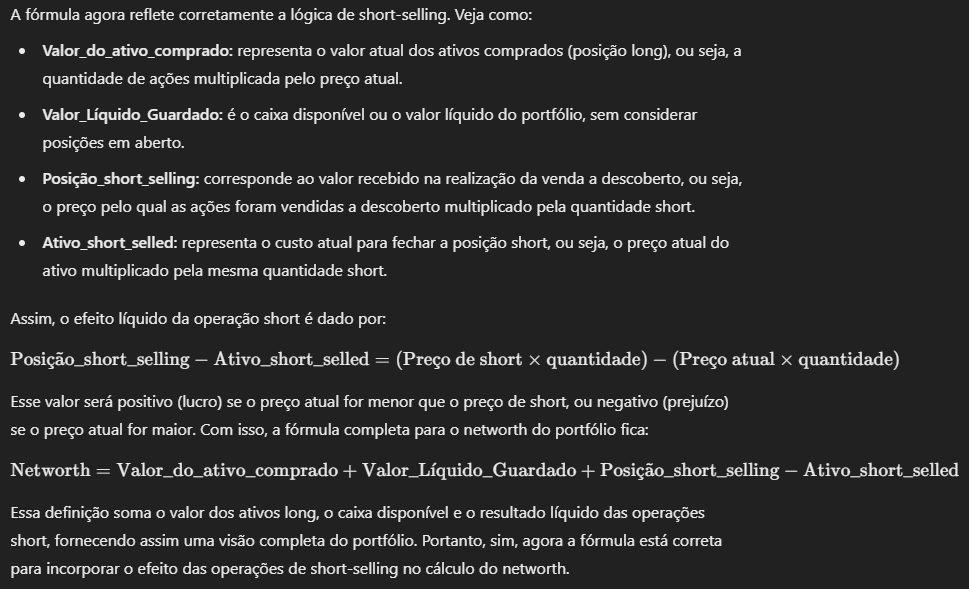

Temos de fazer alguns ajustes á estratégia de trading:

1. O número máximo de ações ás quais dás short-selling em valor numerário tem de corresponder ao valor de dinheiro liquido do portifólio.

2. Para calcular a networth do portfólio o valor de uma operação short-selling apenas deve contar para a networth após o short-selling ser coberto, até lá o dinheiro adquirido com a posição short-selled não deve entrar para o calculo da networth do portefólio.

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

Sensibilidade Decisiva trata-se do valor decimal que estipula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Iniciar os arrays de resultados para guardar os resultados das estretégias estudadas.

In [43]:
Results_Last_cS_array = []
Results_Mean_cS_array = []

### **Buy and Hold Classic**

Evolução natural de uma carteira sem estratégia (evolução do mercado).

Este código simula o que é que aconteceria se fosse gasto todo o dinheiro do portefólio em ações e no final do periodo temporal do dataset de teste vendidas todas as ações compradas no inicio. Estrtégia natural = holding basico.

In [44]:
# Inicializar variáveis para a evolução natural do mercado
initial_fund_natural = 100000  # Fundo inicial de $100,000
natural_fund = initial_fund_natural

# Comprar ações no segundo índice do tensor (primeira operação de compra)
initial_price_natural = float(tensor_np[1][0])  # Preço da ação no segundo índice
num_shares_natural = (
    natural_fund / initial_price_natural
)  # Quantidade de ações compradas (fracionárias)
natural_fund -= (
    num_shares_natural * initial_price_natural
)  # Atualiza o fundo após compra

print(
    f"Comprado {num_shares_natural:.6f} ações a {initial_price_natural} cada, fundo restante: ${natural_fund:.2f}"
)

# No final do tensor, vender todas as ações restantes
final_price_natural = float(tensor_np[-1][0])  # Preço final para venda
natural_fund += (
    num_shares_natural * final_price_natural
)  # Vende todas as ações restantes

print(
    f"Vendido {num_shares_natural:.6f} ações a {final_price_natural} cada no final, fundo total: ${natural_fund:.2f}"
)

# Calcular o percentual de crescimento
initial_investment = initial_fund_natural
final_value = natural_fund
percentage_increase = ((final_value - initial_investment) / initial_investment) * 100

print(
    f"\nPercentual de crescimento do fundo com a estratégia natural: {percentage_increase:.3f}%"
)

Comprado 591.575958 ações a 169.04 cada, fundo restante: $0.00
Vendido 591.575958 ações a 192.15 cada no final, fundo total: $113671.32

Percentual de crescimento do fundo com a estratégia natural: 13.671%


Este código permite dar plot ao que está a acontecer no mercado, que para o caso desta estratégia é o mesmo que está a acontecer á networth do nosso portafólio durante o período temporal do dataset de teste. Usando os closes como indicadores de preço do ativo em função do tempo. Calro que com uma maior ganularidade e se também se tivesse em conta o open a resolução do gráfico seria maior, mas a resolução do gráfico de nada afeta o estudo da estratégia e a sua veracidade, portanto não foi tido em conta, pois esses dados também nesta etapa já não se encontram disponíveis pois forma tratados. Para além disso se este problema da resolução do gráfico apenas é verdade se se encarar o gráfico como uma representação do mercad, no entanto se se encarar o gráfico como a networth ao longo do tempo do portefólio sobre esta estretégia o gráfico esté perfeito e a resolução maximizada.

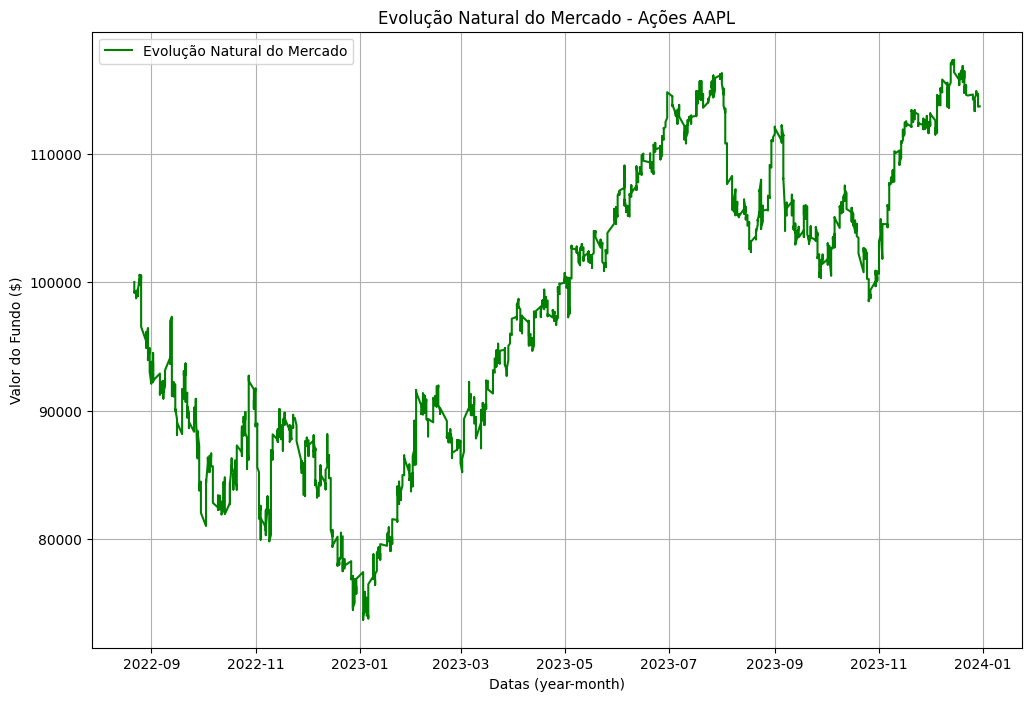

In [45]:
# Criar uma lista para armazenar a evolução do valor do fundo para a evolução natural do mercado
natural_fund_values = []

# Inicializar variáveis para a evolução natural do mercado
initial_fund = 100000  # Fundo inicial de $100,000
initial_price_natural = float(
    tensor_np[1][0]
)  # Preço da ação no segundo índice do tensor
num_shares_natural = (
    initial_fund / initial_price_natural
)  # Ações fracionárias compradas
current_fund_natural = initial_fund - num_shares_natural * initial_price_natural

# A primeira posição do fundo natural é logo após a compra inicial
natural_fund_values.append(
    current_fund_natural + num_shares_natural * initial_price_natural
)

# Simular a evolução natural do mercado
for i in range(1, len(tensor_np)):
    price = float(tensor_np[i][0])

    if i < len(tensor_np) - 1:
        # Atualizar a evolução natural do mercado ao longo do tempo
        natural_fund_values.append(current_fund_natural + num_shares_natural * price)

# Registrar o valor final para a evolução natural
final_price_natural = float(tensor_np[-1][0])
natural_fund_values.append(
    current_fund_natural + num_shares_natural * final_price_natural
)

# Gerar o gráfico da evolução do fundo
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title("Evolução Natural do Mercado - Ações " + symbol)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

### **Absolute Buy and Sell com Short-Selling**

Comprar em absoluto, ou seja, gastar todo o dinheiro da carteira ao primeiro sinal positivo "1". Buy and Hold, ou seja, manter todo o dinheiro nas ações uma vez executada a compra, até o sinal positivo "1" se alterar. Vender em absoluto, ou seja, vender todo o dinheiro das ações ao primeiro sinal negativo "0" e aplicar um posição short-selling, manter a posição short-selling até o sinal negativo "0" se alterar. Repetir infinitamente o processo.



**Estudo da Melhor Sensibilidade Decisiva:**

Sensibilidade Decisiva trata-se do valor decimal que estibula a fronteira numerica entre o modelo dizer que uma probabilidade prevista corresponde à label 1 ou 0. A sensibilidade decisiva por default assume-se como 0.5. No entanto, a ideia é investigar exatamente qual é a mais correta consoante o modelo e consoate a estratégia de gestão de portefólio.

Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva utilizada sinalarizará a melhor sensibilidade decisiva para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor sensibilidade decisiva.

Coordenadas do ponto mais elevado: Sensibilidade Decisiva = 0.76, Melhoria Percentual = 50.21%


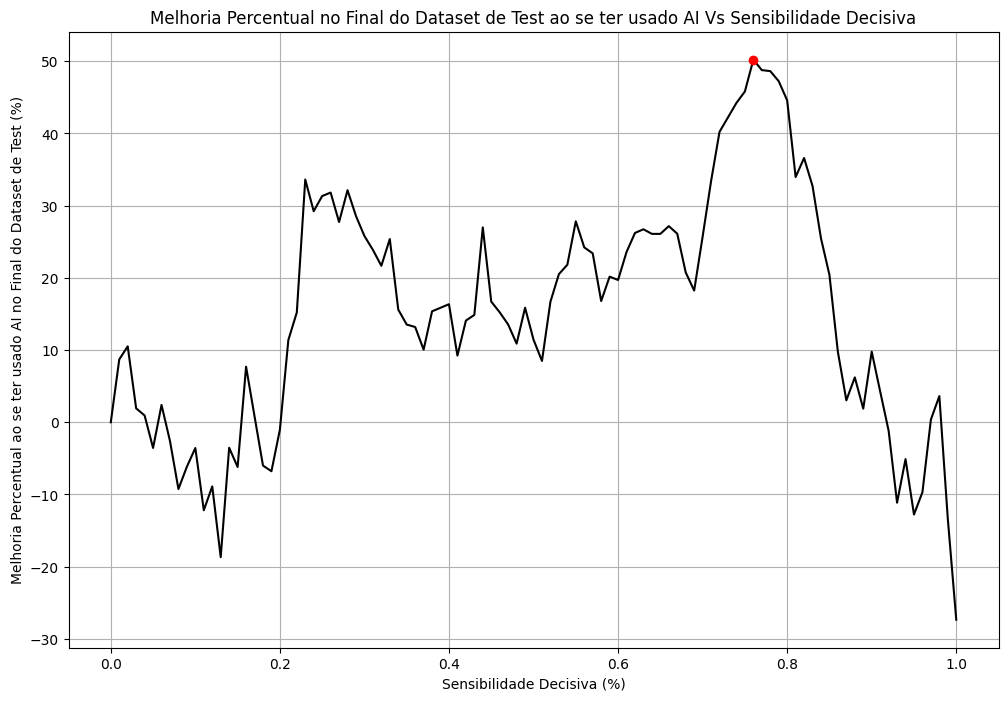

In [46]:
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
percentages_diference_array = []

for a in range(len(sensibilidade_decisiva_array)):
    # Inicializar variáveis
    initial_fund = 100000  # Fundo inicial de $100,000
    fund = initial_fund
    num_shares = 0.0  # Posição long (ações compradas)
    num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0  # Preço de abertura da operação short

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço atual para execução
        prediction_str = tensor_np[i][1]  # Previsão no período atual

        if prediction_str != "none":  # Ignorar entradas sem previsão
            prediction = float(prediction_str)
        else:
            continue

        # Se a previsão for fortemente positiva: operar posição long
        if prediction > sensibilidade_decisiva_array[a]:
            # Se houver posição short aberta, cobrir a posição short
            if num_shares_short > 0:
                # Calcular o lucro/prejuízo da operação short: (short_sale_price - current_price) * quantidade
                profit = num_shares_short * (short_sale_price - current_price)
                fund += profit
                # Após a cobertura, a operação short não influencia mais a networth
                num_shares_short = 0.0
                short_sale_price = 0.0

            # Comprar ações (posição long) se houver caixa disponível
            if fund > 0:
                num_shares_to_buy = fund / current_price
                cost = num_shares_to_buy * current_price
                fund -= cost
                num_shares += num_shares_to_buy

        # Se a previsão for fortemente negativa: operar short-selling
        elif prediction <= sensibilidade_decisiva_array[a]:
            # Se houver posição long, vender para liberar caixa
            if num_shares > 0:
                proceeds = num_shares * current_price
                fund += proceeds
                num_shares = 0.0
            # Se não houver posição short aberta, iniciar a operação short
            if num_shares_short == 0:
                num_shares_to_short = fund / current_price
                # NÃO creditamos o valor recebido – o fundo permanece inalterado (valor bloqueado como garantia)
                num_shares_short = num_shares_to_short
                short_sale_price = current_price
        # Zona neutra: nenhuma operação
        else:
            pass

    # Ao final do tensor, fechar quaisquer posições abertas
    final_price = float(tensor_np[-1][0])
    # Fechar posição long, se houver
    if num_shares > 0:
        proceeds = num_shares * final_price
        fund += proceeds
        num_shares = 0.0

    # Fechar posição short, se houver (só então o efeito é incorporado à networth)
    if num_shares_short > 0:
        profit = num_shares_short * (short_sale_price - final_price)
        fund += profit
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Cálculo final do networth (todas as posições já foram fechadas)
    networth = fund
    percentage_increase_strategy = ((networth - initial_fund) / initial_fund) * 100

    # Armazenar a diferença percentual em relação à estratégia natural
    percentages_diference_array.append(
        percentage_increase_strategy - percentage_increase
    )

# Encontrar o índice do maior valor em percentages_diference_array
max_index = np.argmax(percentages_diference_array)
max_sensibilidade = sensibilidade_decisiva_array[max_index]
max_percentage_difference = percentages_diference_array[max_index]

print(
    f"Coordenadas do ponto mais elevado: Sensibilidade Decisiva = {max_sensibilidade:.2f}, Melhoria Percentual = {max_percentage_difference:.2f}%"
)
Results_Last_cS_array.append([max_sensibilidade, max_percentage_difference])

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(sensibilidade_decisiva_array, percentages_diference_array, color="black")
plt.scatter(
    max_sensibilidade, max_percentage_difference, color="red", zorder=5
)  # Destacar o ponto mais elevado
plt.title(
    "Melhoria Percentual no Final do Dataset de Test ao se ter usado AI Vs Sensibilidade Decisiva"
)
plt.xlabel("Sensibilidade Decisiva (%)")
plt.ylabel("Melhoria Percentual ao se ter usado AI no Final do Dataset de Test (%)")
plt.grid(True)
plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a sensibilidade decisiva que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor sensibilidade decisiva parqa este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

A seguir, apresento o código atualizado com a nova lógica para calcular a média da diferença percentual ao longo do tempo, incorporando o short-selling conforme as seguintes regras:

Ao abrir uma posição short, a quantidade vendida é determinada com base no dinheiro líquido disponível (isto é,
  num_shares_to_short = fund_strategy / current_price), mas os proceeds da venda não são creditados ao fundo (ficam bloqueados como garantia).

Enquanto a posição short estiver aberta, o short não afeta a networth (que é calculada como o valor do fundo mais os ativos long, isto é,
  networth = fund_strategy + num_shares_strategy * current_price).

Quando a posição short é coberta (por uma previsão forte positiva), o lucro ou prejuízo da operação short é realizado (calculado como
  num_shares_short_strategy * (short_sale_price_strategy - current_price)) e somado ao fundo.

O código abaixo utiliza essas regras para calcular, em cada iteração do tensor, a evolução da networth da estratégia e, ao final, a média da diferença percentual em relação à estratégia natural (representada por natural_fund_values):

Explicação dos pontos principais:
Operação Long:
Se a previsão for alta (acima do threshold) e houver caixa disponível, antes de comprar ações o código verifica se há um short aberto. Se houver, a posição short é coberta – realizando o lucro ou prejuízo (que é então adicionado ao fundo) – e somente depois a compra long é executada.

Operação Short:
Se a previsão for fortemente negativa (abaixo de
−
−threshold), se houver uma posição long, ela é vendida para liberar caixa. Em seguida, se não houver short aberto, o short é iniciado. A quantidade vendida é definida por num_shares_to_short = fund_strategy / current_price e os proceeds não são creditados ao fundo (o dinheiro permanece bloqueado como garantia).

Cálculo da Networth:
Enquanto uma posição short estiver aberta, o valor da operação short não entra na networth (ela é calculada apenas como fund_strategy + num_shares_strategy * current_price). Só ao fechar o short o efeito (lucro ou prejuízo) é realizado e incorporado ao fundo.

Cálculo da Diferença Percentual:
Para cada valor de sensibilidade, é calculada a média da diferença percentual entre a evolução da networth da estratégia AI e a estratégia natural (valores em natural_fund_values).

Coordenadas do ponto mais elevado: Sensibilidade Decisiva = 0.78, Média Diferença Percentual = 37.21%


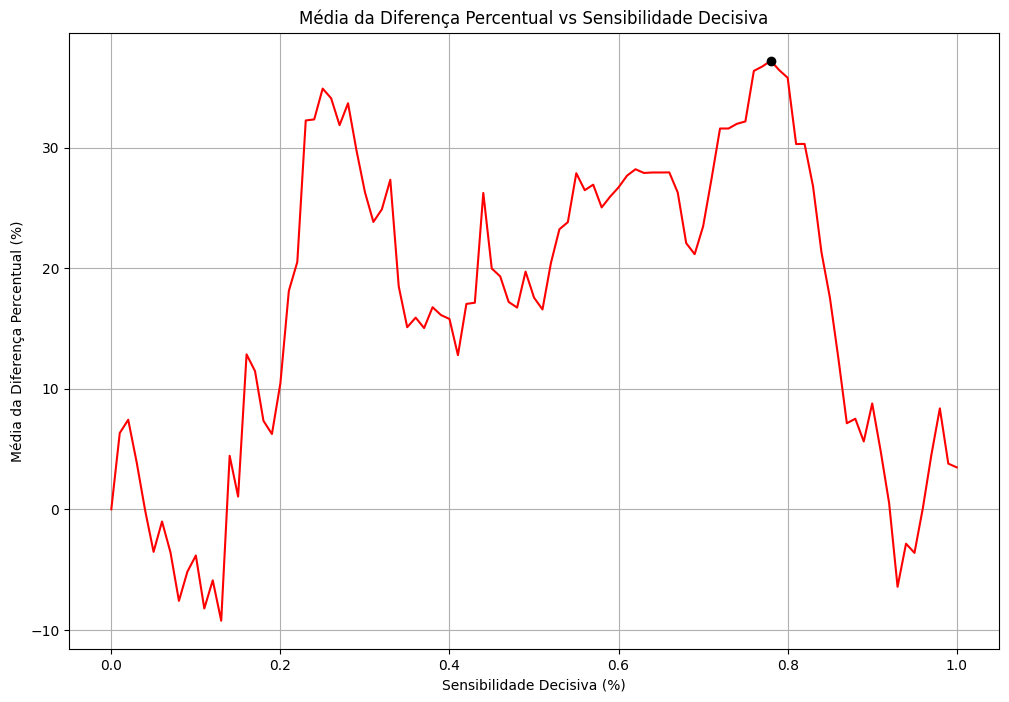

In [47]:
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
media_diff_percentual_array = []  # Armazenar as médias das diferenças percentuais

for a in range(len(sensibilidade_decisiva_array)):
    # Inicializar variáveis
    initial_fund = 100000  # Fundo inicial de $100,000
    fund_strategy = initial_fund
    num_shares_strategy = 0.0  # Posição long (ações compradas)
    num_shares_short_strategy = 0.0  # Posição short (ações vendidas a descoberto)
    short_sale_price_strategy = 0.0  # Preço de abertura do short
    networth_strategy = []  # Evolução da networth ao longo do tempo

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação no período atual
        prediction_str = tensor_np[i][1]  # Previsão do modelo

        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            continue

        # OPERACAO LONG: previsão fortemente positiva e há caixa disponível
        if prediction > sensibilidade_decisiva_array[a] and fund_strategy > 0:
            # Se houver posição short aberta, cobrir (fechar) a operação short
            if num_shares_short_strategy > 0:
                # Ao fechar, realizar lucro/prejuízo: (short_sale_price - current_price) * quantidade
                profit = num_shares_short_strategy * (
                    short_sale_price_strategy - current_price
                )
                fund_strategy += profit
                num_shares_short_strategy = 0.0
                short_sale_price_strategy = 0.0

            # Comprar ações com o caixa disponível (posição long)
            num_shares_to_buy = fund_strategy / current_price
            cost = num_shares_to_buy * current_price
            fund_strategy -= cost
            num_shares_strategy += num_shares_to_buy

        # OPERACAO SHORT: previsão fortemente negativa
        elif prediction <= sensibilidade_decisiva_array[a]:
            # Se houver posição long, vender para liberar caixa
            if num_shares_strategy > 0:
                proceeds = num_shares_strategy * current_price
                fund_strategy += proceeds
                num_shares_strategy = 0.0
            # Se não houver posição short aberta, iniciar o short-selling
            if num_shares_short_strategy == 0:
                num_shares_to_short = fund_strategy / current_price
                # Não creditamos os proceeds – o valor fica bloqueado como garantia
                num_shares_short_strategy = num_shares_to_short
                short_sale_price_strategy = current_price

        # Zona neutra: nenhuma operação
        else:
            pass

        # Calcular a networth no período atual:
        # Enquanto a posição short estiver aberta, ela não é considerada (a networth inclui apenas fund_strategy e posições long)
        current_networth = fund_strategy + num_shares_strategy * current_price
        networth_strategy.append(current_networth)

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_np[-1][0])

    # Fechar posição long, se houver
    if num_shares_strategy > 0:
        proceeds_long = num_shares_strategy * final_price
        fund_strategy += proceeds_long
        num_shares_strategy = 0.0

    # Fechar posição short, se houver (realizando o lucro ou prejuízo do short)
    if num_shares_short_strategy > 0:
        profit = num_shares_short_strategy * (short_sale_price_strategy - final_price)
        fund_strategy += profit
        num_shares_short_strategy = 0.0
        short_sale_price_strategy = 0.0

    # Registrar o valor final do fundo
    networth_strategy.append(fund_strategy)

    # Calcular a diferença percentual entre a estratégia AI e a estratégia natural
    diff_percentual = (
        (np.array(networth_strategy) - np.array(natural_fund_values))
        / np.array(natural_fund_values)
    ) * 100
    media_diff_percentual = np.mean(diff_percentual)  # Média da diferença percentual
    media_diff_percentual_array.append(media_diff_percentual)

# Encontrar o índice do maior valor
max_index = np.argmax(media_diff_percentual_array)
max_sensibilidade = sensibilidade_decisiva_array[max_index]
max_percentage_difference = media_diff_percentual_array[max_index]

print(
    f"Coordenadas do ponto mais elevado: Sensibilidade Decisiva = {max_sensibilidade:.2f}, Média Diferença Percentual = {max_percentage_difference:.2f}%"
)
Results_Mean_cS_array.append([max_sensibilidade, max_percentage_difference])

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(sensibilidade_decisiva_array, media_diff_percentual_array, color="red")
plt.scatter(
    max_sensibilidade, max_percentage_difference, color="black", zorder=5
)  # Destacar o ponto mais elevado
plt.title("Média da Diferença Percentual vs Sensibilidade Decisiva")
plt.xlabel("Sensibilidade Decisiva (%)")
plt.ylabel("Média da Diferença Percentual (%)")
plt.grid(True)
plt.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para um valor em especifico de sensibilidade decisiva.

Geralmente a ideia é analisar detalhadamente o que é que acontec com o valor considerado ideal encotrado anteriormente.

Escolhe-se o valor da sensibilidade decisiva que se quer estudar.

In [48]:
sensibilidade_decisiva = max_sensibilidade
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")

Sensibilidade Decisiva: 0.78


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [49]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Posição long (ações compradas)
num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
short_sale_price = 0.0  # Preço de abertura da operação short
total_ops = 0.0  # Valor total das operações realizadas
networth_strategy_array = []

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = tensor_np[i + 1][0]  # Preço da ação para a operação
    prediction_raw = tensor_np[i][1]  # Previsão atual

    if prediction_raw != "none":
        prediction = float(prediction_raw)
    else:
        prediction = 0.0

    # Determinar sinal: 1 se previsão for alta, 0 caso contrário
    signal = 1 if prediction > sensibilidade_decisiva else 0

    # Operação Long: se previsão for alta
    if prediction > sensibilidade_decisiva:
        # Se houver posição short aberta, cobrir primeiro
        if num_shares_short > 0:
            profit = num_shares_short * (short_sale_price - current_price)
            fund += profit
            total_ops += (
                num_shares_short * current_price
            )  # valor da operação de cobertura
            print(
                f"[Período {i}] COBERTURA SHORT: Fechado {num_shares_short:.6f} ações short a {current_price} por ${num_shares_short * current_price:.2f}. Lucro/Prejuízo: ${profit:.2f}. Novo fundo: ${fund:.2f}."
            )
            num_shares_short = 0.0
            short_sale_price = 0.0
        # Comprar ações (posição long) com o fundo disponível
        if fund > 0:
            num_shares_to_buy = fund / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            total_ops += cost
            num_shares += num_shares_to_buy
            print(
                f"[Período {i}] COMPRA LONG: Comprado {num_shares_to_buy:.6f} ações a {current_price} por ${cost:.2f}. Liquidez: ${fund:.2f}."
            )
    # Operação Short: se previsão for baixa (<= sensibilidade_decisiva)
    elif prediction <= sensibilidade_decisiva:
        # Se houver posição long, vender para liberar caixa
        if num_shares > 0:
            proceeds = num_shares * current_price
            fund += proceeds
            total_ops += proceeds
            print(
                f"[Período {i}] VENDA LONG: Vendido {num_shares:.6f} ações a {current_price} por ${proceeds:.2f}. Liquidez: ${fund:.2f}."
            )
            num_shares = 0.0
        # Se não houver posição short aberta, iniciar a operação short
        if num_shares_short == 0:
            num_shares_to_short = fund / current_price
            total_ops += num_shares_to_short * current_price
            num_shares_short = num_shares_to_short
            short_sale_price = current_price
            print(
                f"[Período {i}] ABERTURA SHORT: Vendido a descoberto {num_shares_to_short:.6f} ações a {current_price} por ${num_shares_to_short * current_price:.2f}. (Fundo permanece: ${fund:.2f})."
            )
    else:
        print(
            f"[Período {i}] SEM OPERAÇÃO: Previsão {prediction} dentro do intervalo neutro."
        )

    # Cálculo da networth do portfólio (contando somente o fundo e posições long)
    current_networth = fund + num_shares * current_price
    print(
        f"[Período {i}] Networth: ${current_networth:.2f} | Preço: {current_price} | Prediction: {prediction:.5f} | Sinal: {signal}"
    )
    networth_strategy_array.append(current_networth)

# Ao final do tensor, fechar quaisquer posições abertas:
final_price = tensor_np[-1][0]

# Fechar posição long, se houver
if num_shares > 0:
    proceeds = num_shares * final_price
    fund += proceeds
    total_ops += proceeds
    print(
        f"[Final] FECHAMENTO LONG: Vendido {num_shares:.6f} ações a {final_price} por ${proceeds:.2f}."
    )
    num_shares = 0.0

# Fechar posição short, se houver (realizando lucro ou prejuízo do short)
if num_shares_short > 0:
    profit = num_shares_short * (short_sale_price - final_price)
    fund += profit
    total_ops += num_shares_short * final_price  # valor da operação de cobertura
    print(
        f"[Final] FECHAMENTO SHORT: Fechado {num_shares_short:.6f} ações short a {final_price} por ${num_shares_short * final_price:.2f}. Lucro/Prejuízo: ${profit:.2f}."
    )
    num_shares_short = 0.0
    short_sale_price = 0.0

print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")
networth_strategy_array.append(fund)
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"Percentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%"
)
print(f"Valor Total das Operações Realizadas: ${total_ops:.2f}")

[Período 0] ABERTURA SHORT: Vendido a descoberto 591.575958 ações a 169.04 por $100000.00. (Fundo permanece: $100000.00).
[Período 0] Networth: $100000.00 | Preço: 169.04 | Prediction: 0.10404 | Sinal: 0
[Período 1] Networth: $100000.00 | Preço: 169.015 | Prediction: 0.14351 | Sinal: 0
[Período 2] Networth: $100000.00 | Preço: 167.655 | Prediction: 0.13901 | Sinal: 0
[Período 3] Networth: $100000.00 | Preço: 167.7 | Prediction: 0.33015 | Sinal: 0
[Período 4] COBERTURA SHORT: Fechado 591.575958 ações short a 167.87 por $99307.86. Lucro/Prejuízo: $692.14. Novo fundo: $100692.14.
[Período 4] COMPRA LONG: Comprado 599.822147 ações a 167.87 por $100692.14. Liquidez: $0.00.
[Período 4] Networth: $100692.14 | Preço: 167.87 | Prediction: 0.99795 | Sinal: 1
[Período 5] Networth: $100452.22 | Preço: 167.47 | Prediction: 0.99421 | Sinal: 1
[Período 6] VENDA LONG: Vendido 599.822147 ações a 167.365 por $100389.23. Liquidez: $100389.23.
[Período 6] ABERTURA SHORT: Vendido a descoberto 599.822147 aç

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo.

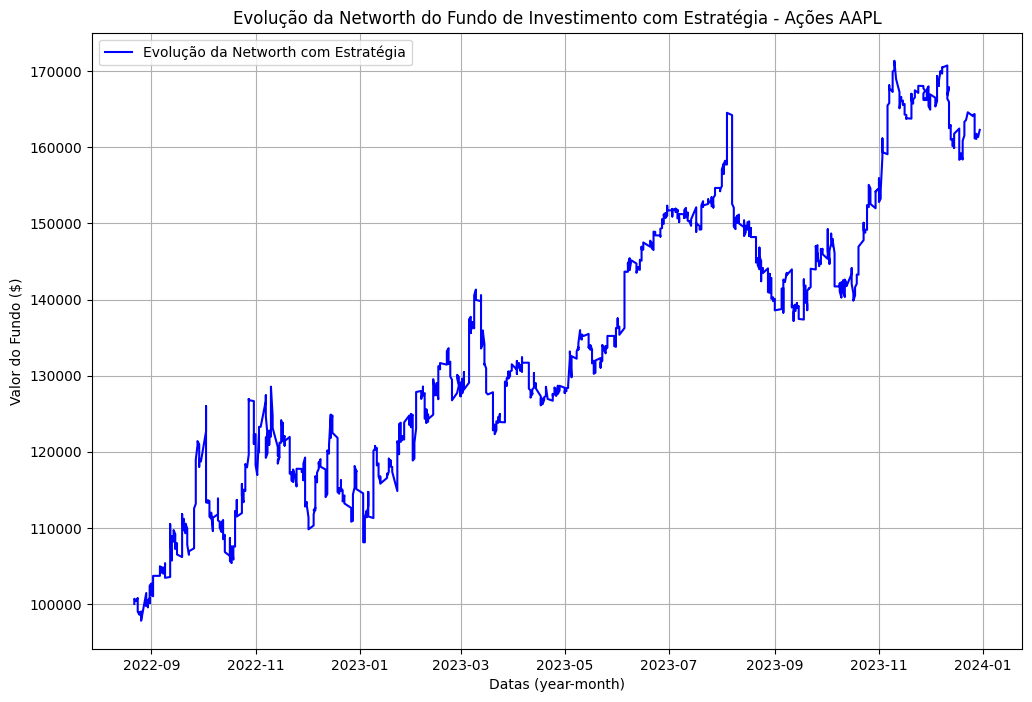

In [50]:
# Gerar o gráfico da evolução da networth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy_array,
    label="Evolução da Networth com Estratégia",
    color="blue",
)
plt.title(
    "Evolução da Networth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

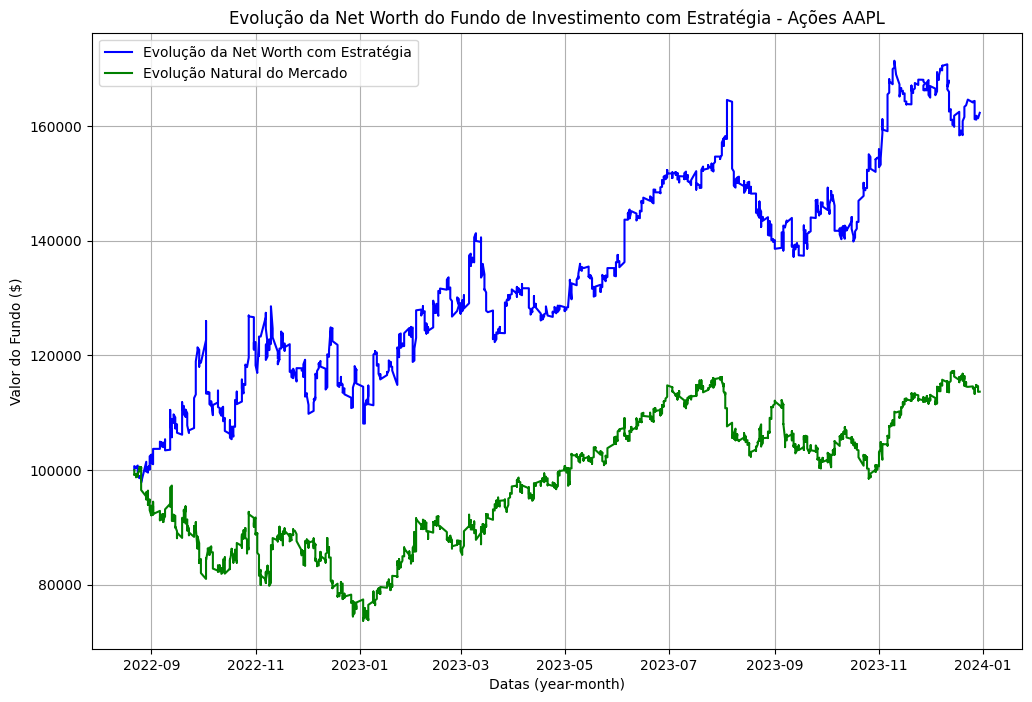

In [51]:
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy_array,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [52]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Dinheiro extra ganho ao se ter usado AI: 48618.991$

Melhoria percentual ao se ter usado AI: 48.633%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. O valor da sensibilidade decisiva deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2022-11-10
Diferença Percentual Máxima: 59.93%
Média da Diferença Percentual ao Longo de Todo o Gráfico: 37.21%


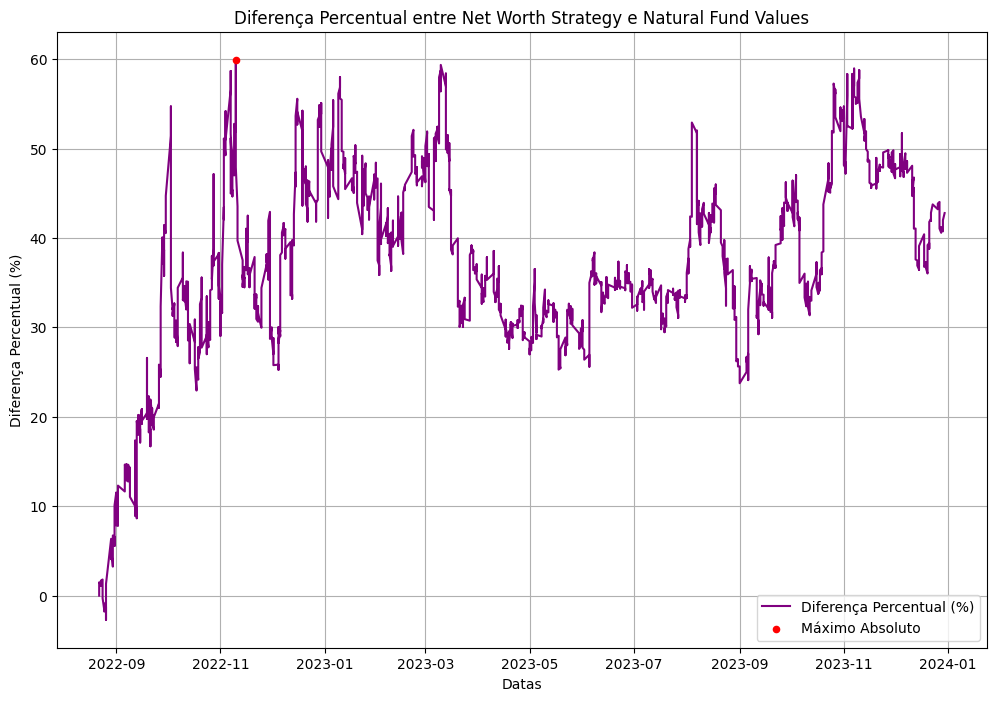

In [53]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy_array) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

Pela teoria dos grandes números basta o modelo ter uma precisão superior a 50% para que em média quanto mais tempo deixaremos a correr o modelo, ou seja, quantas mais iterasões (previsões) o modelo fizer sobre a bolsa com a estratégia correta mais os retornos da AI se vão distanciar de um simple holder, mais o modelo vai dar outeperform ao mercado. Portanto em teoria quanto mais tempo o modelo correr melhores seram os resultados.

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.

Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $9798127.78, Percentual de Crescimento = 62.304%


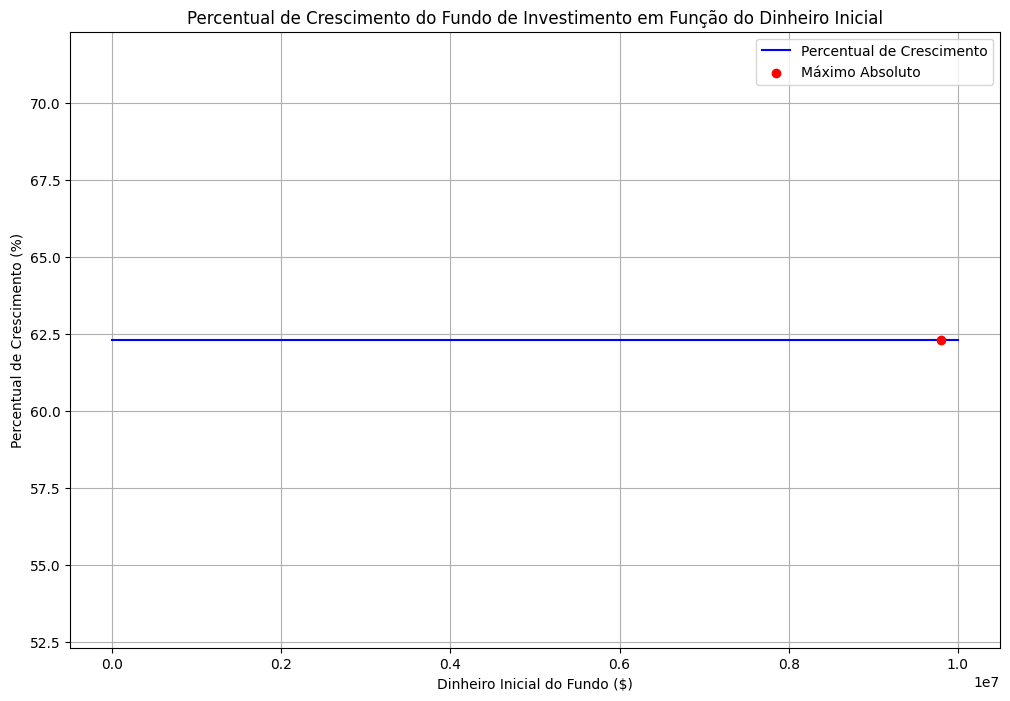

In [54]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,000

# Listas para armazenar os resultados
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Posição long (ações compradas)
    num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0  # Preço de abertura da operação short

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
        prediction_str = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Converter a previsão para float ou definir 0 se for 'none'
        if prediction_str != "none":
            prediction = float(prediction_str)
        else:
            prediction = 0

        # Operação LONG: previsão fortemente positiva e há caixa disponível
        if prediction > sensibilidade_decisiva and fund > 0:
            # Se houver posição short aberta, cobrir (fechar) o short primeiro
            if num_shares_short > 0:
                # Realizar lucro/prejuízo: (short_sale_price - current_price) * quantidade
                profit = num_shares_short * (short_sale_price - current_price)
                fund += profit
                # Fechando a posição short
                num_shares_short = 0.0
                short_sale_price = 0.0
            # Comprar ações (posição long) com o caixa disponível
            num_shares_to_buy = fund / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            num_shares += num_shares_to_buy

        # Operação SHORT: previsão fortemente negativa
        elif prediction <= sensibilidade_decisiva:
            # Se houver posição long, vender para liberar caixa
            if num_shares > 0:
                proceeds = num_shares * current_price
                fund += proceeds
                num_shares = 0.0
            # Se não houver posição short aberta, iniciar a operação short
            if num_shares_short == 0:
                num_shares_to_short = fund / current_price
                # NÃO creditamos o valor recebido; o fundo permanece inalterado
                num_shares_short = num_shares_to_short
                short_sale_price = current_price
        else:
            # Sem operação se previsão estiver neutra
            pass

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_np[-1][0])

    # Fechar posição long, se houver
    if num_shares > 0:
        proceeds = num_shares * final_price
        fund += proceeds
        num_shares = 0.0

    # Fechar posição short, se houver (realizando lucro ou prejuízo do short)
    if num_shares_short > 0:
        profit = num_shares_short * (short_sale_price - final_price)
        fund += profit
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Calcular o percentual de crescimento
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(
    f"Coordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    percentual_ganhos,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)  # Destacar o ponto máximo
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

### **Independent Parcial Buy and Sell in Function of Predictions Probabilaty**

Agora eu quero testar uma nova estratégia. As compras e as vendas vão ser de forma percentual. Ou seja, sempre que existe um sinal positivo para compra - "1", deve ser gasto "coeficiente * grau_certeza"% (o grau_certeza é dado por "predictions", relembrando que sempre que "predictions" é superior a "sensibilidade_decisiva" é um "1" e sempre que "predictions" é inferior a "sensibilidade_decisiva" é um "0", o grau_certeza é pela certeza que o modelo tem se se trata de um "0" ou de um "1", isto pode ser inferido através de "predictions") do dinheiro do fundo de investimento na compra de ações, se existir algum dinheiro ainda no fundo para o fazer de acordo com o percentual calculado. Sempre que existe um sinal positivo de venda - "0", devem ser vendidas "coeficiente * grau_certeza"% das ações do fundo de investimento, se o fundo tiver ainda ações suficientes para o fazer de acordo com a percentagem calculada. A questão que aqui diferencia da passada estratégia é que agora vão existir 2 coeficientes em jogo um coeficente para ações de venda, coeficiente_v, outro para ações de compra, coeficiente_c.

Esta estratégia é extremamente semelhante á anterior apenas é acrecenta um novo coeficiente e para tal terá de ser distinguido o coeficiente de buy do coeficiente de sell.

if prediction > sensibilidade_decisiva and fund > 0:
    grau_certeza = abs(prediction)  # Grau de certeza do modelo
    # Comprar ações com base no percentual calculado
    amount_to_invest = coeficiente_c * grau_certeza * fund
    num_shares_to_buy = amount_to_invest / current_price  # Quantidade de ações que podemos comprar (fracionária)
    fund -= num_shares_to_buy * current_price  # Atualiza o fundo após compra
    num_shares += num_shares_to_buy  # Atualiza o número de ações

elif prediction <= sensibilidade_decisiva and num_shares > 0:
    grau_certeza = abs(1 - prediction)  # Grau de certeza do modelo
    # Vender ações com base no percentual calculado
    amount_to_sell = coeficiente_v * grau_certeza * num_shares  # Quantidade de ações a vender
    num_shares_to_sell = amount_to_sell  # Quantidade fracionária de ações a vender
    fund += num_shares_to_sell * current_price  # Vende as ações e atualiza o fundo
    num_shares -= num_shares_to_sell  # Atualiza o número de ações após a venda

Por este código passam 3 loops diferentes todos uns dentro uns dos outros assim consigo garantir que para cada coeficiente de compra é testado para todos os valores de coeficiente de venda e para todos os valores de sensibilidade decisiva.

**Estudo do Melhor Coeficiente e Melhor Sensibilidade Decisiva para Formatar o Percentual Investido:**


Assim este código permite plotar e analisar os retornos financeiros da estratégia implementada em função do valor da sensibilidade decisiva e do coeficientes. O portefólio que ao começar com 100 000$ tiver os maiores retornos financeiros com a sensibilidade decisiva e com o coeficientes utilizados sinalarizará a melhor combinação sensibilidade decisiva, coeficiente para a estratégia de gestão de portefólio e para o modelo.

É imporante destacar que o gráfico apresentado e os valores tidos em conta para escolher a sensibilidade decisiva pelo facto de estaremos à procura de uma estratégia que "derrote" o mercado o valor de retorno ao se estudar a estratégia é originado pela seguinte formula:

retorno percetual do investimento inicial da estratégia em estudo com a sensibilidade decisiva e coefieciente em vigor - retorno percentual do investimento inicial para um simples buy em holder = melhoria percentual

a melhoria percentual mais elevada corresponde á melhor combinação sensibilidade decisiva, coeficientes.

Coordenadas do ponto com o valor máximo de ganho percentual ajustado:
Sensibilidade Decisiva = 0.76, Coeficiente C = 2.00, Coeficiente V = 5.00, Coeficiente S = 2.00, Ganho Percentual Ajustado (%) = 51.4516


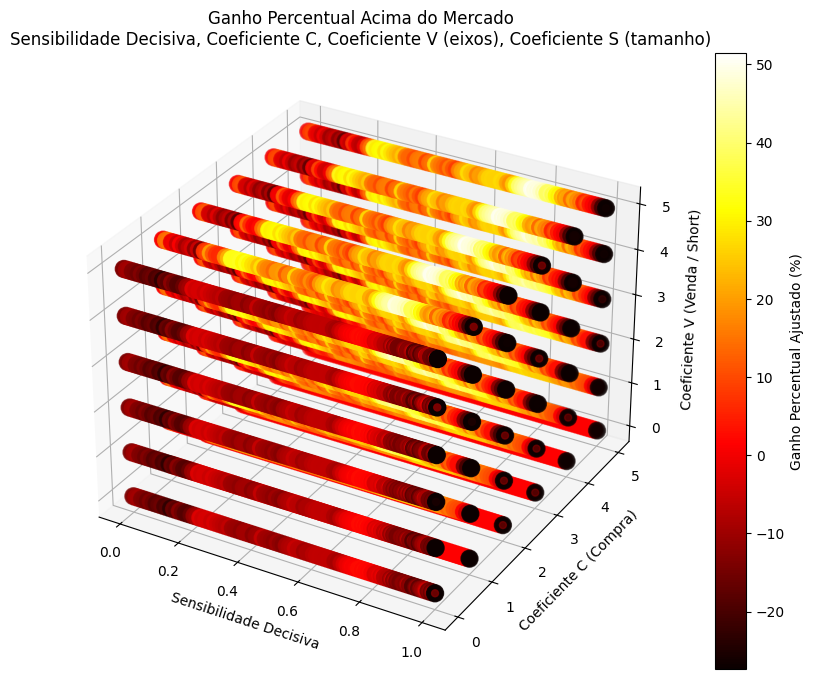

In [55]:
from mpl_toolkits.mplot3d import Axes3D

# Arrays para os parâmetros:
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_c_array = np.arange(0, 6, 1)
coeficiente_v_array = np.arange(0, 6, 1)
coeficiente_s_array = np.arange(0, 6, 1)  # Coeficiente de short-selling

# Fundo inicial e baseline para comparação
initial_fund = 100000  # Fundo inicial de $100,000
# Supondo que percentage_increase seja definido (por exemplo, o ganho do benchmark)
# Caso não esteja definido, remova a subtração em gain_adjusted.

# Listas para armazenar as coordenadas e o ganho ajustado
x_vals = []  # Sensibilidade Decisiva
y_vals = []  # Coeficiente C (Compra)
z_vals = []  # Coeficiente V (Venda / Short)
w_vals = []  # Coeficiente S (Short-selling)
color_vals = []  # Ganho Percentual Ajustado

# Loop sobre todas as combinações dos parâmetros
for sensibilidade_decisiva in sensibilidade_decisiva_array:
    for coeficiente_c in coeficiente_c_array:
        for coeficiente_v in coeficiente_v_array:
            for coeficiente_s in coeficiente_s_array:
                # Inicialização das variáveis de controle para cada simulação
                fund = initial_fund
                num_shares = 0.0  # Posição long
                num_shares_short = 0.0  # Posição short
                short_sale_price = 0.0  # Preço de abertura do short

                # Itera sobre o tensor (exceto o último, sem previsão)
                for m in range(len(tensor_np) - 1):
                    current_price = float(tensor_np[m + 1][0])
                    prediction_str = tensor_np[m][1]

                    if prediction_str != "none":
                        prediction = float(prediction_str)
                    else:
                        prediction = 0

                    # Se a previsão for alta (> sensibilidade_decisiva) e houver fundos:
                    if prediction > sensibilidade_decisiva and fund > 0:
                        # Se existir uma posição short aberta, fechá-la primeiro
                        if num_shares_short > 0:
                            profit = num_shares_short * (
                                short_sale_price - current_price
                            )
                            fund += profit
                            num_shares_short = 0.0
                            short_sale_price = 0.0

                        # Executa operação long
                        grau_certeza = abs(prediction)
                        percentage_to_spend = coeficiente_c * grau_certeza
                        if percentage_to_spend > 1:
                            percentage_to_spend = 1
                        amount_to_invest = percentage_to_spend * fund
                        num_shares_to_buy = amount_to_invest / current_price
                        fund -= num_shares_to_buy * current_price
                        num_shares += num_shares_to_buy

                    # Se a previsão for baixa (≤ sensibilidade_decisiva):
                    elif prediction <= sensibilidade_decisiva:
                        # Se houver posição long, vende parte dela conforme coeficiente_v
                        if num_shares > 0:
                            grau_certeza = abs(1 - prediction)
                            percentage_to_sell = coeficiente_v * grau_certeza
                            if percentage_to_sell > 1:
                                percentage_to_sell = 1
                            amount_to_sell = percentage_to_sell * num_shares
                            fund += amount_to_sell * current_price
                            num_shares -= amount_to_sell

                        # Se não houver posição long e ainda não estiver em short, inicia short-selling
                        if num_shares == 0 and num_shares_short == 0 and fund > 0:
                            grau_certeza_short = abs(1 - prediction)
                            percentage_to_short = coeficiente_s * grau_certeza_short
                            if percentage_to_short > 1:
                                percentage_to_short = 1
                            # Utiliza o fundo disponível como capacidade máxima para short-selling
                            amount_to_short = percentage_to_short * fund
                            num_shares_to_short = amount_to_short / current_price
                            num_shares_short = num_shares_to_short
                            short_sale_price = current_price

                # Ao final do tensor, fechar quaisquer posições abertas:
                final_price = float(tensor_np[-1][0])

                # Fechar posição long (vender as ações restantes)
                if num_shares > 0:
                    fund += num_shares * final_price
                    num_shares = 0

                # Fechar posição short (comprar de volta a preço final e calcular lucro/prejuízo)
                if num_shares_short > 0:
                    profit = num_shares_short * (short_sale_price - final_price)
                    fund += profit
                    num_shares_short = 0
                    short_sale_price = 0

                # Calcular o ganho percentual do fundo e ajustar em relação à baseline
                percentual_ganho = ((fund - initial_fund) / initial_fund) * 100
                gain_adjusted = percentual_ganho - percentage_increase

                # Armazenar os parâmetros e o ganho ajustado
                x_vals.append(sensibilidade_decisiva)
                y_vals.append(coeficiente_c)
                z_vals.append(coeficiente_v)
                w_vals.append(coeficiente_s)
                color_vals.append(gain_adjusted)

# Converter para arrays numpy
x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
z_vals = np.array(z_vals)
w_vals = np.array(w_vals)
color_vals = np.array(color_vals)

# Mapeamento no gráfico:
# - Eixos X, Y e Z: Sensibilidade Decisiva, Coeficiente C e Coeficiente V, respectivamente;
# - Tamanho dos marcadores (size): representa o Coeficiente S (short-selling);
# - Cor dos marcadores: representa o Ganho Percentual Ajustado.
sizes = (w_vals * 25) + 25  # Ajuste o fator de escala conforme necessário

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

img = ax.scatter(x_vals, y_vals, z_vals, c=color_vals, cmap="hot", s=sizes)
cbar = fig.colorbar(img)
cbar.set_label("Ganho Percentual Ajustado (%)")

ax.set_title(
    "Ganho Percentual Acima do Mercado\nSensibilidade Decisiva, Coeficiente C, Coeficiente V (eixos), Coeficiente S (tamanho)"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente C (Compra)")
ax.set_zlabel("Coeficiente V (Venda / Short)")

# Identificar o ponto de melhor desempenho
max_index = np.argmax(color_vals)
x_max = x_vals[max_index]
y_max = y_vals[max_index]
z_max = z_vals[max_index]
w_max = w_vals[max_index]
max_gain = color_vals[max_index]

print("Coordenadas do ponto com o valor máximo de ganho percentual ajustado:")
print(
    f"Sensibilidade Decisiva = {x_max:.2f}, Coeficiente C = {y_max:.2f}, Coeficiente V = {z_max:.2f}, Coeficiente S = {w_max:.2f}, Ganho Percentual Ajustado (%) = {max_gain:.4f}"
)
Results_Last_cS_array.append([x_max, y_max, z_max, w_max, max_gain])

plt.show()

Mais tarde precebeu-se que pode ser enganador apenas analisar o retorno no final do periodo temporal do dataset de teste. Para contornar esta questão foi desenvolvida outra metodologia.

Será capturado o retorno financeiro percentual em termos de networth do portefólio comparativamente com o valor inicial dado de 100 000$. Esse retorno financeiro a cada trade executada, ou melhor a cada matriz temporal analisada e prevista pelo o modelo será subtraindo o valor da networth de um portefólio que segue naturalmente o mercado (simple holder), para obter a "melhoria percentual". Mas desta ves estará se a obter a melhoria percentual a cada previsão do modelo. Ao se fazer a média da melhoria percentual ao longo de todas as previsões do modelo, ou seja, ao longo de todo o dataset de teste é possível preceber qual é a combinação sensibilidade decisiva, coeficientes que maximiza o valor da "média da melhoria percentual". Desta forma é possível concluir qual é a melhor combinação sensibilidade decisiva, coeficientes para este modelo e para esta estratégia anulando o impacto de estaremos a olhar para os retornos apenas de um evento temporal como o final do dataset de teste, mas sim tendo em conta a performance do modelo e da estrátegia ao longo de todo o dataset de teste.

Coordenadas do ponto com o valor máximo de média diferença percentual:
Sensibilidade Decisiva = 0.78, Coeficiente C = 2, Coeficiente V = 5, Coeficiente S = 2, Média Diferença Percentual (%) = 38.381585005288734


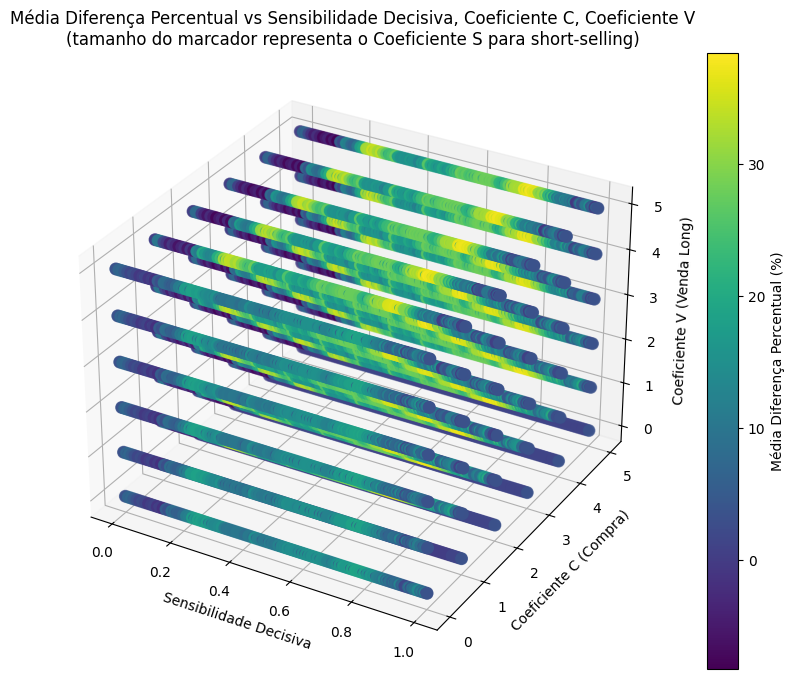

In [57]:
# Arrays para os parâmetros:
sensibilidade_decisiva_array = np.arange(0, 1.01, 0.01)
coeficiente_c_array = np.arange(0, 6, 1)
coeficiente_v_array = np.arange(0, 6, 1)
coeficiente_s_array = np.arange(0, 6, 1)  # Novo coeficiente para short-selling

# Fundo inicial
initial_fund = 100000  # $100,000

# Listas para armazenar as coordenadas e a média da diferença percentual
x_vals = []  # Sensibilidade Decisiva
y_vals = []  # Coeficiente C (compra)
z_vals = []  # Coeficiente V (venda de long)
w_vals = []  # Coeficiente S (short-selling)
color_vals = []  # Média da Diferença Percentual

# Loop para todas as combinações dos parâmetros:
for sensibilidade_decisiva in sensibilidade_decisiva_array:
    for coeficiente_c in coeficiente_c_array:
        for coeficiente_v in coeficiente_v_array:
            for coeficiente_s in coeficiente_s_array:
                # Inicialização das variáveis de controle para cada simulação:
                fund_strategy = initial_fund
                num_shares_strategy = 0.0  # Posição long
                num_shares_short_strategy = 0.0  # Posição short
                short_sale_price_strategy = 0.0  # Preço de abertura do short
                networth_strategy = []  # Evolução do patrimônio líquido

                # Itera sobre os períodos (exceto o último, sem previsão)
                for m in range(len(tensor_np) - 1):
                    current_price = float(tensor_np[m + 1][0])
                    prediction_str = tensor_np[m][1]

                    if prediction_str != "none":
                        prediction = float(prediction_str)
                    else:
                        prediction = 0  # Se não houver previsão, assume 0

                    # SINAL DE COMPRA (LONG):
                    if prediction > sensibilidade_decisiva and fund_strategy > 0:
                        # Se houver posição short aberta, primeiro cobre o short
                        if num_shares_short_strategy > 0:
                            profit = num_shares_short_strategy * (
                                short_sale_price_strategy - current_price
                            )
                            fund_strategy += profit
                            num_shares_short_strategy = 0.0
                            short_sale_price_strategy = 0.0

                        grau_certeza = abs(prediction)
                        percentage_to_invest = coeficiente_c * grau_certeza
                        if percentage_to_invest > 1:
                            percentage_to_invest = 1
                        amount_to_invest = percentage_to_invest * fund_strategy
                        num_shares_to_buy = amount_to_invest / current_price
                        fund_strategy -= num_shares_to_buy * current_price
                        num_shares_strategy += num_shares_to_buy

                    # SINAL DE VENDA / SHORT:
                    elif prediction <= sensibilidade_decisiva:
                        # Se houver posição long, vende uma parte determinada pelo coeficiente_v
                        if num_shares_strategy > 0:
                            grau_certeza = abs(1 - prediction)
                            percentage_to_sell = coeficiente_v * grau_certeza
                            if percentage_to_sell > 1:
                                percentage_to_sell = 1
                            amount_to_sell = percentage_to_sell * num_shares_strategy
                            fund_strategy += amount_to_sell * current_price
                            num_shares_strategy -= amount_to_sell

                        # Capacidade máxima para short-selling é o valor líquido do portfólio
                        current_networth = (
                            fund_strategy + num_shares_strategy * current_price
                        )

                        # Se não houver short aberto, inicia a operação short utilizando o coeficiente_s
                        if num_shares_short_strategy == 0 and current_networth > 0:
                            grau_certeza_short = abs(1 - prediction)
                            percentage_to_short = coeficiente_s * grau_certeza_short
                            if percentage_to_short > 1:
                                percentage_to_short = 1
                            amount_to_short = percentage_to_short * current_networth
                            num_shares_to_short = amount_to_short / current_price
                            num_shares_short_strategy = num_shares_to_short
                            short_sale_price_strategy = current_price

                    # Registrar a evolução do patrimônio (apenas considerando caixa e posição long)
                    current_networth = (
                        fund_strategy + num_shares_strategy * current_price
                    )
                    networth_strategy.append(current_networth)

                # Ao final do tensor, fechar quaisquer posições abertas:
                final_price = float(tensor_np[-1][0])

                # Fechar posição long, se houver
                if num_shares_strategy > 0:
                    fund_strategy += num_shares_strategy * final_price
                    num_shares_strategy = 0

                # Fechar posição short, se houver (realizando lucro ou prejuízo)
                if num_shares_short_strategy > 0:
                    profit = num_shares_short_strategy * (
                        short_sale_price_strategy - final_price
                    )
                    fund_strategy += profit
                    num_shares_short_strategy = 0
                    short_sale_price_strategy = 0

                networth_strategy.append(fund_strategy)

                # Calcular a diferença percentual entre a estratégia e o fundo natural
                diff_percentual = (
                    (np.array(networth_strategy) - np.array(natural_fund_values))
                    / np.array(natural_fund_values)
                ) * 100
                media_diff_percentual = np.mean(diff_percentual)

                # Armazenar os parâmetros e a média da diferença percentual
                x_vals.append(sensibilidade_decisiva)
                y_vals.append(coeficiente_c)
                z_vals.append(coeficiente_v)
                w_vals.append(coeficiente_s)
                color_vals.append(media_diff_percentual)

# Converter as listas para arrays numpy
x_vals = np.array(x_vals)
y_vals = np.array(y_vals)
z_vals = np.array(z_vals)
w_vals = np.array(w_vals)
color_vals = np.array(color_vals)

# Mapeamento para o gráfico:
# - Eixos X, Y e Z representam: Sensibilidade Decisiva, Coeficiente C e Coeficiente V.
# - O tamanho dos marcadores representa o Coeficiente S (short-selling).
# - A cor dos marcadores representa a Média da Diferença Percentual.
sizes = (w_vals * 10) + 20  # Ajuste o fator de escala conforme necessário

# Criação do gráfico 3D:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

img = ax.scatter(x_vals, y_vals, z_vals, c=color_vals, cmap="viridis", s=sizes)
cbar = fig.colorbar(img)
cbar.set_label("Média Diferença Percentual (%)")

ax.set_title(
    "Média Diferença Percentual vs Sensibilidade Decisiva, Coeficiente C, Coeficiente V\n(tamanho do marcador representa o Coeficiente S para short-selling)"
)
ax.set_xlabel("Sensibilidade Decisiva")
ax.set_ylabel("Coeficiente C (Compra)")
ax.set_zlabel("Coeficiente V (Venda Long)")

# Identificar e exibir o ponto com o maior desempenho
max_index = np.argmax(color_vals)
x_max = x_vals[max_index]
y_max = y_vals[max_index]
z_max = z_vals[max_index]
w_max = w_vals[max_index]
max_diff_percentual = color_vals[max_index]

print("Coordenadas do ponto com o valor máximo de média diferença percentual:")
print(
    f"Sensibilidade Decisiva = {x_max}, Coeficiente C = {y_max}, Coeficiente V = {z_max}, Coeficiente S = {w_max}, Média Diferença Percentual (%) = {max_diff_percentual}"
)
Results_Mean_cS_array.append([x_max, y_max, z_max, w_max, max_diff_percentual])

plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Cria o DataFrame utilizando os arrays resultantes da simulação:
df = pd.DataFrame(
    {
        "Sensibilidade_Decisiva": x_vals,
        "Coeficiente_C": y_vals,
        "Coeficiente_V": z_vals,
        "Coeficiente_S": w_vals,  # Representado pelo tamanho dos marcadores
        "Media_Diferenca_Percentual": color_vals,  # Representado pela cor dos marcadores
    }
)

# Cria o gráfico 3D onde:
# - os eixos X, Y e Z representam Sensibilidade Decisiva, Coeficiente C e Coeficiente V, respectivamente;
# - o tamanho dos marcadores indica o Coeficiente S;
# - a cor dos marcadores indica a Média da Diferença Percentual.
fig = px.scatter_3d(
    df,
    x="Sensibilidade_Decisiva",
    y="Coeficiente_C",
    z="Coeficiente_V",
    color="Media_Diferenca_Percentual",
    size="Coeficiente_S",
    title="Visualização 5D dos Parâmetros da Estratégia de Portfólio",
)

fig.show()

**Analisando o melhor caso dado pela melhor média de diferança entre o mercado e a estratégia:**

Nesta parte do algoritmo dedicamo-nos a analisar detalhadamente o que é que acontece para uma combinação especifica de sensibilidade decisiva e coeficientes.

Geralmente a ideia é analisar detalhadamente o que é que acontece com a combinação considerado ideal encotrado anteriormente.

In [ ]:
sensibilidade_decisiva = x_max
print(f"Sensibilidade Decisiva: {sensibilidade_decisiva}")
coeficiente_v = z_max
print(f"Coeficiente de Venda: {coeficiente_v}")
coeficiente_c = y_max
print(f"Coeficiente de Compra: {coeficiente_c}")
coeficiente_s_array = w_max
print(f"Coeficiente de Short-Selling: {coeficiente_s_array}")

Sensibilidade Decisiva: 0.8
Coeficiente de Venda: 1
Coeficiente de Compra: 2
Coeficiente de Short-Selling: 2


Todas as trasações executadas para a estratégia com esta sensibilidade decisiva. Assim como um acaompanhamento do balanço ações/dinheiro do portefólio.

In [ ]:
# Inicializar variáveis
initial_fund = 100000  # Fundo inicial de $100,000
fund = initial_fund
num_shares = 0.0  # Posição long (ações compradas)
num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
short_sale_price = 0.0  # Preço de abertura da operação short
total_ops = 0.0  # Valor total das operações realizadas
networth_strategy_array = []

# Iterar pelo tensor (exceto o último que não tem previsão)
for i in range(len(tensor_np) - 1):
    current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
    prediction_raw = tensor_np[i][1]  # Previsão atual

    if prediction_raw != "none":
        prediction = float(prediction_raw)
    else:
        prediction = 0.0

    # Determinar sinal: 1 se previsão for alta, 0 caso contrário
    signal = 1 if prediction > sensibilidade_decisiva else 0

    # OPERACÃO LONG (compra) se previsão for alta:
    if prediction > sensibilidade_decisiva and fund > 0:
        # Se houver posição short aberta, cobrir primeiro
        if num_shares_short > 0:
            profit = num_shares_short * (short_sale_price - current_price)
            fund += profit
            total_ops += (
                num_shares_short * current_price
            )  # valor da operação de cobertura
            print(
                f"[Período {i}] COBERTURA SHORT: Fechado {num_shares_short:.6f} ações short a {current_price} por ${num_shares_short * current_price:.2f}. Lucro/Prejuízo: ${profit:.2f}. Novo fundo: ${fund:.2f}."
            )
            num_shares_short = 0.0
            short_sale_price = 0.0

        # Comprar ações com base no coeficiente_c e no grau de certeza
        grau_certeza = abs(prediction)
        percentage_to_spend = coeficiente_c * grau_certeza
        if percentage_to_spend > 1:
            percentage_to_spend = 1
        amount_to_invest = percentage_to_spend * fund
        num_shares_to_buy = amount_to_invest / current_price
        cost = num_shares_to_buy * current_price
        fund -= cost
        total_ops += cost
        num_shares += num_shares_to_buy
        print(
            f"[Período {i}] COMPRA LONG: Comprado {num_shares_to_buy:.6f} ações a {current_price} por ${cost:.2f}. Liquidez: ${fund:.2f}."
        )

    # OPERAÇÃO VENDA/SHORT se previsão for baixa (<= sensibilidade_decisiva):
    elif prediction <= sensibilidade_decisiva:
        # Se houver posição long, vender uma fração determinada pelo coeficiente_v
        if num_shares > 0:
            grau_certeza = abs(1 - prediction)
            percentage_to_sell = coeficiente_v * grau_certeza
            if percentage_to_sell > 1:
                percentage_to_sell = 1
            amount_to_sell = percentage_to_sell * num_shares
            proceeds = amount_to_sell * current_price
            fund += proceeds
            total_ops += proceeds
            num_shares -= amount_to_sell
            print(
                f"[Período {i}] VENDA LONG: Vendido {amount_to_sell:.6f} ações a {current_price} por ${proceeds:.2f}. Liquidez: ${fund:.2f}."
            )

        # Se não houver posição long e nem short aberta, iniciar operação short
        if num_shares == 0 and num_shares_short == 0 and fund > 0:
            grau_certeza_short = abs(1 - prediction)
            percentage_to_short = coeficiente_s * grau_certeza_short
            if percentage_to_short > 1:
                percentage_to_short = 1
            # Utiliza o fundo disponível como capacidade máxima para short-selling
            amount_to_short = percentage_to_short * fund
            num_shares_to_short = amount_to_short / current_price
            num_shares_short = num_shares_to_short
            short_sale_price = current_price
            total_ops += num_shares_to_short * current_price
            print(
                f"[Período {i}] ABERTURA SHORT: Vendido a descoberto {num_shares_to_short:.6f} ações a {current_price} por ${num_shares_to_short * current_price:.2f}. (Fundo permanece: ${fund:.2f})."
            )
    else:
        print(
            f"[Período {i}] SEM OPERAÇÃO: Previsão {prediction} dentro do intervalo neutro."
        )

    # Cálculo da networth do portfólio (contando somente o fundo e posições long)
    current_networth = fund + num_shares * current_price
    print(
        f"[Período {i}] Networth: ${current_networth:.2f} | Preço: {current_price} | Prediction: {prediction:.5f} | Sinal: {signal}"
    )
    networth_strategy_array.append(current_networth)

# Ao final do tensor, fechar quaisquer posições abertas:
final_price = float(tensor_np[-1][0])

# Fechar posição long, se houver
if num_shares > 0:
    proceeds = num_shares * final_price
    fund += proceeds
    total_ops += proceeds
    print(
        f"[Final] FECHAMENTO LONG: Vendido {num_shares:.6f} ações a {final_price} por ${proceeds:.2f}."
    )
    num_shares = 0.0

# Fechar posição short, se houver (realizando lucro ou prejuízo do short)
if num_shares_short > 0:
    profit = num_shares_short * (short_sale_price - final_price)
    fund += profit
    total_ops += num_shares_short * final_price  # valor da operação de cobertura
    print(
        f"[Final] FECHAMENTO SHORT: Fechado {num_shares_short:.6f} ações short a {final_price} por ${num_shares_short * final_price:.2f}. Lucro/Prejuízo: ${profit:.2f}."
    )
    num_shares_short = 0.0
    short_sale_price = 0.0

print(f"\nBalanço final do fundo de investimento: ${fund:.2f}")
networth_strategy_array.append(fund)
percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
print(
    f"Percentual de crescimento do fundo com a estratégia: {percentage_increase_strategy:.3f}%"
)
print(f"Valor Total das Operações Realizadas: ${total_ops:.2f}")

[Período 0] ABERTURA SHORT: Vendido a descoberto 591.575958 ações a 169.04 por $100000.00. (Fundo permanece: $100000.00).
[Período 0] Networth: $100000.00 | Preço: 169.04 | Prediction: 0.10404 | Sinal: 0
[Período 1] Networth: $100000.00 | Preço: 169.015 | Prediction: 0.14351 | Sinal: 0
[Período 2] Networth: $100000.00 | Preço: 167.655 | Prediction: 0.13901 | Sinal: 0
[Período 3] Networth: $100000.00 | Preço: 167.7 | Prediction: 0.33015 | Sinal: 0
[Período 4] COBERTURA SHORT: Fechado 591.575958 ações short a 167.87 por $99307.86. Lucro/Prejuízo: $692.14. Novo fundo: $100692.14.
[Período 4] COMPRA LONG: Comprado 599.822147 ações a 167.87 por $100692.14. Liquidez: $0.00.
[Período 4] Networth: $100692.14 | Preço: 167.87 | Prediction: 0.99795 | Sinal: 1
[Período 5] SEM OPERAÇÃO: Previsão 0.9942082762718201 dentro do intervalo neutro.
[Período 5] Networth: $100452.22 | Preço: 167.47 | Prediction: 0.99421 | Sinal: 1
[Período 6] VENDA LONG: Vendido 365.639734 ações a 167.365 por $61195.29. Liq

Plot da networth do portefóflio usando esta estratégia com esta combinação sensibilidade decisiva, coeficientes para este modelo.

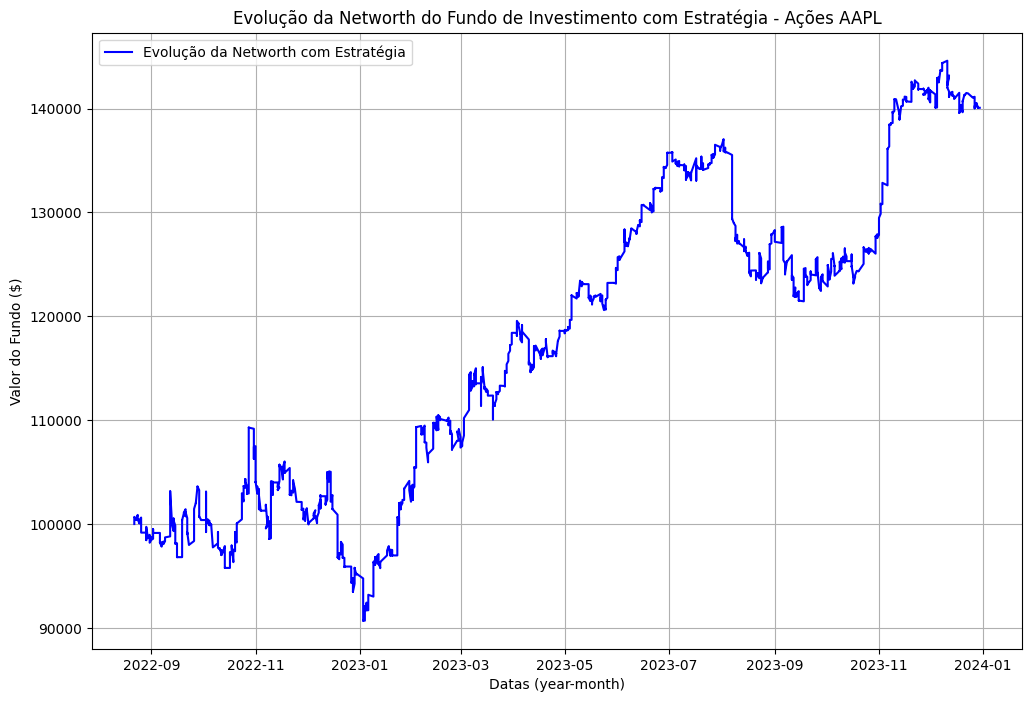

In [ ]:
# Gerar o gráfico da evolução da networth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    networth_strategy_array,
    label="Evolução da Networth com Estratégia",
    color="blue",
)
plt.title(
    "Evolução da Networth do Fundo de Investimento com Estratégia - Ações " + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Plot da networth do portefóflio usando esta estratégia com esta sensibilidade decisiva e coeficiente para este modelo. Combinado com o plot da estratégia mais basica que acompanha e é igual a olhar para o mercado diretamente - simpler long-holder.

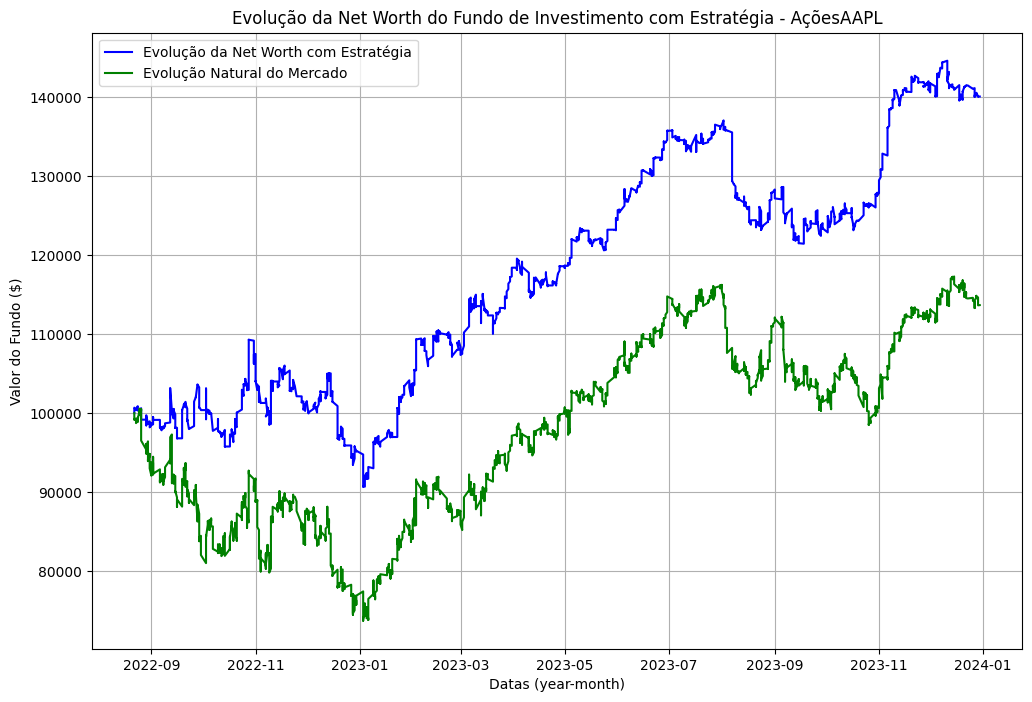

In [ ]:
# Gerar o gráfico da evolução da net worth do fundo com a estratégia
plt.figure(figsize=(12, 8))
plt.plot(
    dates_list[-(len(networth_strategy_array)) :],
    networth_strategy_array,
    label="Evolução da Net Worth com Estratégia",
    color="blue",
)
plt.plot(
    last_subsets_dates,
    natural_fund_values,
    label="Evolução Natural do Mercado",
    color="green",
)

plt.title(
    "Evolução da Net Worth do Fundo de Investimento com Estratégia - Ações" + symbol
)
plt.xlabel("Datas (year-month)")
plt.ylabel("Valor do Fundo ($)")
plt.legend()
plt.grid(True)
plt.show()

Quanto dinheiro a mais se ganhou ao se ter usado este modelo com esta estratégia no final do periodo do dataset de teste?

Dinheiro ganho com esta estratégia - Dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

Melhoria percentual ao se ter usado esta estratégia:

aumento percentual do dinheiro ganho com esta estratégia - aumento percentual do dinheiro ganho para um simple holder (simplesmente acompanhar o mercado)

In [ ]:
print(
    f"Dinheiro extra ganho ao se ter usado AI: {fund - percentage_increase - final_value:.3f}$"
)

print(
    f"\nMelhoria percentual ao se ter usado AI: {percentage_increase_strategy - percentage_increase:.3f}%"
)

Dinheiro extra ganho ao se ter usado AI: 26385.218$

Melhoria percentual ao se ter usado AI: 26.399%


Diferença percentual = Melhoria Percentual

Plot do gráfico que nos dá a melhoria percentual ao longo de todo o dataset. A combinação valor da sensibilidade decisiva, coeficiente deve de ser dada pela média mais elevada de valores de melhoria percentual ao longo de todo este gráfico em função da sensibilidade decisiva.

Melhoria decisiva = ganho percentual da estratégia com o modelo - ganho percentual de um simple holder

simple holder = natural fund values

Coordenadas do valor máximo absoluto:
Data: 2023-11-07
Diferença Percentual Máxima: 30.70%
Média da Diferença Percentual ao Longo de Todo o Gráfico: 19.72%


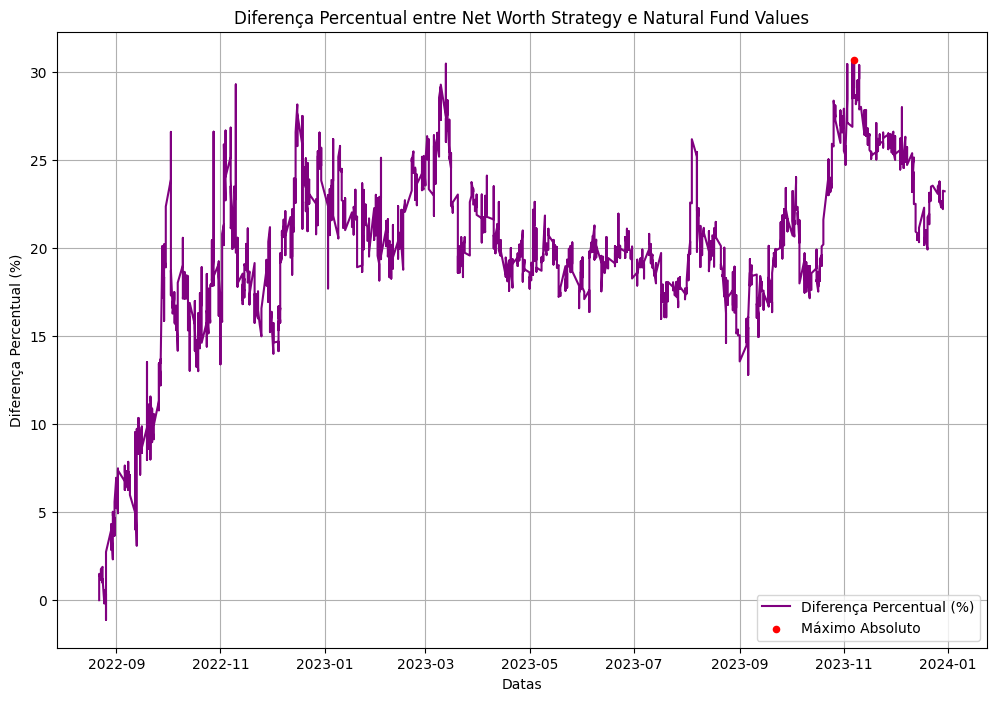

In [ ]:
# Calcular a diferença percentual
diff_percentual = (
    (np.array(networth_strategy_array) - np.array(natural_fund_values))
    / np.array(natural_fund_values)
) * 100

# Encontrar o índice do valor máximo absoluto da diferença percentual
max_index = np.argmax(diff_percentual)

# Coordenadas do valor máximo
max_diff_percentual = diff_percentual[max_index]
max_date = last_subsets_dates[max_index]

print(f"Coordenadas do valor máximo absoluto:")
print(f"Data: {max_date}")
print(f"Diferença Percentual Máxima: {max_diff_percentual:.2f}%")

# Traçar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    last_subsets_dates,
    diff_percentual,
    label="Diferença Percentual (%)",
    color="purple",
)

# Adicionar o ponto máximo ao gráfico
plt.scatter(
    max_date, max_diff_percentual, color="red", s=20, zorder=5, label="Máximo Absoluto"
)

# Rótulos e título
plt.title("Diferença Percentual entre Net Worth Strategy e Natural Fund Values")
plt.xlabel("Datas")
plt.ylabel("Diferença Percentual (%)")

# Calcular a média da diferença percentual
media_diff_percentual = np.mean(diff_percentual)

# Printar o valor médio
print(
    f"Média da Diferença Percentual ao Longo de Todo o Gráfico: {media_diff_percentual:.2f}%"
)

# Adicionar a legenda e grid
plt.legend()
plt.grid(True)

# Mostrar o gráfico
plt.show()

**Estudo do Retorno em Função do Valor Inicial do Fundo:**

Este plot foi feito apenas por descargo de consciência e investigação se poderiam exitir algum tipo de anomalias no código. Ele investiga o retorno percentual no final do dataset de teste em função do investimento inicial que por default é feito com 100 000$. Como era de esperar o retorno percentual não varia consoante o investimento inicial, pois foi permitido o trade na bolsa de ações percentuais.

Atenção este gráfico apresenta o ganho percentual bruto da AI e não a melhoria percentual.


Coordenadas do ponto máximo absoluto: Dinheiro Inicial = $303083.33, Percentual de Crescimento = 40.070%


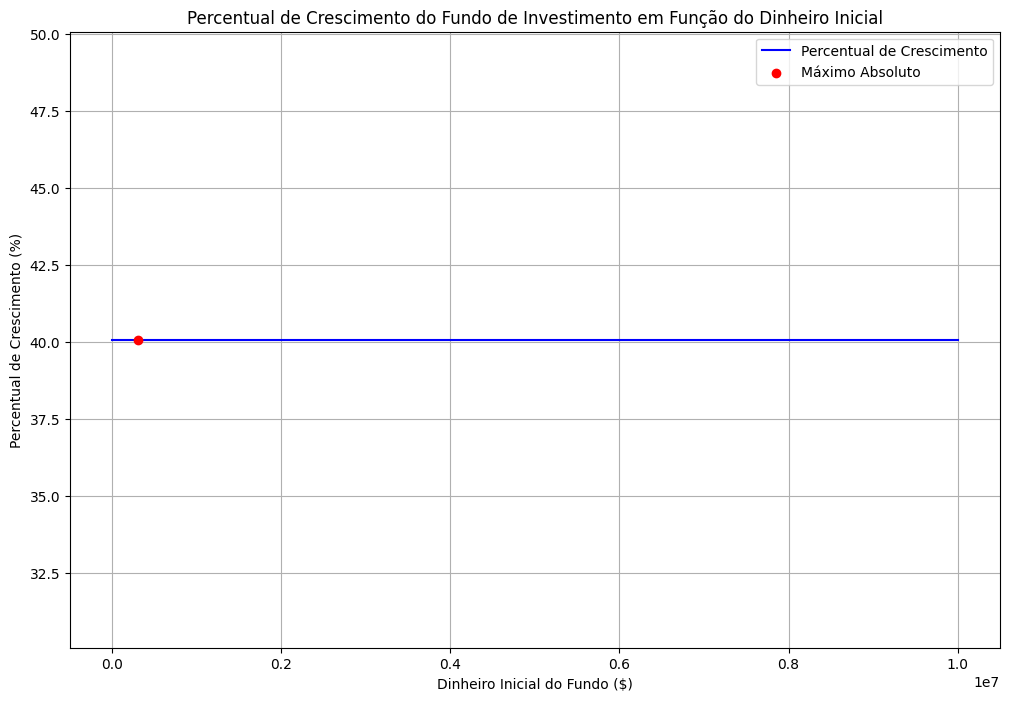

In [ ]:
# Definir a faixa de valores para o fundo inicial
initial_fund_values = np.linspace(50, 10000150, 100)  # Valores de $50 a $10,000,150

# Lista para armazenar os resultados de percentual de ganhos para cada fundo inicial
percentual_ganhos = []

# Loop sobre todos os valores de fundo inicial
for initial_fund in initial_fund_values:
    fund = initial_fund
    num_shares = 0.0  # Posição long (ações compradas)
    num_shares_short = 0.0  # Posição short (ações vendidas a descoberto)
    short_sale_price = 0.0  # Preço de abertura da operação short

    # Iterar pelo tensor (exceto o último que não tem previsão)
    for i in range(len(tensor_np) - 1):
        current_price = float(tensor_np[i + 1][0])  # Preço da ação para a operação
        prediction_raw = tensor_np[i][1]  # Previsão atual (grau de certeza)

        # Converter a previsão para float ou definir 0 se for 'none'
        if prediction_raw != "none":
            prediction = float(prediction_raw)
        else:
            prediction = 0.0

        # OPERACÃO LONG: se previsão for alta e houver caixa
        if prediction > sensibilidade_decisiva and fund > 0:
            # Se houver posição short aberta, cobrir (fechar) o short primeiro
            if num_shares_short > 0:
                profit = num_shares_short * (short_sale_price - current_price)
                fund += profit
                num_shares_short = 0.0
                short_sale_price = 0.0

            # Compra (posição long): investir uma fração do fundo determinada pelo coeficiente_C e pelo grau de certeza
            grau_certeza = abs(prediction)
            percentage_to_spend = coeficiente_c * grau_certeza
            if percentage_to_spend > 1:
                percentage_to_spend = 1
            amount_to_invest = percentage_to_spend * fund
            num_shares_to_buy = amount_to_invest / current_price
            cost = num_shares_to_buy * current_price
            fund -= cost
            num_shares += num_shares_to_buy

        # OPERACÃO VENDA/SHORT: se previsão for baixa (<= sensibilidade_decisiva)
        elif prediction <= sensibilidade_decisiva:
            # Se houver posição long, vende uma fração determinada pelo coeficiente_V e pelo grau de certeza
            if num_shares > 0:
                grau_certeza = abs(1 - prediction)
                percentage_to_sell = coeficiente_v * grau_certeza
                if percentage_to_sell > 1:
                    percentage_to_sell = 1
                amount_to_sell = percentage_to_sell * num_shares
                proceeds = amount_to_sell * current_price
                fund += proceeds
                num_shares -= amount_to_sell

            # Se não houver posição long e nem short aberta, inicia short-selling
            if num_shares == 0 and num_shares_short == 0 and fund > 0:
                grau_certeza_short = abs(1 - prediction)
                percentage_to_short = coeficiente_s * grau_certeza_short
                if percentage_to_short > 1:
                    percentage_to_short = 1
                # Utiliza o fundo disponível como capacidade máxima para short-selling
                amount_to_short = percentage_to_short * fund
                num_shares_to_short = amount_to_short / current_price
                num_shares_short = num_shares_to_short
                short_sale_price = current_price
        else:
            pass

        # Cálculo da networth do portfólio (contando somente o fundo e posições long)
        current_networth = fund + num_shares * current_price

    # Ao final do tensor, fechar quaisquer posições abertas:
    final_price = float(tensor_np[-1][0])

    # Fechar posição long, se houver
    if num_shares > 0:
        proceeds = num_shares * final_price
        fund += proceeds
        num_shares = 0.0

    # Fechar posição short, se houver (realizando lucro ou prejuízo do short)
    if num_shares_short > 0:
        profit = num_shares_short * (short_sale_price - final_price)
        fund += profit
        num_shares_short = 0.0
        short_sale_price = 0.0

    # Calcular o percentual de crescimento
    percentage_increase_strategy = ((fund - initial_fund) / initial_fund) * 100
    percentual_ganhos.append(percentage_increase_strategy)

# Encontrar o índice do valor máximo de percentual_ganhos
max_index = np.argmax(percentual_ganhos)
max_initial_fund = initial_fund_values[max_index]
max_percentage_increase = percentual_ganhos[max_index]

print(
    f"\nCoordenadas do ponto máximo absoluto: Dinheiro Inicial = ${max_initial_fund:.2f}, Percentual de Crescimento = {max_percentage_increase:.3f}%"
)

# Plotar o gráfico
plt.figure(figsize=(12, 8))
plt.plot(
    initial_fund_values,
    percentual_ganhos,
    label="Percentual de Crescimento",
    color="blue",
)
plt.scatter(
    max_initial_fund,
    max_percentage_increase,
    color="red",
    zorder=5,
    label="Máximo Absoluto",
)
plt.ylim(min(percentual_ganhos) - 10, max(percentual_ganhos) + 10)
plt.title(
    "Percentual de Crescimento do Fundo de Investimento em Função do Dinheiro Inicial"
)
plt.xlabel("Dinheiro Inicial do Fundo ($)")
plt.ylabel("Percentual de Crescimento (%)")
plt.grid(True)
plt.legend()
plt.show()

# **Results Com Short-Selling**

Aqui podes comprar todas as estratégias testadas anteriormente sem short selling lado a lado para teres uma melhor visão comprativa de qual funciona melhor.

In [ ]:
print(
    f"Crescimento Natural do Mercado Entre {last_subsets_dates[0]} e {last_subsets_dates[len(last_subsets_dates) - 1]} para ações {symbol}:"
)
print(f"{percentage_increase:.5f}%")

print()
print()

print("Resultados ao Otimizar em Função da Média da Diferença Percentual:")
print()
print("Absolute Buy and Sell com Short-Selling:")
print(
    f"Sensibilidade Decisiva={Results_Mean_cS_array[0][0]:.2f}; Média da Diferença Percentual={Results_Mean_cS_array[0][1]:.5f}"
)
print()
print(
    "Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:"
)
print(
    f"Sensibilidade Decisiva={Results_Mean_cS_array[1][0]:.2f}; Coeficiente de Compra={Results_Mean_cS_array[1][1]:.2f}; Coeficiente de Venda={Results_Mean_cS_array[1][2]:.2f}; Coeficiente de Short-Selling={Results_Mean_cS_array[1][3]:.2f}; Média da Diferença Percentual={Results_Mean_cS_array[1][4]:.5f}"
)

print()
print()

print("Resultados ao Otimizar em Função da Diferença Percentual da Última Data:")
print()
print("Absolute Buy and Sell com Short-Selling:")
print(
    f"Sensibilidade Decisiva={Results_Last_cS_array[0][0]:.2f}; Diferença Percentual={Results_Last_cS_array[0][1]:.5f}"
)
print()
print(
    "Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:"
)
print(
    f"Sensibilidade Decisiva={Results_Last_cS_array[1][0]:.2f}; Coeficiente de Compra={Results_Last_cS_array[1][1]:.2f}; Coeficiente de Venda={Results_Last_cS_array[1][2]:.2f}; Coeficiente de Short-Selling={Results_Mean_cS_array[1][3]:.2f}; Diferença Percentual={Results_Last_cS_array[1][4]:.5f}"
)

Crescimento Natural do Mercado Entre 2022-08-22 e 2023-12-30 para ações AAPL:
13.67132%


Resultados ao Otimizar em Função da Média da Diferença Percentual:

Absolute Buy and Sell com Short-Selling:
Sensibilidade Decisiva=0.78; Média da Diferença Percentual=37.21053

Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.80; Coeficiente de Compra=2.00; Coeficiente de Venda=1.00; Coeficiente de Short-Selling=2.00; Média da Diferença Percentual=37.85628


Resultados ao Otimizar em Função da Diferença Percentual da Última Data:

Absolute Buy and Sell com Short-Selling:
Sensibilidade Decisiva=0.76; Diferença Percentual=50.21004

Independent Parcial Buy, Sell and Short-Selling in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.80; Coeficiente de Compra=2.00; Coeficiente de Venda=5.00; Coeficiente de Short-Selling=2.00; Diferença Percentual=61.63979


Uma forma diferente de olhar para os mesmos resultados. Desta vez a ideia é comparar o que acontece quando tens em conta a média de resultados VS o último resultado.

# **Results Com e Sem Short-Selling (Comparação)**

In [ ]:
print(
    f"Crescimento Natural do Mercado Entre {last_subsets_dates[0]} e {last_subsets_dates[len(last_subsets_dates) - 1]} para ações {symbol}:"
)
print(f"{percentage_increase:.5f}%")

print()
print()

print("Resultados ao Otimizar em Função da Média da Diferença Percentual:")
print()
print("Absolute Buy and Sell:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[0][0]:.2f}; Média da Diferença Percentual={Results_Mean_array[0][1]:.5f}"
)
print()
print("Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[1][0]:.2f}; Coeficiente={Results_Mean_array[1][1]:.2f}; Média da Diferença Percentual={Results_Mean_array[1][2]:.5f}"
)
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[2][0]:.2f}; Coeficiente de Compra={Results_Mean_array[2][1]:.2f}; Coeficiente de Venda={Results_Mean_array[2][2]:.2f}; Média da Diferença Percentual={Results_Mean_array[2][3]:.5f}"
)
print()
print("Parcial Buy in Function of Predictions Probabilaty and Absolute Sell:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[3][0]:.2f}; Coeficiente de Compra={Results_Mean_array[3][1]:.2f}; Média da Diferença Percentual={Results_Mean_array[3][2]:.5f}"
)
print()
print("Absolute Buy and Parcial Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Mean_array[4][0]:.2f}; Coeficiente de Venda={Results_Mean_array[4][1]:.2f}; Média da Diferença Percentual={Results_Mean_array[4][2]:.5f}"
)

print()
print()

print("Resultados ao Otimizar em Função da Diferença Percentual da Última Data:")
print()
print("Absolute Buy and Sell:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[0][0]:.2f}; Diferença Percentual={Results_Last_array[0][1]:.5f}"
)
print()
print("Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[1][0]:.2f}; Coeficiente={Results_Last_array[1][1]:.2f}; Diferença Percentual={Results_Last_array[1][2]:.5f}"
)
print()
print("Independent Parcial Buy and Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[2][0]:.2f}; Coeficiente de Compra={Results_Last_array[2][1]:.2f}; Coeficiente de Venda={Results_Last_array[2][2]:.2f}; Diferença Percentual={Results_Last_array[2][3]:.5f}"
)
print()
print("Parcial Buy in Function of Predictions Probabilaty and Absolute Sell:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[3][0]:.2f}; Coeficiente de Compra={Results_Last_array[3][1]:.2f}; Diferença Percentual={Results_Last_array[3][2]:.5f}"
)
print()
print("Absolute Buy and Parcial Sell in Function of Predictions Probabilaty:")
print(
    f"Sensibilidade Decisiva={Results_Last_array[4][0]:.2f}; Coeficiente de Venda={Results_Last_array[4][1]:.2f}; Diferença Percentual={Results_Last_array[4][2]:.5f}"
)

Crescimento Natural do Mercado Entre 2022-08-22 e 2023-12-30 para ações AAPL:
13.67132%


Resultados ao Otimizar em Função da Média da Diferença Percentual:

Absolute Buy and Sell:
Sensibilidade Decisiva=0.78; Média da Diferença Percentual=19.51800

Parcial Buy and Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.76; Coeficiente=1.00; Média da Diferença Percentual=18.76654

Independent Parcial Buy and Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.80; Coeficiente de Compra=1.00; Coeficiente de Venda=0.80; Média da Diferença Percentual=18.53408

Parcial Buy in Function of Predictions Probabilaty and Absolute Sell:
Sensibilidade Decisiva=0.78; Coeficiente de Compra=1.00; Média da Diferença Percentual=18.66744

Absolute Buy and Parcial Sell in Function of Predictions Probabilaty:
Sensibilidade Decisiva=0.76; Coeficiente de Venda=0.84; Média da Diferença Percentual=19.77139


Resultados ao Otimizar em Função da Diferença Percentual da Última Data